UCI HAR DATASET - TASKS 3-6

Checking dataset...
Dataset already exists.
Using:
/content/UCI_HAR/UCI HAR Dataset

REAL DATASET FOUND
/content/UCI_HAR/UCI HAR Dataset

Train directory:
/content/UCI_HAR/UCI HAR Dataset/train

Test directory:
/content/UCI_HAR/UCI HAR Dataset/test

Train inertial signals:
/content/UCI_HAR/UCI HAR Dataset/train/Inertial Signals

Test inertial signals:
/content/UCI_HAR/UCI HAR Dataset/test/Inertial Signals

SENSOR CHANNELS
1. body_acc_x
2. body_acc_y
3. body_acc_z
4. body_gyro_x
5. body_gyro_y
6. body_gyro_z
7. total_acc_x
8. total_acc_y
9. total_acc_z

----------------------------------------------------------------------
Loading train raw inertial signals...
----------------------------------------------------------------------
Loading: body_acc_x_train.txt
Loading: body_acc_y_train.txt
Loading: body_acc_z_train.txt
Loading: body_gyro_x_train.txt
Loading: body_gyro_y_train.txt
Loading: body_gyro_z_train.txt
Loading: total_acc_x_train.txt
Loading: total_acc

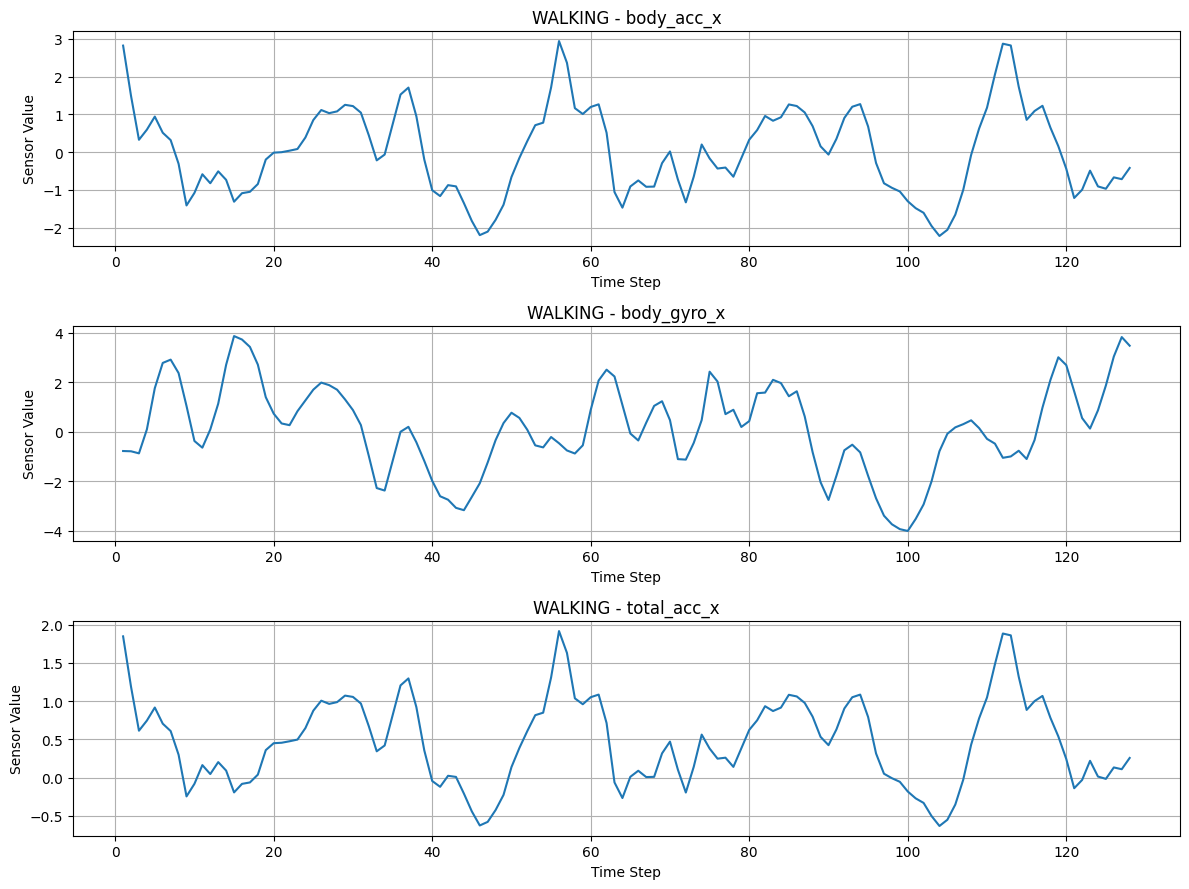

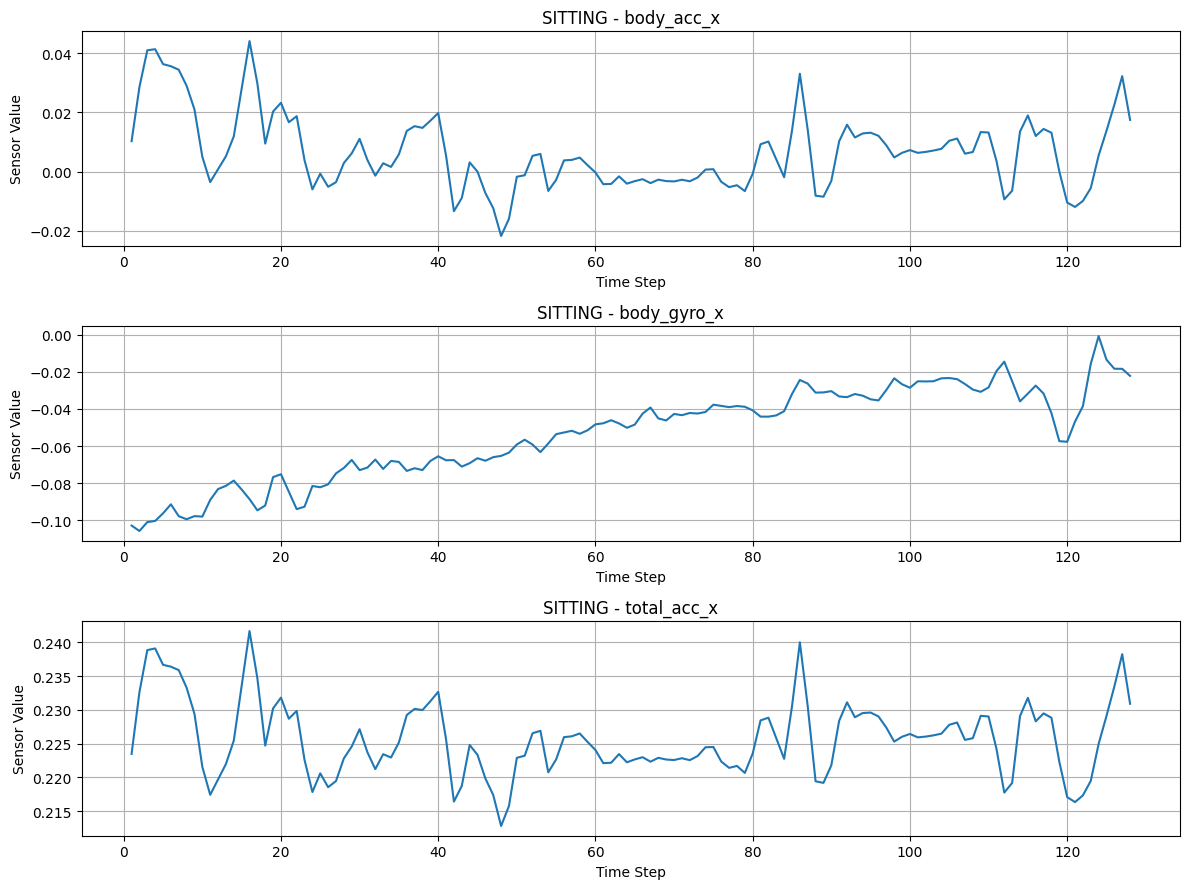

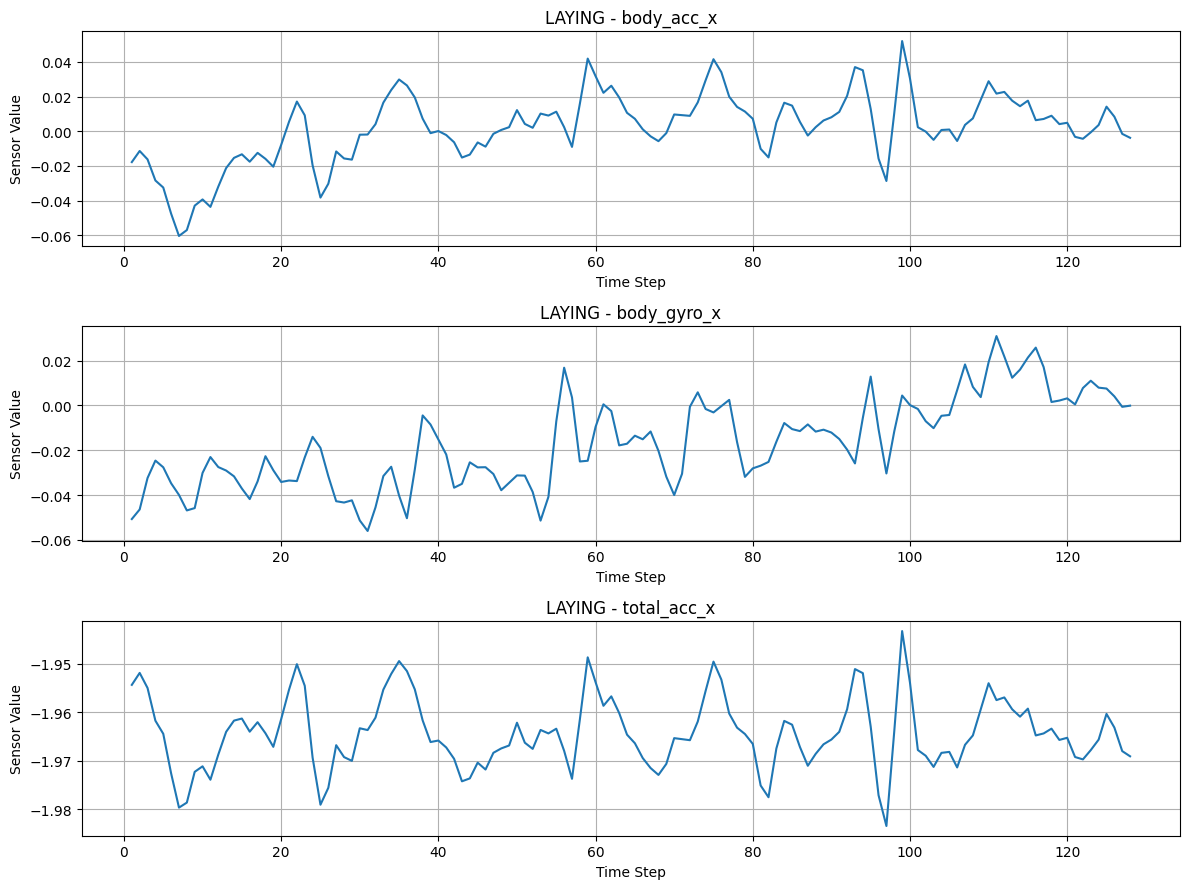

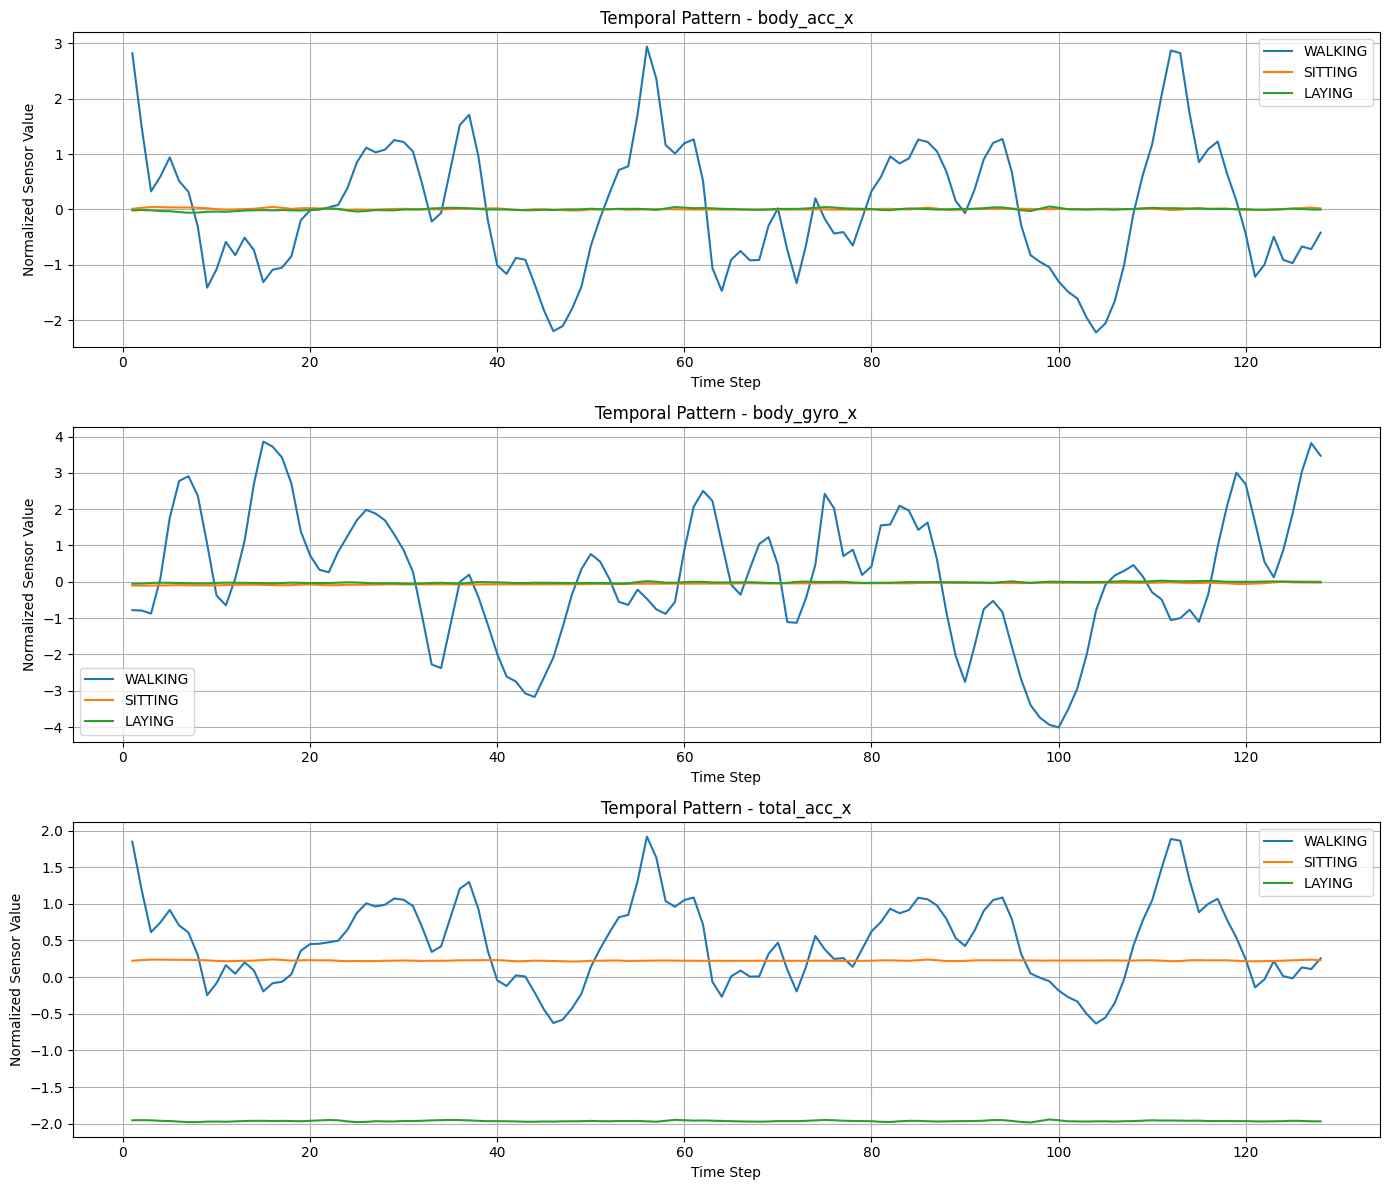



TASKS 3-6 COMPLETED SUCCESSFULLY

Dataset used:
/content/UCI_HAR/UCI HAR Dataset

Exactly first 2000 training windows were selected.

Final input shape:
Training   : (1400, 128, 9)
Validation : (300, 128, 9)
Test       : (300, 128, 9)

Number of classes: 6
Features per timestep: 9
Sequence length: 128

All preprocessing and visualization steps completed.


In [ ]:
# ================================================================
# CS3807 - DEEP LEARNING LABORATORY
# EXPERIMENT 6
# TASKS 3-6
#
# UCI HAR DATASET
# Raw Inertial Signals
#
# EXACTLY FIRST 2000 TRAINING WINDOWS
# Input shape: (N, 128, 9)
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import shutil
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


print("=" * 70)
print("UCI HAR DATASET - TASKS 3-6")
print("=" * 70)


# ================================================================
# 2. DOWNLOAD DATASET FROM UCI
# ================================================================

BASE_DIR = "/content/UCI_HAR"

ZIP_PATH = "/content/UCI_HAR.zip"

DATASET_DIR = "/content/UCI_HAR/UCI HAR Dataset"


# UCI official dataset URL
DATASET_URL = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/00240/"
    "UCI%20HAR%20Dataset.zip"
)


print("\nChecking dataset...")


# ------------------------------------------------
# If the real dataset already exists, use it.
# Otherwise download and extract it.
# ------------------------------------------------

if os.path.isdir(DATASET_DIR):

    print("Dataset already exists.")
    print("Using:")
    print(DATASET_DIR)

else:

    print("Dataset not found.")
    print("Downloading from UCI...")

    # Remove old incomplete ZIP if present
    if os.path.exists(ZIP_PATH):
        os.remove(ZIP_PATH)

    urllib.request.urlretrieve(
        DATASET_URL,
        ZIP_PATH
    )

    print("Download completed.")

    # Remove old extraction folder if present
    if os.path.exists(BASE_DIR):
        shutil.rmtree(BASE_DIR)

    os.makedirs(BASE_DIR, exist_ok=True)

    print("Extracting dataset...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(BASE_DIR)

    print("Extraction completed.")


# ================================================================
# 3. ROBUSTLY LOCATE REAL DATASET
# ================================================================
#
# This specifically ignores:
# /content/UCI_HAR/__MACOSX/...
#
# and finds:
# /content/UCI_HAR/UCI HAR Dataset
#
# ================================================================


def find_real_uci_dataset(base_dir):

    # First check the expected path directly
    expected_path = os.path.join(
        base_dir,
        "UCI HAR Dataset"
    )

    if (
        os.path.isdir(expected_path)
        and os.path.isdir(
            os.path.join(
                expected_path,
                "train",
                "Inertial Signals"
            )
        )
        and os.path.isdir(
            os.path.join(
                expected_path,
                "test",
                "Inertial Signals"
            )
        )
    ):

        return expected_path


    # If not found, search recursively.
    # Explicitly IGNORE __MACOSX.

    for root, dirs, files in os.walk(base_dir):

        # Never enter __MACOSX
        dirs[:] = [
            d for d in dirs
            if d != "__MACOSX"
        ]

        if os.path.basename(root) == "UCI HAR Dataset":

            train_signal_dir = os.path.join(
                root,
                "train",
                "Inertial Signals"
            )

            test_signal_dir = os.path.join(
                root,
                "test",
                "Inertial Signals"
            )

            if (
                os.path.isdir(train_signal_dir)
                and
                os.path.isdir(test_signal_dir)
            ):

                return root


    return None


DATASET_DIR = find_real_uci_dataset(BASE_DIR)


if DATASET_DIR is None:

    print("\nDataset folders found:")

    for root, dirs, files in os.walk(BASE_DIR):

        dirs[:] = [
            d for d in dirs
            if d != "__MACOSX"
        ]

        print(root)

    raise FileNotFoundError(
        "\nCould not find the real UCI HAR Dataset."
    )


print("\n" + "=" * 70)
print("REAL DATASET FOUND")
print("=" * 70)

print(DATASET_DIR)


# ================================================================
# 4. DEFINE TRAIN / TEST DIRECTORIES
# ================================================================

TRAIN_DIR = os.path.join(
    DATASET_DIR,
    "train"
)

TEST_DIR = os.path.join(
    DATASET_DIR,
    "test"
)


TRAIN_SIGNAL_DIR = os.path.join(
    TRAIN_DIR,
    "Inertial Signals"
)

TEST_SIGNAL_DIR = os.path.join(
    TEST_DIR,
    "Inertial Signals"
)


print("\nTrain directory:")
print(TRAIN_DIR)

print("\nTest directory:")
print(TEST_DIR)

print("\nTrain inertial signals:")
print(TRAIN_SIGNAL_DIR)

print("\nTest inertial signals:")
print(TEST_SIGNAL_DIR)


# ================================================================
# 5. CHECK REQUIRED DIRECTORIES
# ================================================================

if not os.path.isdir(TRAIN_SIGNAL_DIR):

    raise FileNotFoundError(
        "Training Inertial Signals directory not found."
    )

if not os.path.isdir(TEST_SIGNAL_DIR):

    raise FileNotFoundError(
        "Testing Inertial Signals directory not found."
    )


# ================================================================
# 6. DEFINE THE 9 RAW SENSOR CHANNELS
# ================================================================
#
# 3 body acceleration
# 3 body gyroscope
# 3 total acceleration
#
# Total = 9 features per time step
#
# ================================================================

SIGNAL_NAMES = [

    "body_acc_x",
    "body_acc_y",
    "body_acc_z",

    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",

    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]


print("\n" + "=" * 70)
print("SENSOR CHANNELS")
print("=" * 70)

for i, signal in enumerate(SIGNAL_NAMES):

    print(
        f"{i + 1}. {signal}"
    )


# ================================================================
# 7. FUNCTION TO LOAD RAW SIGNALS
# ================================================================


def load_raw_signals(signal_dir, split_name):

    print("\n" + "-" * 70)
    print(f"Loading {split_name} raw inertial signals...")
    print("-" * 70)

    signal_data = []

    for signal_name in SIGNAL_NAMES:

        filename = (
            signal_name
            + "_"
            + split_name
            + ".txt"
        )

        filepath = os.path.join(
            signal_dir,
            filename
        )

        if not os.path.exists(filepath):

            raise FileNotFoundError(
                f"\nMissing file:\n{filepath}"
            )

        print(
            f"Loading: {filename}"
        )

        data = np.loadtxt(
            filepath
        )

        signal_data.append(data)


    # Each signal:
    # (number_of_windows, 128)
    #
    # Stack along last axis:
    # (N, 128, 9)

    X = np.stack(
        signal_data,
        axis=2
    )

    print(
        f"\n{split_name} raw data shape: {X.shape}"
    )

    return X


# ================================================================
# 8. LOAD TRAINING RAW SENSOR DATA
# ================================================================

X_all_train = load_raw_signals(
    TRAIN_SIGNAL_DIR,
    "train"
)


# ================================================================
# 9. LOAD TRAINING LABELS
# ================================================================

train_label_path = os.path.join(
    TRAIN_DIR,
    "y_train.txt"
)


if not os.path.exists(train_label_path):

    raise FileNotFoundError(
        f"Training label file not found:\n"
        f"{train_label_path}"
    )


y_all_train = np.loadtxt(
    train_label_path,
    dtype=int
)


print(
    "\nAll training labels shape:",
    y_all_train.shape
)


# ================================================================
# 10. VERIFY DATA / LABEL COUNT
# ================================================================

if len(X_all_train) != len(y_all_train):

    raise ValueError(
        "Number of training samples and labels do not match."
    )


print(
    "Number of training windows:",
    len(X_all_train)
)


# FIRST 2000 entries.

N_SAMPLES = 2000


if len(X_all_train) < N_SAMPLES:

    raise ValueError(
        f"Dataset contains only {len(X_all_train)} "
        f"training samples."
    )


X_subset = X_all_train[
    :N_SAMPLES
].copy()


y_subset = y_all_train[
    :N_SAMPLES
].copy()


print("\n" + "=" * 70)
print("FIRST 2000 TRAINING WINDOWS")
print("=" * 70)

print(
    "X_subset shape:",
    X_subset.shape
)

print(
    "y_subset shape:",
    y_subset.shape
)


# ================================================================
# 12. CHECK RAW LABELS
# ================================================================
#
# UCI labels are:
#
# 1 WALKING
# 2 WALKING_UPSTAIRS
# 3 WALKING_DOWNSTAIRS
# 4 SITTING
# 5 STANDING
# 6 LAYING
#
# Convert them to:
# 0,1,2,3,4,5
#
# ================================================================


ACTIVITY_NAMES = [

    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]


print("\nOriginal label values:")

print(
    np.unique(y_subset)
)


# Convert 1-6 -> 0-5

y_subset = y_subset - 1


print(
    "Converted label values:"
)

print(
    np.unique(y_subset)
)


# ================================================================
# 13. CHECK CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION - FIRST 2000 WINDOWS")
print("=" * 70)


class_counts = np.bincount(
    y_subset,
    minlength=6
)


class_distribution = pd.DataFrame({

    "Class ID": np.arange(6),

    "Activity": ACTIVITY_NAMES,

    "Number of Samples": class_counts,

    "Percentage": (
        class_counts / len(y_subset) * 100
    )

})


print(
    class_distribution.to_string(
        index=False
    )
)


# ================================================================
# 14. TRAIN / VALIDATION / TEST SPLIT
# ================================================================
#
# 70% -> Training
# 15% -> Validation
# 15% -> Test
#
# Stratified split keeps class distribution similar.
#
# ================================================================


X_train, X_temp, y_train, y_temp = train_test_split(

    X_subset,
    y_subset,

    test_size=0.30,

    stratify=y_subset,

    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    stratify=y_temp,

    random_state=42
)


# ================================================================
# 15. PRINT SPLIT SHAPES
# ================================================================

print("\n" + "=" * 70)
print("DATASET SPLIT")
print("=" * 70)

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)


# ================================================================
# 16. VERIFY EXPECTED SHAPES
# ================================================================

assert X_train.shape == (
    1400,
    128,
    9
)

assert X_val.shape == (
    300,
    128,
    9
)

assert X_test.shape == (
    300,
    128,
    9
)

assert y_train.shape == (1400,)

assert y_val.shape == (300,)

assert y_test.shape == (300,)


print("\nShape verification PASSED.")


# ================================================================
# 17. VERIFY NUMBER OF CLASSES
# ================================================================

NUM_CLASSES = len(
    np.unique(y_subset)
)

NUM_FEATURES = X_train.shape[2]

SEQUENCE_LENGTH = X_train.shape[1]


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(
    "Number of classes:",
    NUM_CLASSES
)

print(
    "Features per timestep:",
    NUM_FEATURES
)

print(
    "Sequence length:",
    SEQUENCE_LENGTH
)


assert NUM_CLASSES == 6

assert NUM_FEATURES == 9

assert SEQUENCE_LENGTH == 128


# ================================================================
# 18. NORMALIZATION
# ================================================================
#
# IMPORTANT:
# Mean and standard deviation are calculated ONLY
# from the training data.
#
# Validation and test data use the same statistics.
#
# ================================================================


print("\n" + "=" * 70)
print("NORMALIZATION")
print("=" * 70)


# Calculate mean/std across:
# samples and time steps
#
# Keep one value per sensor channel.

train_mean = np.mean(
    X_train,
    axis=(0, 1),
    keepdims=True
)

train_std = np.std(
    X_train,
    axis=(0, 1),
    keepdims=True
)


# Prevent division by zero

train_std = np.where(
    train_std < 1e-8,
    1.0,
    train_std
)


# Normalize

X_train = (
    X_train - train_mean
) / train_std


X_val = (
    X_val - train_mean
) / train_std


X_test = (
    X_test - train_mean
) / train_std


print(
    "Normalization completed."
)

print(
    "Training mean shape:",
    train_mean.shape
)

print(
    "Training std shape:",
    train_std.shape
)


# ================================================================
# 19. VERIFY NORMALIZATION
# ================================================================

print("\nTraining data mean after normalization:")

print(
    np.mean(
        X_train,
        axis=(0, 1)
    )
)


print("\nTraining data std after normalization:")

print(
    np.std(
        X_train,
        axis=(0, 1)
    )
)


# ================================================================
# 20. CHECK FOR NaN / INFINITY
# ================================================================

print("\n" + "=" * 70)
print("DATA VALIDATION")
print("=" * 70)


print(
    "NaN in X_train:",
    np.isnan(X_train).any()
)

print(
    "NaN in X_val:",
    np.isnan(X_val).any()
)

print(
    "NaN in X_test:",
    np.isnan(X_test).any()
)


print(
    "Infinity in X_train:",
    np.isinf(X_train).any()
)

print(
    "Infinity in X_val:",
    np.isinf(X_val).any()
)

print(
    "Infinity in X_test:",
    np.isinf(X_test).any()
)


assert not np.isnan(X_train).any()

assert not np.isnan(X_val).any()

assert not np.isnan(X_test).any()

assert not np.isinf(X_train).any()

assert not np.isinf(X_val).any()

assert not np.isinf(X_test).any()


print(
    "\nData validation PASSED."
)


# ================================================================
# 21. FINAL DATASET SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("FINAL PREPROCESSED DATASET")
print("=" * 70)


print(
    f"Training set   : {X_train.shape}"
)

print(
    f"Validation set : {X_val.shape}"
)

print(
    f"Test set       : {X_test.shape}"
)

print(
    f"Classes        : {NUM_CLASSES}"
)

print(
    f"Features/time  : {NUM_FEATURES}"
)

print(
    f"Sequence length: {SEQUENCE_LENGTH}"
)


# ================================================================
# 22. TASK 6 - TEMPORAL VISUALIZATION
# ================================================================
#
# Plot representative sequences from at least
# three different activities.
#
# We use:
#
# WALKING
# SITTING
# LAYING
#
# and three sensor channels:
#
# body_acc_x
# body_gyro_x
# total_acc_x
#
# ================================================================


print("\n" + "=" * 70)
print("TEMPORAL VISUALIZATION")
print("=" * 70)


# Select activities

SELECTED_CLASSES = [

    0,  # WALKING
    3,  # SITTING
    5   # LAYING

]


# Select channels

SELECTED_CHANNELS = [

    0,  # body_acc_x
    3,  # body_gyro_x
    6   # total_acc_x

]


TIME_STEPS = np.arange(
    1,
    SEQUENCE_LENGTH + 1
)


# ================================================================
# 23. FIND ONE REPRESENTATIVE SAMPLE PER ACTIVITY
# ================================================================


representative_samples = {}


for class_id in SELECTED_CLASSES:

    indices = np.where(
        y_train == class_id
    )[0]

    if len(indices) == 0:

        raise ValueError(
            f"No training sample found for class {class_id}"
        )

    representative_samples[class_id] = indices[0]


print(
    "Representative samples:"
)


for class_id, index in representative_samples.items():

    print(
        f"{ACTIVITY_NAMES[class_id]} "
        f"-> sample index {index}"
    )


# ================================================================
# 24. INDIVIDUAL PLOTS
# ================================================================


for class_id in SELECTED_CLASSES:

    sample_index = representative_samples[
        class_id
    ]

    sample = X_train[
        sample_index
    ]


    fig, axes = plt.subplots(
        3,
        1,
        figsize=(12, 9)
    )


    for plot_index, channel_id in enumerate(
        SELECTED_CHANNELS
    ):

        axes[plot_index].plot(

            TIME_STEPS,

            sample[:, channel_id]

        )


        axes[plot_index].set_title(

            f"{ACTIVITY_NAMES[class_id]} - "
            f"{SIGNAL_NAMES[channel_id]}"

        )


        axes[plot_index].set_xlabel(
            "Time Step"
        )

        axes[plot_index].set_ylabel(
            "Sensor Value"
        )

        axes[plot_index].grid(
            True
        )


    plt.tight_layout()

    plt.show()


# ================================================================
# 25. COMBINED COMPARISON PLOT
# ================================================================


fig, axes = plt.subplots(

    len(SELECTED_CHANNELS),

    1,

    figsize=(14, 12)

)


for plot_index, channel_id in enumerate(
    SELECTED_CHANNELS
):


    for class_id in SELECTED_CLASSES:

        sample_index = representative_samples[
            class_id
        ]

        sample = X_train[
            sample_index
        ]


        axes[plot_index].plot(

            TIME_STEPS,

            sample[:, channel_id],

            label=ACTIVITY_NAMES[class_id]

        )


    axes[plot_index].set_title(

        f"Temporal Pattern - "
        f"{SIGNAL_NAMES[channel_id]}"

    )


    axes[plot_index].set_xlabel(
        "Time Step"
    )

    axes[plot_index].set_ylabel(
        "Normalized Sensor Value"
    )

    axes[plot_index].legend()

    axes[plot_index].grid(
        True
    )


plt.tight_layout()

plt.show()


# ================================================================
# 26. FINAL SUCCESS MESSAGE
# ================================================================


print("\n")
print("=" * 70)
print("TASKS 3-6 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "\nDataset used:"
)

print(
    DATASET_DIR
)

print(
    "\nExactly first 2000 training windows were selected."
)

print(
    "\nFinal input shape:"
)

print(
    "Training   :", X_train.shape
)

print(
    "Validation :", X_val.shape
)

print(
    "Test       :", X_test.shape
)

print(
    "\nNumber of classes:",
    NUM_CLASSES
)

print(
    "Features per timestep:",
    NUM_FEATURES
)

print(
    "Sequence length:",
    SEQUENCE_LENGTH
)

print(
    "\nAll preprocessing and visualization steps completed."
)

print("=" * 70)

TASKS 7-13: RNN, LSTM AND GRU

Dataset variables found successfully.

Dataset:
Training   : (1400, 128, 9)
Validation : (300, 128, 9)
Test       : (300, 128, 9)

Sequence length : 128
Features        : 9
Classes         : 6

TASK 7 - VANILLA RNN ARCHITECTURE

Vanilla RNN recurrence:

h_t = tanh(Wx*x_t + Wh*h_(t-1) + b)

For sequence classification:

Input
  |
  v
128 time steps x 9 features
  |
  v
SimpleRNN - 32 units
  |
  v
Dropout - 0.2
  |
  v
Dense - 16 units, ReLU
  |
  v
Dense - 6 units, Softmax
  |
  v
Activity class


TASK 8 - BPTT NUMERICAL EXERCISE

Given:
x1 = 0.5
x2 = 0.7
x3 = 0.2
h0 = 0.0
Wx = 0.5
Wh = 0.8
b  = 0.1

Calculated values:
h1 = tanh(0.5*0.5 + 0.8*0.0 + 0.1)
h1 = 0.336376

h2 = tanh(0.5*0.7 + 0.8*0.336376 + 0.1)
h2 = 0.616352

h3 = tanh(0.5*0.2 + 0.8*0.616352 + 0.1)
h3 = 0.599958

Rounded values for lab report:
h1 ≈ 0.3364
h2 ≈ 0.6164
h3 ≈ 0.6000

BPTT explanation:

The RNN is unrolled across all time steps:

x1 -> h1 -> h2 -> h3 -> ... -> h128

During BPTT, t

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING CONFIGURATION
Optimizer      : Adam
Learning rate  : 0.001
Batch size     : 32
Epochs         : 30
Loss           : Sparse Categorical Crossentropy
Recurrent units: 32
Dropout        : 0.2

TRAINING VANILLA RNN
Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.1664 - loss: 1.8133 - val_accuracy: 0.4633 - val_loss: 1.5978
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4386 - loss: 1.4572 - val_accuracy: 0.4633 - val_loss: 1.3306
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5307 - loss: 1.2257 - val_accuracy: 0.4967 - val_loss: 1.1610
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5700 - loss: 1.0738 - val_accuracy: 0.5400 - val_loss: 1.0275
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5971 - loss: 0.9822 - val_accuracy: 0.6167 - val_loss: 0.9344
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6543 - loss: 0.8845 - val_accuracy: 0.6300 - val_loss: 0.8586
Epoch 7/30
44/44 

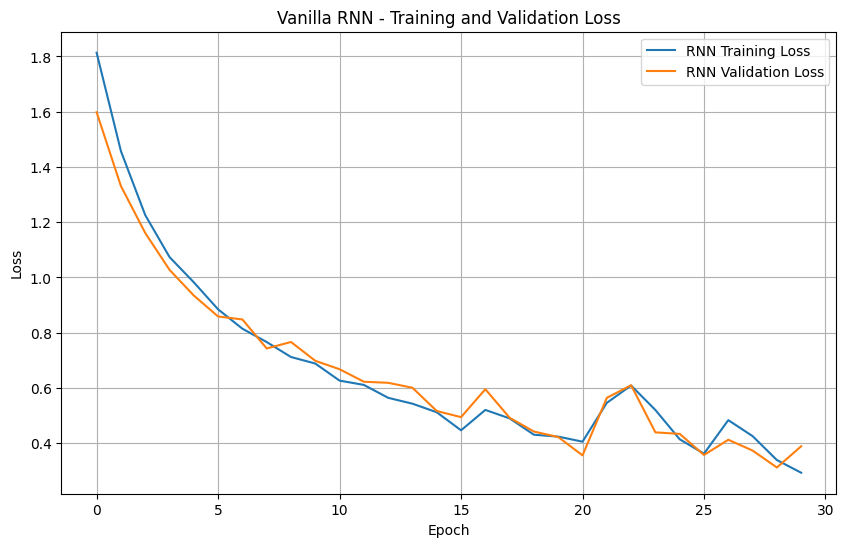

BPTT Numerical Exercise - Manual vs Program
--------------------------------------------------
h1: Manual = 0.336376, Program = 0.336376, Difference = 0.000000
h2: Manual = 0.616352, Program = 0.616352, Difference = 0.000000
h3: Manual = 0.599958, Program = 0.599958, Difference = 0.000000


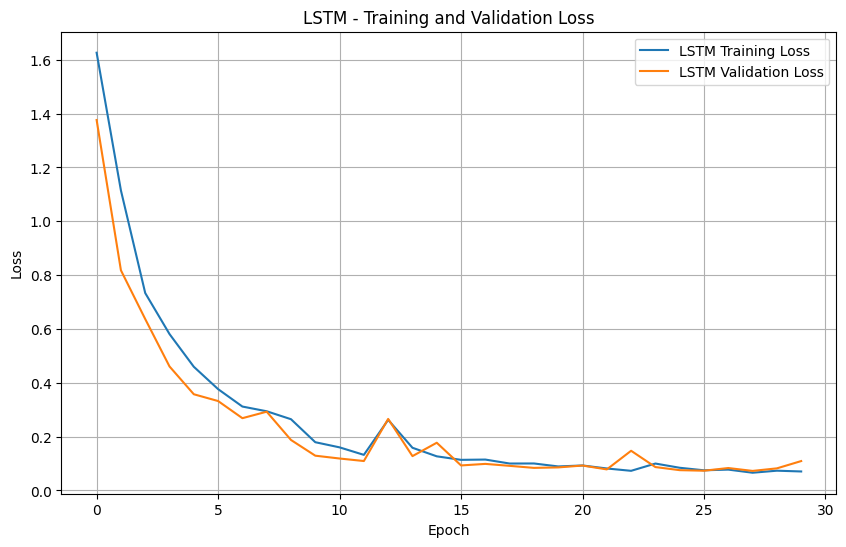

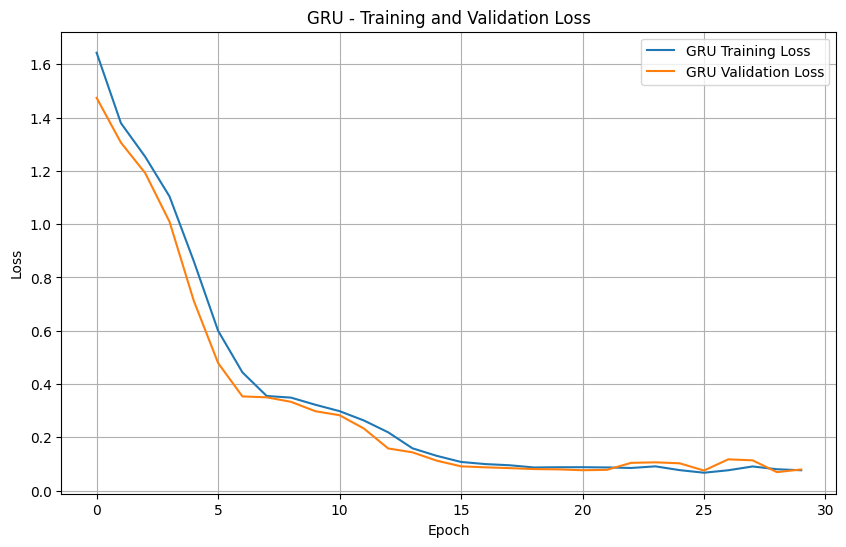

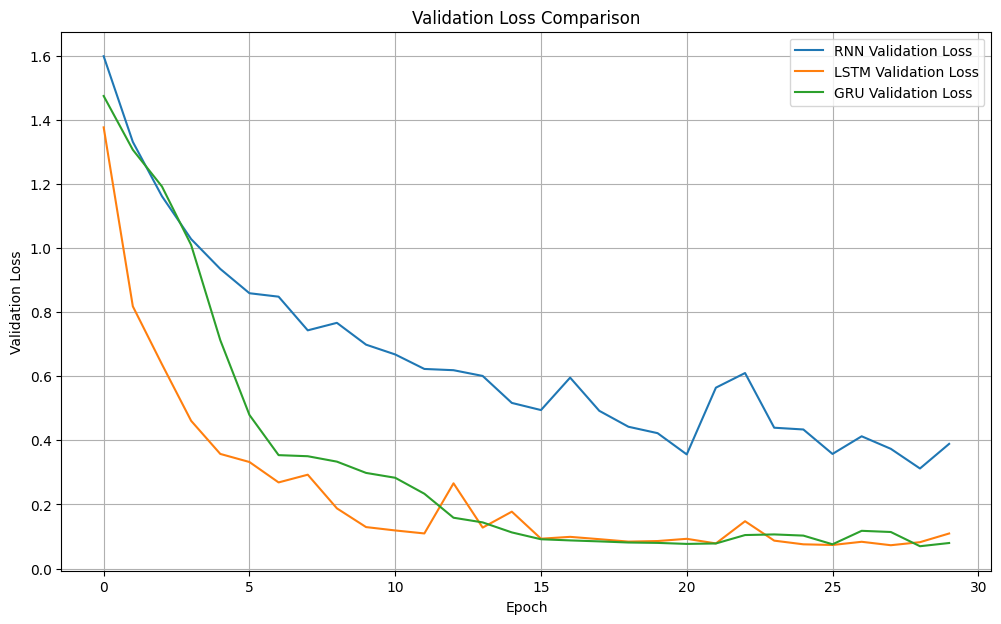


TASK 13 - ACCURACY CURVES


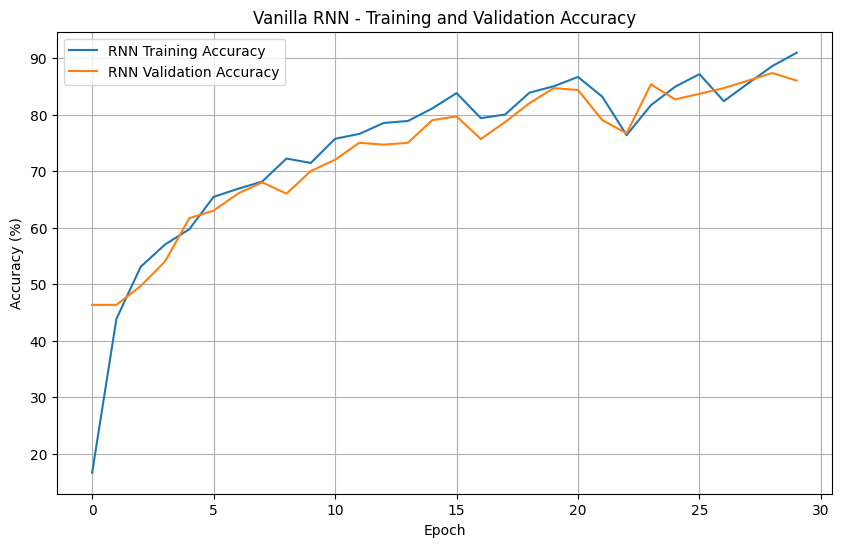

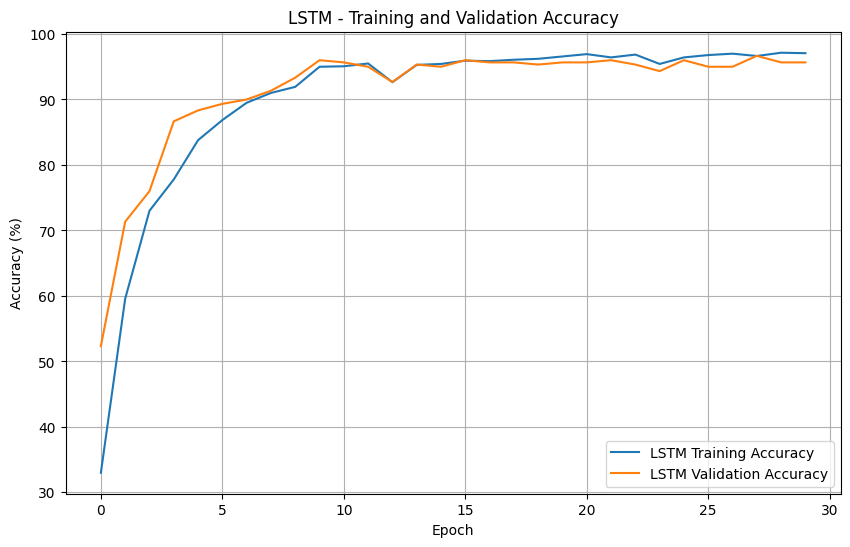

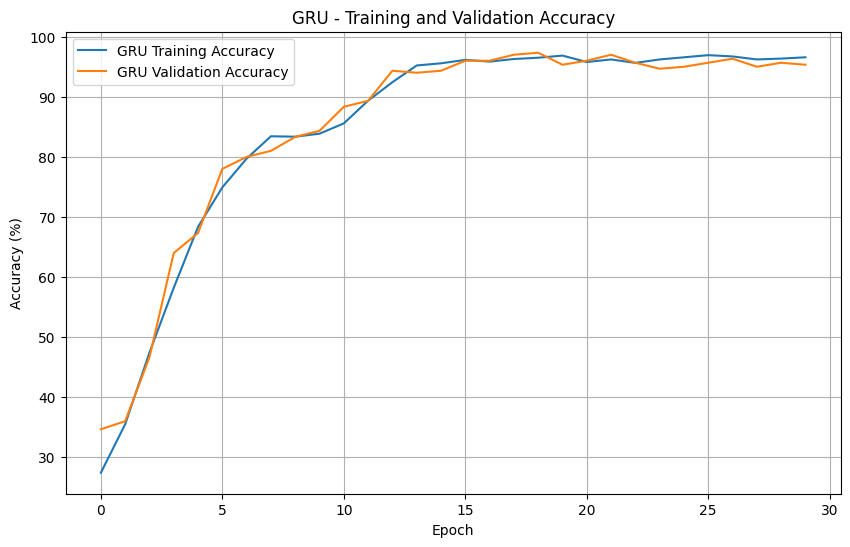

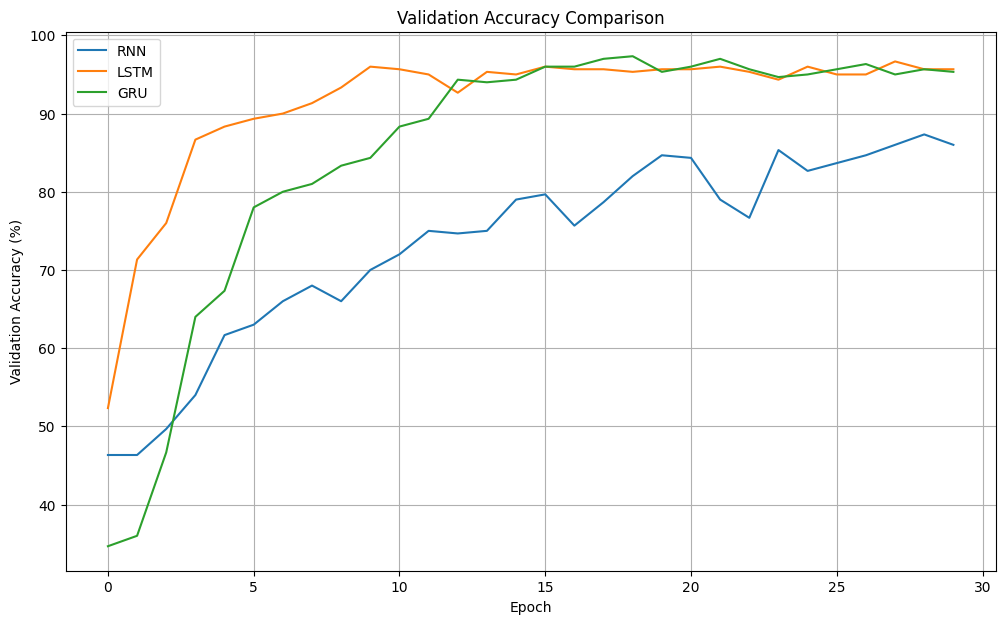


FINAL TRAINING / VALIDATION ACCURACY
RNN  - Train: 90.93% | Validation: 86.00%
LSTM - Train: 97.07% | Validation: 95.67%
GRU  - Train: 96.57% | Validation: 95.33%

GENERALIZATION GAP
RNN  : 4.93 percentage points
LSTM : 1.40 percentage points
GRU  : 1.24 percentage points

TRAINABLE PARAMETERS
RNN  : 1,974
LSTM : 6,006
GRU  : 4,758

TASK 14 - TRAINING TIME VALUES
RNN  Training Time : 38.05 seconds
LSTM Training Time : 71.18 seconds
GRU  Training Time : 107.16 seconds

TASKS 7-13 COMPLETED

Completed:

Task 7  - Vanilla RNN architecture
Task 8  - BPTT explanation + numerical exercise
Task 9  - Vanilla RNN implementation
Task 10 - LSTM architecture
Task 11 - GRU architecture
Task 12 - LSTM and GRU implementation
Task 13 - Training/validation loss and accuracy plots

Models:

RNN  -> SimpleRNN(32) -> Dropout(0.2) -> Dense(16) -> Dense(6)
LSTM -> LSTM(32)      -> Dropout(0.2) -> Dense(16) -> Dense(6)
GRU  -> GRU(32)       -> Dropout(0.2) -> Dense(16) -> Dense(6)

Training:

Optimizer = Ad

In [ ]:
# ================================================================
# CS3807 - DEEP LEARNING LABORATORY
# EXPERIMENT 6
#
# TASKS 7-13
#
# Vanilla RNN
# BPTT Numerical Exercise
# LSTM
# GRU
# Training
# Loss Curves
# Accuracy Curves
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam


print("=" * 70)
print("TASKS 7-13: RNN, LSTM AND GRU")
print("=" * 70)


# ================================================================
# 2. VERIFY THAT PREVIOUS DATA EXISTS
# ================================================================

required_variables = [
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test"
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if len(missing_variables) > 0:

    raise RuntimeError(
        "The following variables are missing:\n"
        + str(missing_variables)
        + "\n\nRun the Tasks 3-6 preprocessing code first."
    )

print("\nDataset variables found successfully.")


# ================================================================
# 3. DATASET INFORMATION
# ================================================================

SEQUENCE_LENGTH = X_train.shape[1]

NUM_FEATURES = X_train.shape[2]

NUM_CLASSES = len(
    np.unique(y_train)
)

print("\nDataset:")
print("Training   :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)

print("\nSequence length :", SEQUENCE_LENGTH)
print("Features        :", NUM_FEATURES)
print("Classes         :", NUM_CLASSES)


# ================================================================
# TASK 7
# VANILLA RNN NUMERICAL ARCHITECTURE
# ================================================================

print("\n" + "=" * 70)
print("TASK 7 - VANILLA RNN ARCHITECTURE")
print("=" * 70)

print("""
Vanilla RNN recurrence:

h_t = tanh(Wx*x_t + Wh*h_(t-1) + b)

For sequence classification:

Input
  |
  v
128 time steps x 9 features
  |
  v
SimpleRNN - 32 units
  |
  v
Dropout - 0.2
  |
  v
Dense - 16 units, ReLU
  |
  v
Dense - 6 units, Softmax
  |
  v
Activity class
""")


# ================================================================
# TASK 8
# BPTT NUMERICAL EXERCISE
# ================================================================

print("\n" + "=" * 70)
print("TASK 8 - BPTT NUMERICAL EXERCISE")
print("=" * 70)


# Given values

x1 = 0.5
x2 = 0.7
x3 = 0.2

h0 = 0.0

Wx = 0.5
Wh = 0.8

b = 0.1


# RNN equation

def rnn_step(x, previous_h):

    return np.tanh(
        Wx * x
        + Wh * previous_h
        + b
    )


# Calculate manually using program

h1 = rnn_step(
    x1,
    h0
)

h2 = rnn_step(
    x2,
    h1
)

h3 = rnn_step(
    x3,
    h2
)


print("\nGiven:")

print("x1 =", x1)
print("x2 =", x2)
print("x3 =", x3)

print("h0 =", h0)

print("Wx =", Wx)
print("Wh =", Wh)
print("b  =", b)


print("\nCalculated values:")

print(
    f"h1 = tanh({Wx}*{x1} + {Wh}*{h0} + {b})"
)

print(
    f"h1 = {h1:.6f}"
)


print(
    f"\nh2 = tanh({Wx}*{x2} + {Wh}*{h1:.6f} + {b})"
)

print(
    f"h2 = {h2:.6f}"
)


print(
    f"\nh3 = tanh({Wx}*{x3} + {Wh}*{h2:.6f} + {b})"
)

print(
    f"h3 = {h3:.6f}"
)


print("\nRounded values for lab report:")

print(f"h1 ≈ {h1:.4f}")
print(f"h2 ≈ {h2:.4f}")
print(f"h3 ≈ {h3:.4f}")


# ================================================================
# OPTIONAL: SHOW BPTT CONCEPT
# ================================================================

print("""
BPTT explanation:

The RNN is unrolled across all time steps:

x1 -> h1 -> h2 -> h3 -> ... -> h128

During BPTT, the loss gradient is propagated
backward through these recurrent states.

Because the same recurrent weights are reused
at every time step, the gradient repeatedly
passes through the recurrent transformation.

Repeated multiplication can cause:

1. Vanishing gradients
2. Exploding gradients
3. Difficulty learning long-term dependencies
4. Sequential computation and limited parallelism
""")


# ================================================================
# 4. MODEL CREATION FUNCTION
# ================================================================

def create_model(recurrent_type):

    model = Sequential()


    # ------------------------------------------------------------
    # Recurrent layer
    # ------------------------------------------------------------

    if recurrent_type == "RNN":

        model.add(
            SimpleRNN(
                32,
                input_shape=(
                    SEQUENCE_LENGTH,
                    NUM_FEATURES
                )
            )
        )


    elif recurrent_type == "LSTM":

        model.add(
            LSTM(
                32,
                input_shape=(
                    SEQUENCE_LENGTH,
                    NUM_FEATURES
                )
            )
        )


    elif recurrent_type == "GRU":

        model.add(
            GRU(
                32,
                input_shape=(
                    SEQUENCE_LENGTH,
                    NUM_FEATURES
                )
            )
        )


    else:

        raise ValueError(
            "recurrent_type must be RNN, LSTM or GRU"
        )


    # ------------------------------------------------------------
    # Same classifier for all models
    # ------------------------------------------------------------

    model.add(
        Dropout(0.2)
    )

    model.add(
        Dense(
            16,
            activation="relu"
        )
    )

    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )


    # ------------------------------------------------------------
    # Same optimizer for all models
    # ------------------------------------------------------------

    optimizer = Adam(
        learning_rate=0.001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    return model


# ================================================================
# 5. CREATE RNN MODEL
# ================================================================

print("\n" + "=" * 70)
print("RNN MODEL")
print("=" * 70)

rnn_model = create_model(
    "RNN"
)

rnn_model.summary()


# ================================================================
# 6. CREATE LSTM MODEL
# ================================================================

print("\n" + "=" * 70)
print("LSTM MODEL")
print("=" * 70)

lstm_model = create_model(
    "LSTM"
)

lstm_model.summary()


# ================================================================
# 7. CREATE GRU MODEL
# ================================================================

print("\n" + "=" * 70)
print("GRU MODEL")
print("=" * 70)

gru_model = create_model(
    "GRU"
)

gru_model.summary()


# ================================================================
# 8. TRAINING CONFIGURATION
# ================================================================

EPOCHS = 30

BATCH_SIZE = 32


print("\n" + "=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)

print(
    "Optimizer      : Adam"
)

print(
    "Learning rate  : 0.001"
)

print(
    "Batch size     : 32"
)

print(
    "Epochs         : 30"
)

print(
    "Loss           : Sparse Categorical Crossentropy"
)

print(
    "Recurrent units: 32"
)

print(
    "Dropout        : 0.2"
)


# ================================================================
# 9. TRAIN VANILLA RNN
# ================================================================

print("\n" + "=" * 70)
print("TRAINING VANILLA RNN")
print("=" * 70)

# Start timing
rnn_start_time = time.time()

rnn_history = rnn_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)

# End timing
rnn_training_time = time.time() - rnn_start_time

print(
    f"\nRNN Training Time: "
    f"{rnn_training_time:.2f} seconds"
)


# ================================================================
# 10. TRAIN LSTM
# ================================================================

print("\n" + "=" * 70)
print("TRAINING LSTM")
print("=" * 70)

# Start timing
lstm_start_time = time.time()

lstm_history = lstm_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)

# End timing
lstm_training_time = time.time() - lstm_start_time

print(
    f"\nLSTM Training Time: "
    f"{lstm_training_time:.2f} seconds"
)


# ================================================================
# 11. TRAIN GRU
# ================================================================

print("\n" + "=" * 70)
print("TRAINING GRU")
print("=" * 70)

# Start timing
gru_start_time = time.time()

gru_history = gru_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)

# End timing
gru_training_time = time.time() - gru_start_time

print(
    f"\nGRU Training Time: "
    f"{gru_training_time:.2f} seconds"
)


# ================================================================
# TRAINING TIME COMPARISON
# ================================================================

print("\n" + "=" * 70)
print("TRAINING TIME COMPARISON")
print("=" * 70)

print(
    f"RNN  : {rnn_training_time:.2f} seconds"
)

print(
    f"LSTM : {lstm_training_time:.2f} seconds"
)

print(
    f"GRU  : {gru_training_time:.2f} seconds"
)


# ================================================================
# TASK 13
# TRAINING / VALIDATION LOSS PLOTS
# ================================================================

print("\n" + "=" * 70)
print("TASK 13 - LOSS CURVES")
print("=" * 70)


# ------------------------------------------------
# RNN LOSS
# ------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    rnn_history.history["loss"],
    label="RNN Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    label="RNN Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Vanilla RNN - Training and Validation Loss"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ------------------------------------------------
# BPTT PROGRAM COMPARISON
# ------------------------------------------------

import numpy as np

# Given values
x = [0.5, 0.7, 0.2]
h = 0.0
Wx = 0.5
Wh = 0.8
b = 0.1

# Program calculation
program_values = []

for xt in x:
    h = np.tanh(Wx * xt + Wh * h + b)
    program_values.append(h)

# Manual values from calculation
manual_values = [
    0.336376,
    0.616352,
    0.599958
]

print(
    "BPTT Numerical Exercise - Manual vs Program"
)

print("-" * 50)

for i, (manual, program) in enumerate(
    zip(manual_values, program_values),
    start=1
):

    print(
        f"h{i}: Manual = {manual:.6f}, "
        f"Program = {program:.6f}, "
        f"Difference = {abs(manual - program):.6f}"
    )


# ------------------------------------------------
# LSTM LOSS
# ------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    lstm_history.history["loss"],
    label="LSTM Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="LSTM Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "LSTM - Training and Validation Loss"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ------------------------------------------------
# GRU LOSS
# ------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    gru_history.history["loss"],
    label="GRU Training Loss"
)

plt.plot(
    gru_history.history["val_loss"],
    label="GRU Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "GRU - Training and Validation Loss"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ================================================================
# COMBINED LOSS COMPARISON
# ================================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    rnn_history.history["val_loss"],
    label="RNN Validation Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="LSTM Validation Loss"
)

plt.plot(
    gru_history.history["val_loss"],
    label="GRU Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Loss"
)

plt.title(
    "Validation Loss Comparison"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ================================================================
# TRAINING / VALIDATION ACCURACY
# ================================================================

print("\n" + "=" * 70)
print("TASK 13 - ACCURACY CURVES")
print("=" * 70)


# ------------------------------------------------
# RNN ACCURACY
# ------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    np.array(
        rnn_history.history["accuracy"]
    ) * 100,
    label="RNN Training Accuracy"
)

plt.plot(
    np.array(
        rnn_history.history["val_accuracy"]
    ) * 100,
    label="RNN Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Vanilla RNN - Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ------------------------------------------------
# LSTM ACCURACY
# ------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    np.array(
        lstm_history.history["accuracy"]
    ) * 100,
    label="LSTM Training Accuracy"
)

plt.plot(
    np.array(
        lstm_history.history["val_accuracy"]
    ) * 100,
    label="LSTM Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "LSTM - Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ------------------------------------------------
# GRU ACCURACY
# ------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    np.array(
        gru_history.history["accuracy"]
    ) * 100,
    label="GRU Training Accuracy"
)

plt.plot(
    np.array(
        gru_history.history["val_accuracy"]
    ) * 100,
    label="GRU Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "GRU - Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ================================================================
# COMBINED VALIDATION ACCURACY
# ================================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    np.array(
        rnn_history.history["val_accuracy"]
    ) * 100,
    label="RNN"
)

plt.plot(
    np.array(
        lstm_history.history["val_accuracy"]
    ) * 100,
    label="LSTM"
)

plt.plot(
    np.array(
        gru_history.history["val_accuracy"]
    ) * 100,
    label="GRU"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Validation Accuracy Comparison"
)

plt.legend()

plt.grid(
    True
)

plt.show()


# ================================================================
# 12. FINAL TRAINING ACCURACIES
# ================================================================

rnn_final_train_acc = (
    rnn_history.history["accuracy"][-1]
)

rnn_final_val_acc = (
    rnn_history.history["val_accuracy"][-1]
)


lstm_final_train_acc = (
    lstm_history.history["accuracy"][-1]
)

lstm_final_val_acc = (
    lstm_history.history["val_accuracy"][-1]
)


gru_final_train_acc = (
    gru_history.history["accuracy"][-1]
)

gru_final_val_acc = (
    gru_history.history["val_accuracy"][-1]
)


print("\n" + "=" * 70)
print("FINAL TRAINING / VALIDATION ACCURACY")
print("=" * 70)


print(
    f"RNN  - Train: {rnn_final_train_acc*100:.2f}% "
    f"| Validation: {rnn_final_val_acc*100:.2f}%"
)


print(
    f"LSTM - Train: {lstm_final_train_acc*100:.2f}% "
    f"| Validation: {lstm_final_val_acc*100:.2f}%"
)


print(
    f"GRU  - Train: {gru_final_train_acc*100:.2f}% "
    f"| Validation: {gru_final_val_acc*100:.2f}%"
)


# ================================================================
# 13. GENERALIZATION GAP
# ================================================================

rnn_gap = (
    rnn_final_train_acc
    - rnn_final_val_acc
)


lstm_gap = (
    lstm_final_train_acc
    - lstm_final_val_acc
)


gru_gap = (
    gru_final_train_acc
    - gru_final_val_acc
)


print("\n" + "=" * 70)
print("GENERALIZATION GAP")
print("=" * 70)


print(
    f"RNN  : {rnn_gap*100:.2f} percentage points"
)

print(
    f"LSTM : {lstm_gap*100:.2f} percentage points"
)

print(
    f"GRU  : {gru_gap*100:.2f} percentage points"
)


# ================================================================
# 14. MODEL PARAMETER COMPARISON
# ================================================================

print("\n" + "=" * 70)
print("TRAINABLE PARAMETERS")
print("=" * 70)


rnn_params = rnn_model.count_params()

lstm_params = lstm_model.count_params()

gru_params = gru_model.count_params()


print(
    f"RNN  : {rnn_params:,}"
)

print(
    f"LSTM : {lstm_params:,}"
)

print(
    f"GRU  : {gru_params:,}"
)


# ================================================================
# TRAINING TIME SUMMARY FOR TASK 14
# ================================================================

print("\n" + "=" * 70)
print("TASK 14 - TRAINING TIME VALUES")
print("=" * 70)

print(
    f"RNN  Training Time : {rnn_training_time:.2f} seconds"
)

print(
    f"LSTM Training Time : {lstm_training_time:.2f} seconds"
)

print(
    f"GRU  Training Time : {gru_training_time:.2f} seconds"
)


# ================================================================
# 15. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("TASKS 7-13 COMPLETED")
print("=" * 70)

print("""
Completed:

Task 7  - Vanilla RNN architecture
Task 8  - BPTT explanation + numerical exercise
Task 9  - Vanilla RNN implementation
Task 10 - LSTM architecture
Task 11 - GRU architecture
Task 12 - LSTM and GRU implementation
Task 13 - Training/validation loss and accuracy plots

Models:

RNN  -> SimpleRNN(32) -> Dropout(0.2) -> Dense(16) -> Dense(6)
LSTM -> LSTM(32)      -> Dropout(0.2) -> Dense(16) -> Dense(6)
GRU  -> GRU(32)       -> Dropout(0.2) -> Dense(16) -> Dense(6)

Training:

Optimizer = Adam
Learning rate = 0.001
Batch size = 32
Epochs = 30
Loss = Sparse Categorical Crossentropy
""")

print("=" * 70)

TASK 14 - PERFORMANCE EVALUATION

All required models and test data are available.

RNN - TEST SET EVALUATION

Accuracy       : 84.00%
Macro Precision: 85.42%
Macro Recall   : 83.77%
Macro F1       : 83.71%
Parameters     : 1,974

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.96      0.78      0.86        58
  WALKING UPSTAIRS       0.88      0.64      0.74        45
WALKING DOWNSTAIRS       0.72      0.90      0.80        42
           SITTING       0.89      0.81      0.85        48
          STANDING       0.69      0.89      0.77        54
            LAYING       1.00      1.00      1.00        53

          accuracy                           0.84       300
         macro avg       0.85      0.84      0.84       300
      weighted avg       0.86      0.84      0.84       300


LSTM - TEST SET EVALUATION

Accuracy       : 96.33%
Macro Precision: 96.82%
Macro Recall   : 96.21%
Macro F1       : 96.37%
Parameters     : 6

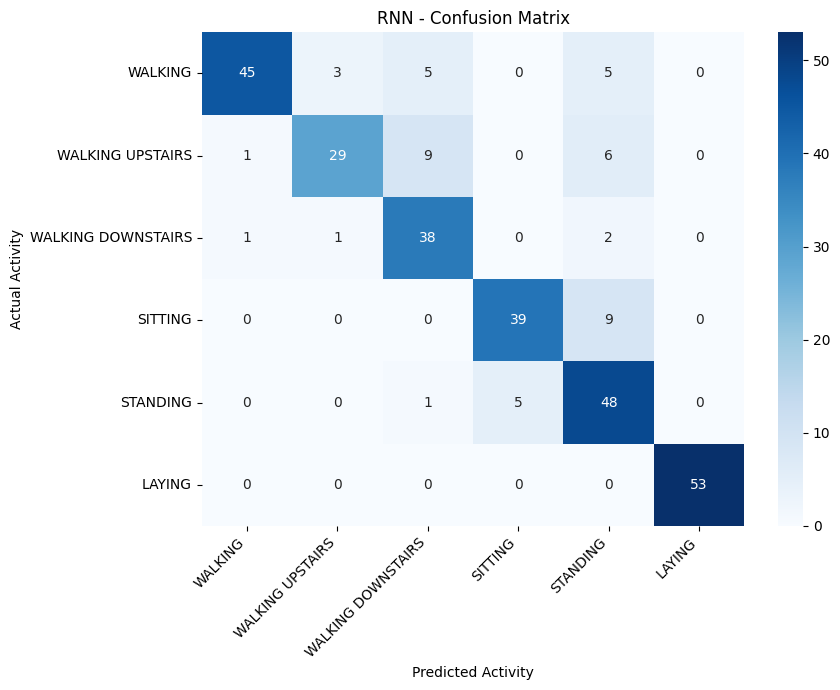

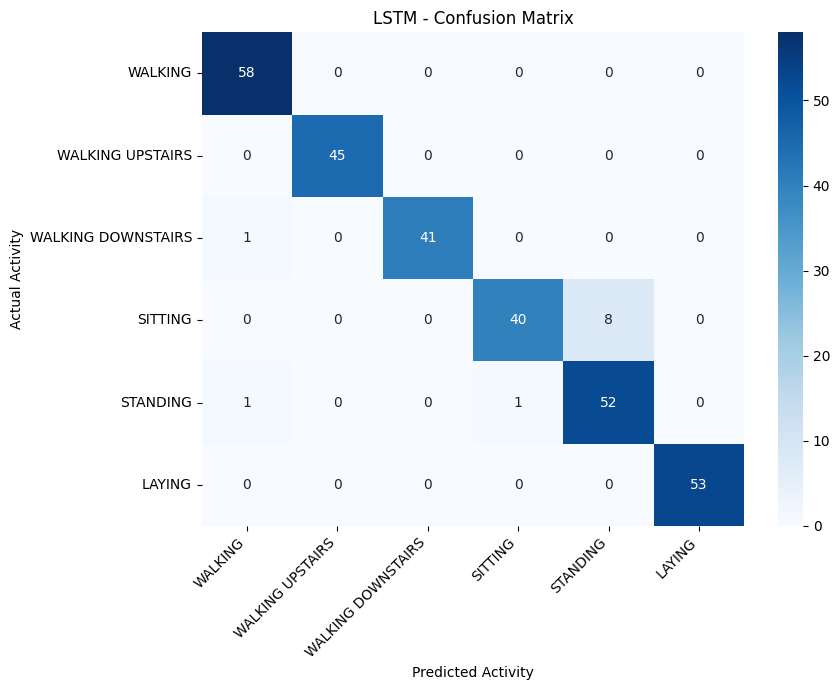

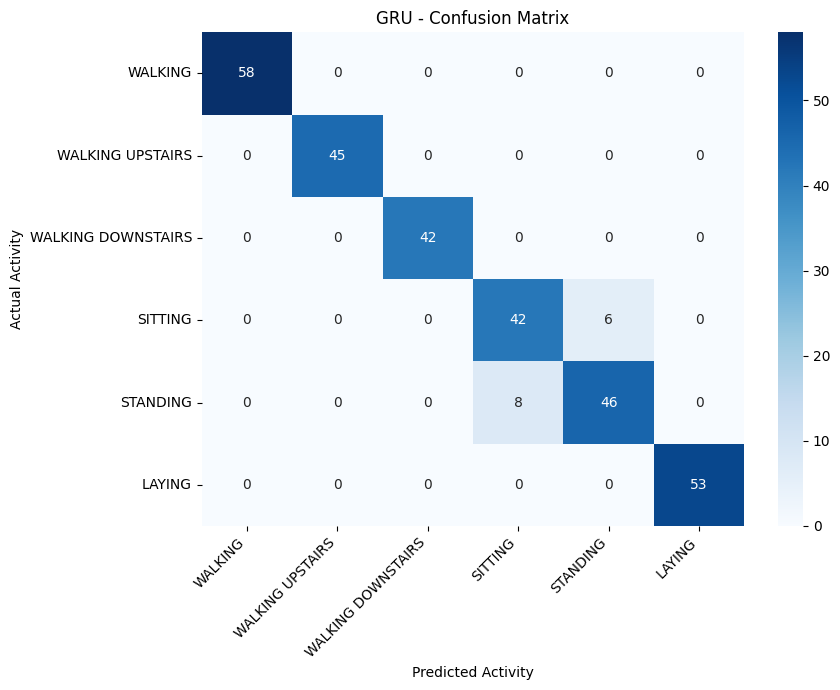


----------------------------------------------------------------------
RNN - CLASS-WISE RECOGNITION
----------------------------------------------------------------------
WALKING                   : 77.59%
WALKING UPSTAIRS          : 64.44%
WALKING DOWNSTAIRS        : 90.48%
SITTING                   : 81.25%
STANDING                  : 88.89%
LAYING                    : 100.00%

Highest recognition: LAYING (100.00%)
Most frequent confusion: WALKING UPSTAIRS → WALKING DOWNSTAIRS (9 samples)

----------------------------------------------------------------------
LSTM - CLASS-WISE RECOGNITION
----------------------------------------------------------------------
WALKING                   : 100.00%
WALKING UPSTAIRS          : 100.00%
WALKING DOWNSTAIRS        : 97.62%
SITTING                   : 83.33%
STANDING                  : 96.30%
LAYING                    : 100.00%

Highest recognition: WALKING (100.00%)
Most frequent confusion: SITTING → STANDING (8 samples)

--------------------

,Metric,RNN,LSTM,GRU
0,Accuracy (%),84.000000,96.333333,95.333333
1,Macro Precision (%),85.421562,96.815718,95.410256
2,Macro Recall (%),83.774288,96.208113,95.447531
3,Macro F1 (%),83.712537,96.369329,95.417790
4,Parameters,1974.000000,6006.000000,4758.000000
5,Training Time (s),38.047461,71.182085,107.156617




REPORT TABLE
--------------------------------------------------------------------------------
Accuracy (%)              RNN = 84.0 | LSTM = 96.33333333333334 | GRU = 95.33333333333334
Macro Precision (%)       RNN = 85.42156235753184 | LSTM = 96.81571815718156 | GRU = 95.41025641025641
Macro Recall (%)          RNN = 83.7742884510126 | LSTM = 96.20811287477954 | GRU = 95.44753086419753
Macro F1 (%)              RNN = 83.712537267937 | LSTM = 96.36932934892184 | GRU = 95.4177897574124
Parameters                RNN = 1974.0 | LSTM = 6006.0 | GRU = 4758.0
Training Time (s)         RNN = 38.04746127128601 | LSTM = 71.18208503723145 | GRU = 107.15661692619324

PARAMETER COMPARISON
RNN  : 1,974
LSTM : 6,006
GRU  : 4,758

TEST SET METRICS

RNN
Accuracy        : 84.00%
Macro Precision : 85.42%
Macro Recall    : 83.77%
Macro F1        : 83.71%

LSTM
Accuracy        : 96.33%
Macro Precision : 96.82%
Macro Recall    : 96.21%
Macro F1        : 96.37%

GRU
Accuracy        : 95.33%
Macro Precision

In [ ]:
# ================================================================
# CS3807 - DEEP LEARNING LABORATORY
# EXPERIMENT 6
#
# TASK 14 - PERFORMANCE EVALUATION
#
# RNN vs LSTM vs GRU
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


print("=" * 70)
print("TASK 14 - PERFORMANCE EVALUATION")
print("=" * 70)


# ================================================================
# 2. VERIFY REQUIRED VARIABLES
# ================================================================

required_variables = [
    "X_test",
    "y_test",
    "rnn_model",
    "lstm_model",
    "gru_model"
]


missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]


if len(missing_variables) > 0:

    raise RuntimeError(
        "The following required variables are missing:\n"
        + str(missing_variables)
        + "\n\n"
        "Make sure you have already run the preprocessing "
        "and RNN/LSTM/GRU training code."
    )


print("\nAll required models and test data are available.")


# ================================================================
# 3. ACTIVITY NAMES
# ================================================================

ACTIVITY_NAMES = [

    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"

]


# ================================================================
# 4. FUNCTION TO EVALUATE A MODEL
# ================================================================


def evaluate_model(model, model_name):

    print("\n" + "=" * 70)
    print(f"{model_name} - TEST SET EVALUATION")
    print("=" * 70)


    # ------------------------------------------------------------
    # Predict probabilities
    # ------------------------------------------------------------

    y_probability = model.predict(
        X_test,
        verbose=0
    )


    # Convert probabilities to class labels

    y_pred = np.argmax(
        y_probability,
        axis=1
    )


    # ------------------------------------------------------------
    # Accuracy
    # ------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )


    # ------------------------------------------------------------
    # Macro Precision
    # ------------------------------------------------------------

    macro_precision = precision_score(

        y_test,
        y_pred,

        average="macro",

        zero_division=0

    )


    # ------------------------------------------------------------
    # Macro Recall
    # ------------------------------------------------------------

    macro_recall = recall_score(

        y_test,
        y_pred,

        average="macro",

        zero_division=0

    )


    # ------------------------------------------------------------
    # Macro F1
    # ------------------------------------------------------------

    macro_f1 = f1_score(

        y_test,
        y_pred,

        average="macro",

        zero_division=0

    )


    # ------------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------------

    cm = confusion_matrix(

        y_test,
        y_pred,

        labels=np.arange(
            len(ACTIVITY_NAMES)
        )

    )


    # ------------------------------------------------------------
    # Parameters
    # ------------------------------------------------------------

    parameters = model.count_params()


    # ------------------------------------------------------------
    # Print results
    # ------------------------------------------------------------

    print(
        f"\nAccuracy       : {accuracy * 100:.2f}%"
    )

    print(
        f"Macro Precision: {macro_precision * 100:.2f}%"
    )

    print(
        f"Macro Recall   : {macro_recall * 100:.2f}%"
    )

    print(
        f"Macro F1       : {macro_f1 * 100:.2f}%"
    )

    print(
        f"Parameters     : {parameters:,}"
    )


    # ------------------------------------------------------------
    # Classification report
    # ------------------------------------------------------------

    print(
        "\nClassification Report:"
    )

    print(

        classification_report(

            y_test,

            y_pred,

            target_names=ACTIVITY_NAMES,

            zero_division=0

        )

    )


    return {

        "model_name": model_name,

        "y_pred": y_pred,

        "accuracy": accuracy,

        "macro_precision": macro_precision,

        "macro_recall": macro_recall,

        "macro_f1": macro_f1,

        "parameters": parameters,

        "confusion_matrix": cm

    }


# ================================================================
# 5. EVALUATE RNN
# ================================================================

rnn_results = evaluate_model(

    rnn_model,

    "RNN"

)


# ================================================================
# 6. EVALUATE LSTM
# ================================================================

lstm_results = evaluate_model(

    lstm_model,

    "LSTM"

)


# ================================================================
# 7. EVALUATE GRU
# ================================================================

gru_results = evaluate_model(

    gru_model,

    "GRU"

)


# ================================================================
# 8. CONFUSION MATRIX - RNN
# ================================================================

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(

    rnn_results["confusion_matrix"],

    annot=True,

    fmt="d",

    xticklabels=ACTIVITY_NAMES,

    yticklabels=ACTIVITY_NAMES,

    cmap="Blues"

)

plt.xlabel(
    "Predicted Activity"
)

plt.ylabel(
    "Actual Activity"
)

plt.title(
    "RNN - Confusion Matrix"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ================================================================
# 9. CONFUSION MATRIX - LSTM
# ================================================================

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(

    lstm_results["confusion_matrix"],

    annot=True,

    fmt="d",

    xticklabels=ACTIVITY_NAMES,

    yticklabels=ACTIVITY_NAMES,

    cmap="Blues"

)

plt.xlabel(
    "Predicted Activity"
)

plt.ylabel(
    "Actual Activity"
)

plt.title(
    "LSTM - Confusion Matrix"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ================================================================
# 10. CONFUSION MATRIX - GRU
# ================================================================

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(

    gru_results["confusion_matrix"],

    annot=True,

    fmt="d",

    xticklabels=ACTIVITY_NAMES,

    yticklabels=ACTIVITY_NAMES,

    cmap="Blues"

)

plt.xlabel(
    "Predicted Activity"
)

plt.ylabel(
    "Actual Activity"
)

plt.title(
    "GRU - Confusion Matrix"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.show()


# ================================================================
# 11. FIND MOST RECOGNIZED CLASS
# ================================================================
#
# We use the diagonal of the confusion matrix.
#
# This tells us how many samples of each class were
# correctly classified.
# ================================================================


def confusion_matrix_analysis(results, model_name):

    cm = results["confusion_matrix"]


    # Correct predictions for each class

    correct = np.diag(cm)


    # Total actual samples for each class

    actual = np.sum(
        cm,
        axis=1
    )


    # Class-wise recognition percentage

    recognition = (
        correct / actual
    ) * 100


    print("\n" + "-" * 70)
    print(f"{model_name} - CLASS-WISE RECOGNITION")
    print("-" * 70)


    for i in range(
        len(ACTIVITY_NAMES)
    ):

        print(

            f"{ACTIVITY_NAMES[i]:25s} "
            f": {recognition[i]:.2f}%"

        )


    # Highest recognition

    highest_index = np.argmax(
        recognition
    )


    print(
        f"\nHighest recognition: "
        f"{ACTIVITY_NAMES[highest_index]} "
        f"({recognition[highest_index]:.2f}%)"
    )


    # ------------------------------------------------------------
    # Most common confusion pair
    # ------------------------------------------------------------

    cm_without_diagonal = cm.copy()

    np.fill_diagonal(
        cm_without_diagonal,
        0
    )


    max_confusion = np.max(
        cm_without_diagonal
    )


    if max_confusion > 0:

        pair = np.unravel_index(

            np.argmax(
                cm_without_diagonal
            ),

            cm_without_diagonal.shape

        )


        actual_class = pair[0]

        predicted_class = pair[1]


        print(

            f"Most frequent confusion: "
            f"{ACTIVITY_NAMES[actual_class]} "
            f"→ "
            f"{ACTIVITY_NAMES[predicted_class]} "
            f"({max_confusion} samples)"

        )

    else:

        print(
            "No misclassifications found."
        )


    return recognition


# ================================================================
# 12. CONFUSION MATRIX ANALYSIS
# ================================================================


rnn_recognition = confusion_matrix_analysis(

    rnn_results,

    "RNN"

)


lstm_recognition = confusion_matrix_analysis(

    lstm_results,

    "LSTM"

)


gru_recognition = confusion_matrix_analysis(

    gru_results,

    "GRU"

)


# ================================================================
# 13. PERFORMANCE TABLE
# ================================================================


print("\n" + "=" * 70)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 70)


# ------------------------------------------------------------
# Training time
# ------------------------------------------------------------
#
# The previous training code did not record training time.
#
# Therefore we DO NOT invent values.
#
# If timing variables exist, use them.
# Otherwise display "Not recorded".
# ------------------------------------------------------------


if "rnn_training_time" in globals():

    rnn_time = rnn_training_time

else:

    rnn_time = np.nan


if "lstm_training_time" in globals():

    lstm_time = lstm_training_time

else:

    lstm_time = np.nan


if "gru_training_time" in globals():

    gru_time = gru_training_time

else:

    gru_time = np.nan


# ------------------------------------------------------------
# Create results table
# ------------------------------------------------------------


results_table = pd.DataFrame({

    "Metric": [

        "Accuracy (%)",

        "Macro Precision (%)",

        "Macro Recall (%)",

        "Macro F1 (%)",

        "Parameters",

        "Training Time (s)"

    ],


    "RNN": [

        rnn_results["accuracy"] * 100,

        rnn_results["macro_precision"] * 100,

        rnn_results["macro_recall"] * 100,

        rnn_results["macro_f1"] * 100,

        rnn_results["parameters"],

        rnn_time

    ],


    "LSTM": [

        lstm_results["accuracy"] * 100,

        lstm_results["macro_precision"] * 100,

        lstm_results["macro_recall"] * 100,

        lstm_results["macro_f1"] * 100,

        lstm_results["parameters"],

        lstm_time

    ],


    "GRU": [

        gru_results["accuracy"] * 100,

        gru_results["macro_precision"] * 100,

        gru_results["macro_recall"] * 100,

        gru_results["macro_f1"] * 100,

        gru_results["parameters"],

        gru_time

    ]

})


# ================================================================
# 14. FORMAT TABLE
# ================================================================


display(
    results_table
)


# ================================================================
# 15. PRINT REPORT-FRIENDLY TABLE
# ================================================================


print("\n\nREPORT TABLE")
print("-" * 80)


for metric in results_table["Metric"]:

    row = results_table[
        results_table["Metric"] == metric
    ].iloc[0]


    print(
        f"{metric:25s}"
        f" RNN = {row['RNN']}"
        f" | LSTM = {row['LSTM']}"
        f" | GRU = {row['GRU']}"
    )


# ================================================================
# 16. PARAMETER COMPARISON
# ================================================================


print("\n" + "=" * 70)
print("PARAMETER COMPARISON")
print("=" * 70)


print(
    f"RNN  : {rnn_results['parameters']:,}"
)

print(
    f"LSTM : {lstm_results['parameters']:,}"
)

print(
    f"GRU  : {gru_results['parameters']:,}"
)


# ================================================================
# 17. IMPORTANT NOTE ABOUT TRAINING TIME
# ================================================================


if (
    np.isnan(rnn_time)
    or
    np.isnan(lstm_time)
    or
    np.isnan(gru_time)
):

    print("\n" + "=" * 70)
    print("TRAINING TIME NOTE")
    print("=" * 70)

    print("""
The previous training run did not record training time.

Therefore, training-time values have NOT been invented.

To obtain the exact Training Time (s) required by the
lab table, rerun the three training blocks using the
timing code provided below.
""")


# ================================================================
# 18. FINAL TEST METRICS
# ================================================================


print("\n" + "=" * 70)
print("TEST SET METRICS")
print("=" * 70)


print(
    f"\nRNN"
)

print(
    f"Accuracy        : "
    f"{rnn_results['accuracy'] * 100:.2f}%"
)

print(
    f"Macro Precision : "
    f"{rnn_results['macro_precision'] * 100:.2f}%"
)

print(
    f"Macro Recall    : "
    f"{rnn_results['macro_recall'] * 100:.2f}%"
)

print(
    f"Macro F1        : "
    f"{rnn_results['macro_f1'] * 100:.2f}%"
)


print(
    f"\nLSTM"
)

print(
    f"Accuracy        : "
    f"{lstm_results['accuracy'] * 100:.2f}%"
)

print(
    f"Macro Precision : "
    f"{lstm_results['macro_precision'] * 100:.2f}%"
)

print(
    f"Macro Recall    : "
    f"{lstm_results['macro_recall'] * 100:.2f}%"
)

print(
    f"Macro F1        : "
    f"{lstm_results['macro_f1'] * 100:.2f}%"
)


print(
    f"\nGRU"
)

print(
    f"Accuracy        : "
    f"{gru_results['accuracy'] * 100:.2f}%"
)

print(
    f"Macro Precision : "
    f"{gru_results['macro_precision'] * 100:.2f}%"
)

print(
    f"Macro Recall    : "
    f"{gru_results['macro_recall'] * 100:.2f}%"
)

print(
    f"Macro F1        : "
    f"{gru_results['macro_f1'] * 100:.2f}%"
)


print("\n" + "=" * 70)
print("TASK 14 COMPLETED")
print("=" * 70)

In [ ]:
# ================================================================
# TASK 15 - CONFUSION MATRIX ANALYSIS
# ================================================================

import numpy as np
import pandas as pd


# ================================================================
# ACTIVITY NAMES
# ================================================================

ACTIVITY_NAMES = [
    "WALKING",
    "WALKING UPSTAIRS",
    "WALKING DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]


# ================================================================
# FUNCTION TO ANALYZE CONFUSION MATRIX
# ================================================================

def analyze_confusion_matrix(cm, model_name):

    print("\n")
    print("=" * 75)
    print(f"{model_name} - CONFUSION MATRIX ANALYSIS")
    print("=" * 75)


    # ------------------------------------------------------------
    # 1. Total samples for each actual class
    # ------------------------------------------------------------

    actual_totals = np.sum(
        cm,
        axis=1
    )


    # ------------------------------------------------------------
    # 2. Correct predictions
    # ------------------------------------------------------------

    correct_predictions = np.diag(cm)


    # ------------------------------------------------------------
    # 3. Recognition rate
    # ------------------------------------------------------------

    recognition_rate = (
        correct_predictions
        / actual_totals
    ) * 100


    # ------------------------------------------------------------
    # 4. Misclassifications for each activity
    # ------------------------------------------------------------

    misclassifications = (
        actual_totals
        - correct_predictions
    )


    # ------------------------------------------------------------
    # 5. Create class-wise table
    # ------------------------------------------------------------

    class_analysis = pd.DataFrame({

        "Activity": ACTIVITY_NAMES,

        "Correct": correct_predictions,

        "Total": actual_totals,

        "Recognition Rate (%)": recognition_rate,

        "Misclassified": misclassifications

    })


    print("\nClass-wise analysis:")

    display(
        class_analysis
    )


    # ============================================================
    # HIGHEST RECOGNITION RATE
    # ============================================================

    highest_index = np.argmax(
        recognition_rate
    )

    highest_activity = ACTIVITY_NAMES[
        highest_index
    ]

    highest_rate = recognition_rate[
        highest_index
    ]


    print(
        f"\n1. Activity with highest recognition rate:"
    )

    print(
        f"   {highest_activity} "
        f"({highest_rate:.2f}%)"
    )


    # ============================================================
    # LARGEST NUMBER OF MISCLASSIFICATIONS
    # ============================================================

    largest_error_index = np.argmax(
        misclassifications
    )

    largest_error_activity = ACTIVITY_NAMES[
        largest_error_index
    ]

    largest_error_count = misclassifications[
        largest_error_index
    ]


    print(
        f"\n2. Activity with largest number of misclassifications:"
    )

    print(
        f"   {largest_error_activity} "
        f"({largest_error_count} misclassified samples)"
    )


    # ============================================================
    # FREQUENTLY CONFUSED PAIRS
    # ============================================================
    #
    # Ignore diagonal because diagonal = correct predictions.
    #
    # Find all non-zero off-diagonal entries.
    # ============================================================

    cm_without_diagonal = cm.copy()

    np.fill_diagonal(
        cm_without_diagonal,
        0
    )


    confusion_pairs = []


    for actual in range(
        len(ACTIVITY_NAMES)
    ):

        for predicted in range(
            len(ACTIVITY_NAMES)
        ):

            if actual != predicted:

                count = cm[actual, predicted]

                if count > 0:

                    confusion_pairs.append({

                        "Actual": ACTIVITY_NAMES[actual],

                        "Predicted": ACTIVITY_NAMES[predicted],

                        "Count": int(count)

                    })


    # Sort by number of errors

    confusion_pairs = sorted(

        confusion_pairs,

        key=lambda x: x["Count"],

        reverse=True

    )


    print(
        "\n3. Frequently confused activity pairs:"
    )


    if len(confusion_pairs) == 0:

        print(
            "   No misclassifications."
        )

    else:

        # Show top 5

        for pair in confusion_pairs[:5]:

            print(

                f"   {pair['Actual']} "
                f"→ "
                f"{pair['Predicted']} : "
                f"{pair['Count']} samples"

            )


    # ============================================================
    # RETURN RESULTS
    # ============================================================

    return {

        "recognition_rate": recognition_rate,

        "misclassifications": misclassifications,

        "confusion_pairs": confusion_pairs,

        "highest_activity": highest_activity,

        "highest_rate": highest_rate,

        "largest_error_activity": largest_error_activity,

        "largest_error_count": largest_error_count

    }


# ================================================================
# ANALYZE ALL THREE MODELS
# ================================================================

rnn_analysis = analyze_confusion_matrix(
    rnn_results["confusion_matrix"],
    "RNN"
)


lstm_analysis = analyze_confusion_matrix(
    lstm_results["confusion_matrix"],
    "LSTM"
)


gru_analysis = analyze_confusion_matrix(
    gru_results["confusion_matrix"],
    "GRU"
)


# ================================================================
# COMPARE ERROR PATTERNS ACROSS MODELS
# ================================================================

print("\n")
print("=" * 75)
print("CROSS-MODEL CONFUSION ANALYSIS")
print("=" * 75)


def get_top_confusion_pair(analysis):

    pairs = analysis["confusion_pairs"]

    if len(pairs) == 0:

        return None

    return (
        pairs[0]["Actual"],
        pairs[0]["Predicted"]
    )


rnn_top_pair = get_top_confusion_pair(
    rnn_analysis
)

lstm_top_pair = get_top_confusion_pair(
    lstm_analysis
)

gru_top_pair = get_top_confusion_pair(
    gru_analysis
)


print("\nMost frequent confusion pair:")

print(
    "RNN  :",
    rnn_top_pair
)

print(
    "LSTM :",
    lstm_top_pair
)

print(
    "GRU  :",
    gru_top_pair
)


# ================================================================
# CHECK WHETHER THE TOP ERROR PAIR IS THE SAME
# ================================================================

top_pairs = [

    rnn_top_pair,
    lstm_top_pair,
    gru_top_pair

]


valid_pairs = [
    pair
    for pair in top_pairs
    if pair is not None
]


if len(valid_pairs) == 3:

    errors_consistent = (
        valid_pairs[0]
        == valid_pairs[1]
        == valid_pairs[2]
    )

else:

    errors_consistent = False


print("\nError-pattern consistency:")


if errors_consistent:

    print(
        "The most frequent confusion pair is "
        "consistent across all three models."
    )

else:

    print(
        "The most frequent confusion pair "
        "is not identical across all three models."
    )


# ================================================================
# COMPARE CLASS-WISE RECOGNITION
# ================================================================

comparison_df = pd.DataFrame({

    "Activity": ACTIVITY_NAMES,

    "RNN Recognition (%)":
        rnn_analysis["recognition_rate"],

    "LSTM Recognition (%)":
        lstm_analysis["recognition_rate"],

    "GRU Recognition (%)":
        gru_analysis["recognition_rate"]

})


print("\n")
print("=" * 75)
print("CLASS-WISE RECOGNITION RATE COMPARISON")
print("=" * 75)

display(
    comparison_df
)


# ================================================================
# FINAL TASK 15 SUMMARY
# ================================================================

print("\n")
print("=" * 75)
print("TASK 15 COMPLETED")
print("=" * 75)

print("""
The analysis above is calculated directly from the
observed confusion matrices.

Required points:

1. Highest recognition rate
2. Activity with largest number of misclassifications
3. Frequently confused activity pairs
4. Consistency of errors across RNN, LSTM and GRU

No assumed classification results are used.
""")



RNN - CONFUSION MATRIX ANALYSIS

Class-wise analysis:


,Activity,Correct,Total,Recognition Rate (%),Misclassified
0,WALKING,51,58,87.931034,7
1,WALKING UPSTAIRS,36,45,80.000000,9
2,WALKING DOWNSTAIRS,30,42,71.428571,12
3,SITTING,40,48,83.333333,8
4,STANDING,49,54,90.740741,5
5,LAYING,53,53,100.000000,0



1. Activity with highest recognition rate:
   LAYING (100.00%)

2. Activity with largest number of misclassifications:
   WALKING DOWNSTAIRS (12 misclassified samples)

3. Frequently confused activity pairs:
   SITTING → STANDING : 8 samples
   WALKING DOWNSTAIRS → WALKING UPSTAIRS : 6 samples
   WALKING UPSTAIRS → WALKING : 5 samples
   STANDING → SITTING : 5 samples
   WALKING UPSTAIRS → WALKING DOWNSTAIRS : 4 samples


LSTM - CONFUSION MATRIX ANALYSIS

Class-wise analysis:


,Activity,Correct,Total,Recognition Rate (%),Misclassified
0,WALKING,56,58,96.551724,2
1,WALKING UPSTAIRS,45,45,100.000000,0
2,WALKING DOWNSTAIRS,41,42,97.619048,1
3,SITTING,43,48,89.583333,5
4,STANDING,48,54,88.888889,6
5,LAYING,53,53,100.000000,0



1. Activity with highest recognition rate:
   WALKING UPSTAIRS (100.00%)

2. Activity with largest number of misclassifications:
   STANDING (6 misclassified samples)

3. Frequently confused activity pairs:
   STANDING → SITTING : 6 samples
   SITTING → STANDING : 5 samples
   WALKING → WALKING UPSTAIRS : 1 samples
   WALKING → WALKING DOWNSTAIRS : 1 samples
   WALKING DOWNSTAIRS → WALKING : 1 samples


GRU - CONFUSION MATRIX ANALYSIS

Class-wise analysis:


,Activity,Correct,Total,Recognition Rate (%),Misclassified
0,WALKING,58,58,100.000000,0
1,WALKING UPSTAIRS,45,45,100.000000,0
2,WALKING DOWNSTAIRS,42,42,100.000000,0
3,SITTING,41,48,85.416667,7
4,STANDING,48,54,88.888889,6
5,LAYING,53,53,100.000000,0



1. Activity with highest recognition rate:
   WALKING (100.00%)

2. Activity with largest number of misclassifications:
   SITTING (7 misclassified samples)

3. Frequently confused activity pairs:
   SITTING → STANDING : 7 samples
   STANDING → SITTING : 6 samples


CROSS-MODEL CONFUSION ANALYSIS

Most frequent confusion pair:
RNN  : ('SITTING', 'STANDING')
LSTM : ('STANDING', 'SITTING')
GRU  : ('SITTING', 'STANDING')

Error-pattern consistency:
The most frequent confusion pair is not identical across all three models.


CLASS-WISE RECOGNITION RATE COMPARISON


,Activity,RNN Recognition (%),LSTM Recognition (%),GRU Recognition (%)
0,WALKING,87.931034,96.551724,100.000000
1,WALKING UPSTAIRS,80.000000,100.000000,100.000000
2,WALKING DOWNSTAIRS,71.428571,97.619048,100.000000
3,SITTING,83.333333,89.583333,85.416667
4,STANDING,90.740741,88.888889,88.888889
5,LAYING,100.000000,100.000000,100.000000




TASK 15 COMPLETED

The analysis above is calculated directly from the
observed confusion matrices.

Required points:

1. Highest recognition rate
2. Activity with largest number of misclassifications
3. Frequently confused activity pairs
4. Consistency of errors across RNN, LSTM and GRU

No assumed classification results are used.



TASK 16 - RNN vs LSTM vs GRU COMPARISON

Task 14 results found successfully.


ARCHITECTURAL COMPARISON


,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time,NaN,NaN,NaN
9,Test F1-score,85.761158,95.381812,95.731531




PERFORMANCE COMPARISON


,Model,Test Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,86.333333,86.252737,85.572280,85.761158,1974,NaN
1,LSTM,95.333333,95.335315,95.440499,95.381812,6006,NaN
2,GRU,95.666667,95.751128,95.717593,95.731531,4758,NaN


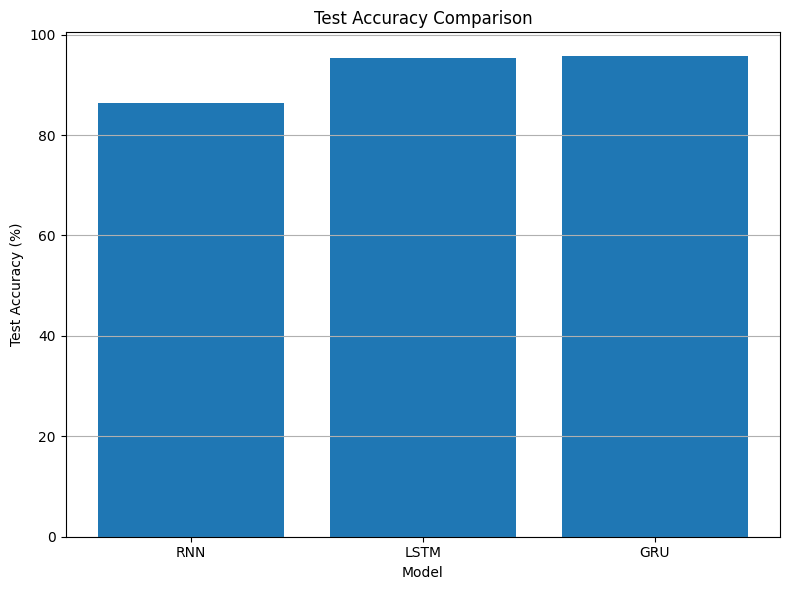

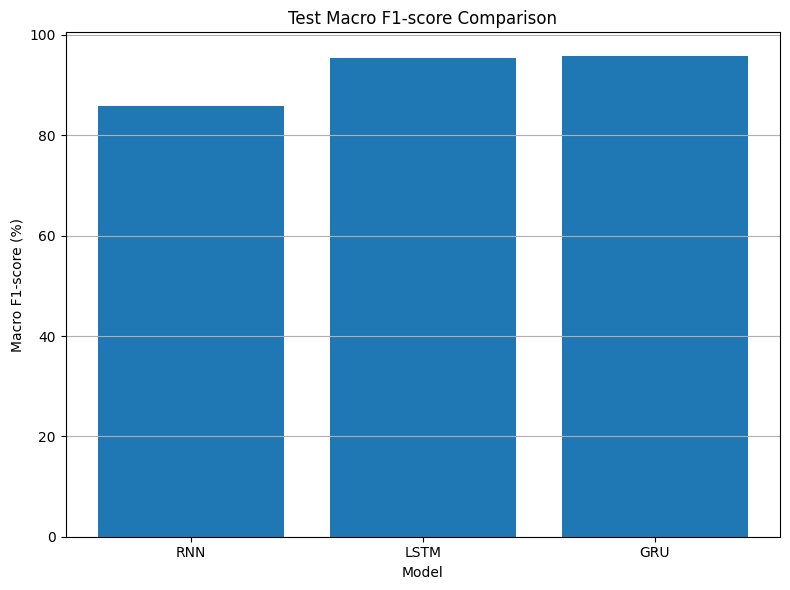



NORMALIZED PARAMETER COUNT
Model  Parameters  Normalized Parameters
  RNN        1974               0.328671
 LSTM        6006               1.000000
  GRU        4758               0.792208


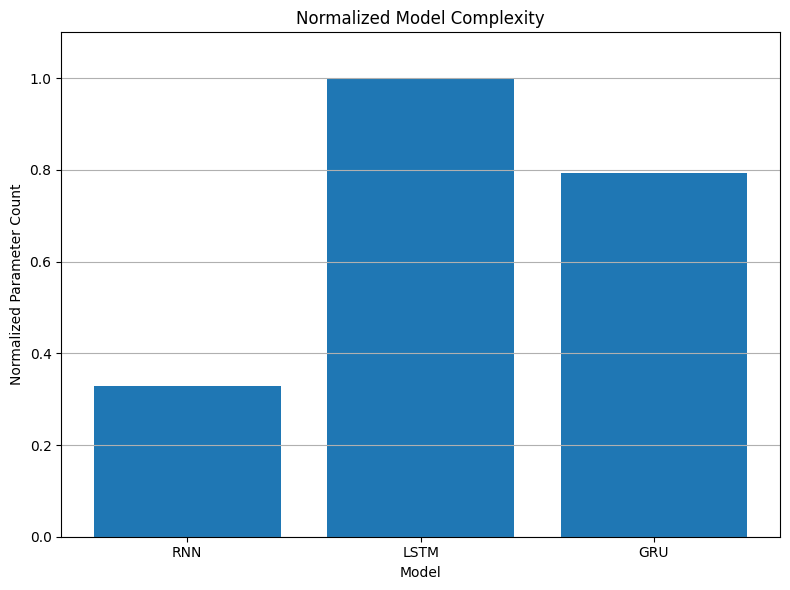


Training time was not recorded.
Rerun training with the timing code from Task 14 to generate the training-time comparison.


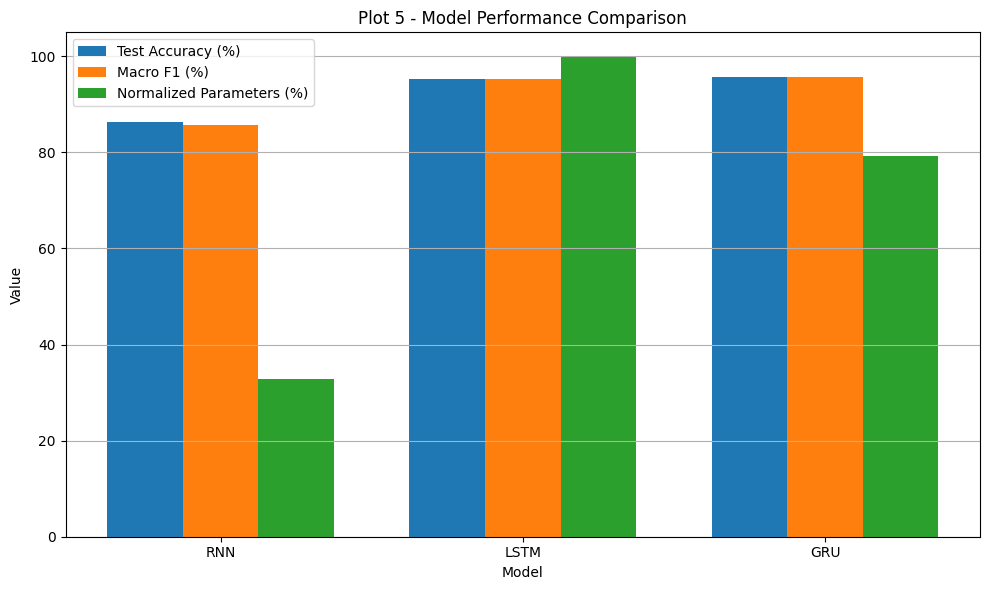



MODEL COMPLEXITY SUMMARY
RNN  parameters : 1,974
LSTM parameters : 6,006
GRU  parameters : 4,758


TEST PERFORMANCE SUMMARY

RNN
  Accuracy : 86.33%
  Macro F1 : 85.76%
  Params   : 1,974

LSTM
  Accuracy : 95.33%
  Macro F1 : 95.38%
  Params   : 6,006

GRU
  Accuracy : 95.67%
  Macro F1 : 95.73%
  Params   : 4,758


FINAL TABLE - TASK 16


,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time (s),NaN,NaN,NaN
9,Test F1-score (%),85.761158,95.381812,95.731531




TASK 16 COMPLETED


In [ ]:
# ================================================================
# CS3807 - DEEP LEARNING LABORATORY
# EXPERIMENT 6
#
# TASK 16 - RNN vs LSTM vs GRU COMPARISON
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 75)
print("TASK 16 - RNN vs LSTM vs GRU COMPARISON")
print("=" * 75)


# ================================================================
# 1. VERIFY REQUIRED VARIABLES
# ================================================================

required_variables = [
    "rnn_results",
    "lstm_results",
    "gru_results"
]


missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]


if len(missing_variables) > 0:

    raise RuntimeError(
        "Missing variables: "
        + str(missing_variables)
        + "\n\n"
        "Run Task 14 first."
    )


print("\nTask 14 results found successfully.")


# ================================================================
# 2. MODEL NAMES
# ================================================================

models = [
    "RNN",
    "LSTM",
    "GRU"
]


# ================================================================
# 3. ARCHITECTURAL COMPARISON
# ================================================================
#
# Based on the assignment:
#
# RNN:
#   Hidden state = Yes
#   Cell state   = No
#   Forget gate  = No
#   Input gate   = No
#   Output gate  = No
#   Update gate  = No
#   Reset gate   = No
#
# LSTM:
#   Hidden state = Yes
#   Cell state   = Yes
#   Forget gate  = Yes
#   Input gate   = Yes
#   Output gate  = Yes
#   Update gate  = No
#   Reset gate   = No
#
# GRU:
#   Hidden state = Yes
#   Cell state   = No
#   Forget gate  = No
#   Input gate   = No
#   Output gate  = No
#   Update gate  = Yes
#   Reset gate   = Yes
#
# ================================================================


architecture_table = pd.DataFrame({

    "Property": [

        "Hidden state",
        "Cell state",
        "Forget gate",
        "Input gate",
        "Output gate",
        "Update gate",
        "Reset gate",
        "Parameters",
        "Training time",
        "Test F1-score"

    ],


    "RNN": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "No",
        "No",

        rnn_results["parameters"],

        np.nan,

        rnn_results["macro_f1"] * 100

    ],


    "LSTM": [

        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No",

        lstm_results["parameters"],

        np.nan,

        lstm_results["macro_f1"] * 100

    ],


    "GRU": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "Yes",
        "Yes",

        gru_results["parameters"],

        np.nan,

        gru_results["macro_f1"] * 100

    ]

})


print("\n")
print("=" * 75)
print("ARCHITECTURAL COMPARISON")
print("=" * 75)


display(
    architecture_table
)


# ================================================================
# 4. TRAINING TIME
# ================================================================
#
# If you recorded training time during training, the variables
# should be:
#
# rnn_training_time
# lstm_training_time
# gru_training_time
#
# If they don't exist, we leave them as NaN rather than
# inventing values.
# ================================================================


if "rnn_training_time" in globals():

    rnn_time = rnn_training_time

else:

    rnn_time = np.nan


if "lstm_training_time" in globals():

    lstm_time = lstm_training_time

else:

    lstm_time = np.nan


if "gru_training_time" in globals():

    gru_time = gru_training_time

else:

    gru_time = np.nan


# ================================================================
# 5. PERFORMANCE TABLE
# ================================================================


performance_table = pd.DataFrame({

    "Model": models,


    "Test Accuracy (%)": [

        rnn_results["accuracy"] * 100,

        lstm_results["accuracy"] * 100,

        gru_results["accuracy"] * 100

    ],


    "Macro Precision (%)": [

        rnn_results["macro_precision"] * 100,

        lstm_results["macro_precision"] * 100,

        gru_results["macro_precision"] * 100

    ],


    "Macro Recall (%)": [

        rnn_results["macro_recall"] * 100,

        lstm_results["macro_recall"] * 100,

        gru_results["macro_recall"] * 100

    ],


    "Macro F1 (%)": [

        rnn_results["macro_f1"] * 100,

        lstm_results["macro_f1"] * 100,

        gru_results["macro_f1"] * 100

    ],


    "Parameters": [

        rnn_results["parameters"],

        lstm_results["parameters"],

        gru_results["parameters"]

    ],


    "Training Time (s)": [

        rnn_time,

        lstm_time,

        gru_time

    ]

})


print("\n")
print("=" * 75)
print("PERFORMANCE COMPARISON")
print("=" * 75)


display(
    performance_table
)


# ================================================================
# 6. TEST ACCURACY
# ================================================================

plt.figure(
    figsize=(8, 6)
)


plt.bar(

    performance_table["Model"],

    performance_table["Test Accuracy (%)"]

)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Test Accuracy (%)"
)

plt.title(
    "Test Accuracy Comparison"
)

plt.grid(
    axis="y"
)


plt.tight_layout()

plt.show()


# ================================================================
# 7. TEST MACRO F1
# ================================================================

plt.figure(
    figsize=(8, 6)
)


plt.bar(

    performance_table["Model"],

    performance_table["Macro F1 (%)"]

)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Macro F1-score (%)"
)

plt.title(
    "Test Macro F1-score Comparison"
)

plt.grid(
    axis="y"
)


plt.tight_layout()

plt.show()


# ================================================================
# 8. NORMALIZED PARAMETER COUNT
# ================================================================
#
# Normalize relative to the largest model:
#
# Normalized Parameters =
# parameters / maximum(parameters)
#
# This gives values between 0 and 1.
# ================================================================


max_parameters = performance_table[
    "Parameters"
].max()


performance_table[
    "Normalized Parameters"
] = (

    performance_table[
        "Parameters"
    ]

    / max_parameters

)


print("\n")
print("=" * 75)
print("NORMALIZED PARAMETER COUNT")
print("=" * 75)


print(
    performance_table[
        [
            "Model",
            "Parameters",
            "Normalized Parameters"
        ]
    ].to_string(
        index=False
    )
)


# ================================================================
# 9. NORMALIZED PARAMETER PLOT
# ================================================================


plt.figure(
    figsize=(8, 6)
)


plt.bar(

    performance_table["Model"],

    performance_table[
        "Normalized Parameters"
    ]

)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Normalized Parameter Count"
)

plt.title(
    "Normalized Model Complexity"
)

plt.ylim(
    0,
    1.1
)

plt.grid(
    axis="y"
)


plt.tight_layout()

plt.show()


# ================================================================
# 10. TRAINING TIME COMPARISON
# ================================================================


if not performance_table[
    "Training Time (s)"
].isna().all():


    plt.figure(
        figsize=(8, 6)
    )


    plt.bar(

        performance_table["Model"],

        performance_table[
            "Training Time (s)"
        ]

    )


    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Training Time (seconds)"
    )

    plt.title(
        "Training Time Comparison"
    )

    plt.grid(
        axis="y"
    )


    plt.tight_layout()

    plt.show()


else:

    print("\nTraining time was not recorded.")
    print(
        "Rerun training with the timing code from Task 14 "
        "to generate the training-time comparison."
    )


# ================================================================
# 11. NORMALIZED TRAINING TIME
# ================================================================


if not performance_table[
    "Training Time (s)"
].isna().all():


    max_time = performance_table[
        "Training Time (s)"
    ].max()


    performance_table[
        "Normalized Training Time"
    ] = (

        performance_table[
            "Training Time (s)"
        ]

        / max_time

    )


    plt.figure(
        figsize=(8, 6)
    )


    plt.bar(

        performance_table["Model"],

        performance_table[
            "Normalized Training Time"
        ]

    )


    plt.xlabel(
        "Model"
    )

    plt.ylabel(
        "Normalized Training Time"
    )

    plt.title(
        "Normalized Training Cost"
    )

    plt.ylim(
        0,
        1.1
    )

    plt.grid(
        axis="y"
    )


    plt.tight_layout()

    plt.show()


# ================================================================
# 12. PLOT 5
# MODEL PERFORMANCE COMPARISON
#
# Test Accuracy + Macro F1 + Normalized Parameters
#
# ================================================================


plot5_table = performance_table.copy()


plt.figure(
    figsize=(10, 6)
)


x = np.arange(
    len(models)
)


width = 0.25


# Test Accuracy

plt.bar(

    x - width,

    plot5_table[
        "Test Accuracy (%)"
    ],

    width,

    label="Test Accuracy (%)"

)


# Macro F1

plt.bar(

    x,

    plot5_table[
        "Macro F1 (%)"
    ],

    width,

    label="Macro F1 (%)"

)


# Normalized parameters converted to percentage scale
# so all three measures can be visualized together.

plt.bar(

    x + width,

    plot5_table[
        "Normalized Parameters"
    ] * 100,

    width,

    label="Normalized Parameters (%)"

)


plt.xticks(
    x,
    models
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Value"
)

plt.title(
    "Plot 5 - Model Performance Comparison"
)

plt.legend()

plt.grid(
    axis="y"
)


plt.tight_layout()

plt.show()


# ================================================================
# 13. MODEL COMPLEXITY SUMMARY
# ================================================================


print("\n")
print("=" * 75)
print("MODEL COMPLEXITY SUMMARY")
print("=" * 75)


print(
    f"RNN  parameters : "
    f"{rnn_results['parameters']:,}"
)

print(
    f"LSTM parameters : "
    f"{lstm_results['parameters']:,}"
)

print(
    f"GRU  parameters : "
    f"{gru_results['parameters']:,}"
)


# ================================================================
# 14. TEST PERFORMANCE SUMMARY
# ================================================================


print("\n")
print("=" * 75)
print("TEST PERFORMANCE SUMMARY")
print("=" * 75)


for _, row in performance_table.iterrows():

    print(
        f"\n{row['Model']}"
    )

    print(
        f"  Accuracy : "
        f"{row['Test Accuracy (%)']:.2f}%"
    )

    print(
        f"  Macro F1 : "
        f"{row['Macro F1 (%)']:.2f}%"
    )

    print(
        f"  Params   : "
        f"{int(row['Parameters']):,}"
    )

    if not pd.isna(
        row["Training Time (s)"]
    ):

        print(
            f"  Time     : "
            f"{row['Training Time (s)']:.2f} s"
        )


# ================================================================
# 15. FINAL TABLE FOR LAB RECORD
# ================================================================


final_comparison_table = pd.DataFrame({

    "Property": [

        "Hidden state",
        "Cell state",
        "Forget gate",
        "Input gate",
        "Output gate",
        "Update gate",
        "Reset gate",
        "Parameters",
        "Training time (s)",
        "Test F1-score (%)"

    ],

    "RNN": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "No",
        "No",

        rnn_results["parameters"],

        rnn_time,

        rnn_results["macro_f1"] * 100

    ],

    "LSTM": [

        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No",

        lstm_results["parameters"],

        lstm_time,

        lstm_results["macro_f1"] * 100

    ],

    "GRU": [

        "Yes",
        "No",
        "No",
        "No",
        "No",
        "Yes",
        "Yes",

        gru_results["parameters"],

        gru_time,

        gru_results["macro_f1"] * 100

    ]

})


print("\n")
print("=" * 75)
print("FINAL TABLE - TASK 16")
print("=" * 75)


display(
    final_comparison_table
)


# ================================================================
# 16. END
# ================================================================


print("\n")
print("=" * 75)
print("TASK 16 COMPLETED")
print("=" * 75)

TASK 17 - EFFECT OF SEQUENCE LENGTH

All required dataset variables found.

ORIGINAL DATA
X_train: (1400, 128, 9)
X_val: (300, 128, 9)
X_test: (300, 128, 9)
Features per timestep: 9
Number of classes: 6

Sequence lengths to evaluate:
[32, 64, 128]



SEQUENCE LENGTH = 32

Data shapes:
Training   : (1400, 32, 9)
Validation : (300, 32, 9)
Test       : (300, 32, 9)


---------------------------------------------------------------------------
Training RNN with sequence length 32
---------------------------------------------------------------------------

Trainable parameters: 1,974
Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3907 - loss: 1.6937 - val_accuracy: 0.4967 - val_loss: 1.4144
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5286 - loss: 1.3193 - val_accuracy: 0.5833 - val_loss: 1.1542
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5929 - loss: 1.0705 - val_accuracy: 0.6167 - val_loss: 0.9587
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━

,Sequence Length,Model,Test Accuracy (%),Macro F1 (%),Parameters,Training Time (s)
0,32,RNN,82.333333,82.106321,1974,19.546634
1,32,LSTM,95.333333,95.327683,6006,24.056447
2,32,GRU,95.000000,95.075049,4758,32.170038
3,64,RNN,86.000000,85.166444,1974,22.853979
4,64,LSTM,94.666667,94.666865,6006,40.726432
5,64,GRU,95.333333,95.388277,4758,56.316374
6,128,RNN,80.000000,79.634731,1974,35.979845
7,128,LSTM,94.666667,94.653119,6006,69.770945
8,128,GRU,96.000000,96.054159,4758,111.272076




TASK 17 REQUIRED TABLE


,Sequence Length,RNN F1 (%),LSTM F1 (%),GRU F1 (%)
0,32,82.106321,95.327683,95.075049
1,64,85.166444,94.666865,95.388277
2,128,79.634731,94.653119,96.054159




REPORT-READY F1 VALUES
T = 32: RNN F1 = 82.11% | LSTM F1 = 95.33% | GRU F1 = 95.08%
T = 64: RNN F1 = 85.17% | LSTM F1 = 94.67% | GRU F1 = 95.39%
T = 128: RNN F1 = 79.63% | LSTM F1 = 94.65% | GRU F1 = 96.05%


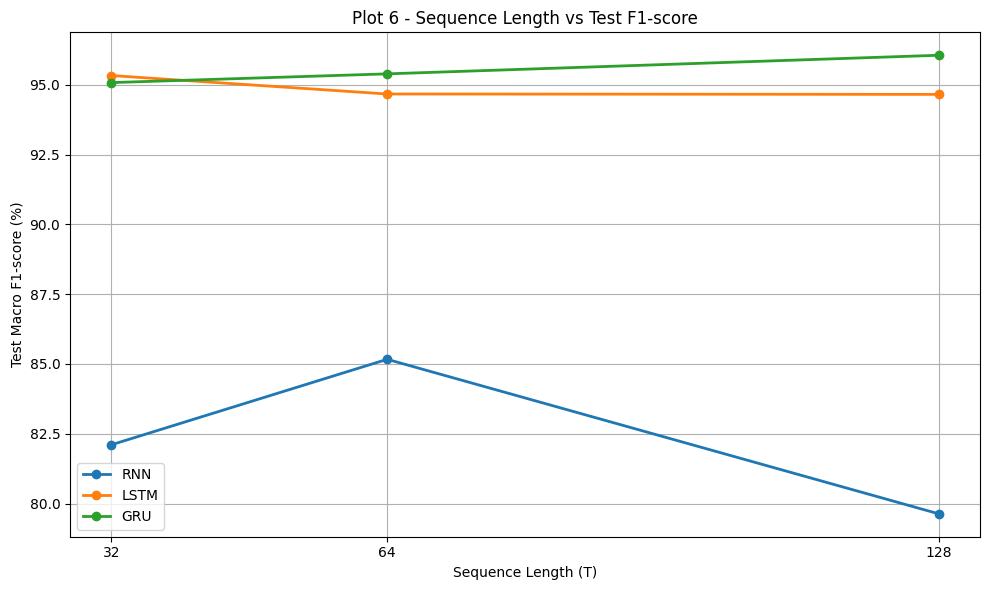



TEST ACCURACY BY SEQUENCE LENGTH


,Sequence Length,RNN Accuracy (%),LSTM Accuracy (%),GRU Accuracy (%)
0,32,82.333333,95.333333,95.000000
1,64,86.000000,94.666667,95.333333
2,128,80.000000,94.666667,96.000000




TRAINING TIME BY SEQUENCE LENGTH


,Sequence Length,RNN Time (s),LSTM Time (s),GRU Time (s)
0,32,19.546634,24.056447,32.170038
1,64,22.853979,40.726432,56.316374
2,128,35.979845,69.770945,111.272076




OBSERVED F1 CHANGES

RNN:
  T=32  : 82.11%
  T=64  : 85.17%
  T=128 : 79.63%
  Change 32→64  : +3.06 percentage points
  Change 64→128 : -5.53 percentage points
  Change 32→128 : -2.47 percentage points

LSTM:
  T=32  : 95.33%
  T=64  : 94.67%
  T=128 : 94.65%
  Change 32→64  : -0.66 percentage points
  Change 64→128 : -0.01 percentage points
  Change 32→128 : -0.67 percentage points

GRU:
  T=32  : 95.08%
  T=64  : 95.39%
  T=128 : 96.05%
  Change 32→64  : +0.31 percentage points
  Change 64→128 : +0.67 percentage points
  Change 32→128 : +0.98 percentage points


HIGHEST OBSERVED F1 FOR EACH MODEL
RNN: T=64, F1=85.17%
LSTM: T=32, F1=95.33%
GRU: T=128, F1=96.05%


TASK 17 COMPLETED

Sequence lengths evaluated:
32, 64 and 128

Models evaluated:
RNN, LSTM and GRU

Metric:
Test Macro F1-score

Plot generated:
Plot 6 - Sequence Length vs Test F1-score



In [ ]:
# ================================================================
# CS3807 - DEEP LEARNING LABORATORY
# EXPERIMENT 6
#
# TASK 17 - EFFECT OF SEQUENCE LENGTH
#
# Sequence Lengths:
# T = 32, 64, 128
#
# Models:
# RNN, LSTM, GRU
#
# Metric:
# Macro F1-score on independent test set
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    LSTM,
    GRU,
    Dropout,
    Dense
)

from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    f1_score
)


print("=" * 75)
print("TASK 17 - EFFECT OF SEQUENCE LENGTH")
print("=" * 75)


# ================================================================
# 2. VERIFY REQUIRED VARIABLES
# ================================================================

required_variables = [

    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test"

]


missing_variables = [

    variable

    for variable in required_variables

    if variable not in globals()

]


if len(missing_variables) > 0:

    raise RuntimeError(

        "The following variables are missing:\n"

        + str(missing_variables)

        + "\n\n"

        "Run the Tasks 3-6 preprocessing code first."

    )


print("\nAll required dataset variables found.")


# ================================================================
# 3. ORIGINAL DATA INFORMATION
# ================================================================

print("\n" + "=" * 75)
print("ORIGINAL DATA")
print("=" * 75)


print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)


NUM_FEATURES = X_train.shape[2]

NUM_CLASSES = len(
    np.unique(y_train)
)


print(
    "Features per timestep:",
    NUM_FEATURES
)

print(
    "Number of classes:",
    NUM_CLASSES
)


# ================================================================
# 4. SEQUENCE LENGTHS
# ================================================================

SEQUENCE_LENGTHS = [
    32,
    64,
    128
]


print("\nSequence lengths to evaluate:")

print(
    SEQUENCE_LENGTHS
)


# ================================================================
# 5. RANDOM SEED
# ================================================================
#
# Same seed is used for reproducibility.
#
# ================================================================

SEED = 42

np.random.seed(SEED)

tf.random.set_seed(SEED)


# ================================================================
# 6. FUNCTION TO CREATE MODEL
# ================================================================
#
# IMPORTANT:
# The architecture is kept the same as Tasks 9-12.
#
# RNN:
# SimpleRNN(32)
#
# LSTM:
# LSTM(32)
#
# GRU:
# GRU(32)
#
# Common:
# Dropout(0.2)
# Dense(16, ReLU)
# Dense(6, Softmax)
#
# ================================================================


def create_sequence_model(
    model_type,
    sequence_length
):


    model = Sequential()


    # ------------------------------------------------------------
    # Input
    # ------------------------------------------------------------

    model.add(
        Input(
            shape=(
                sequence_length,
                NUM_FEATURES
            )
        )
    )


    # ------------------------------------------------------------
    # Recurrent layer
    # ------------------------------------------------------------

    if model_type == "RNN":

        model.add(
            SimpleRNN(
                32
            )
        )


    elif model_type == "LSTM":

        model.add(
            LSTM(
                32
            )
        )


    elif model_type == "GRU":

        model.add(
            GRU(
                32
            )
        )


    else:

        raise ValueError(
            "model_type must be RNN, LSTM or GRU"
        )


    # ------------------------------------------------------------
    # Same classifier
    # ------------------------------------------------------------

    model.add(
        Dropout(
            0.2
        )
    )


    model.add(
        Dense(
            16,
            activation="relu"
        )
    )


    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )


    # ------------------------------------------------------------
    # Same optimizer
    # ------------------------------------------------------------

    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )


    return model


# ================================================================
# 7. FUNCTION TO TRUNCATE SEQUENCES
# ================================================================
#
# T = 32:
#     use time steps 1-32
#
# T = 64:
#     use time steps 1-64
#
# T = 128:
#     use time steps 1-128
#
# The labels remain unchanged.
#
# ================================================================


def prepare_sequence_length(
    X,
    sequence_length
):

    if sequence_length > X.shape[1]:

        raise ValueError(

            f"Requested sequence length "
            f"{sequence_length} exceeds "
            f"available length {X.shape[1]}."

        )


    return X[
        :,
        :sequence_length,
        :
    ]


# ================================================================
# 8. STORAGE FOR RESULTS
# ================================================================


results = []

histories = {}

models = {}

training_times = {}


# ================================================================
# 9. LOOP THROUGH SEQUENCE LENGTHS
# ================================================================

for sequence_length in SEQUENCE_LENGTHS:


    print("\n\n")
    print("=" * 75)
    print(
        f"SEQUENCE LENGTH = {sequence_length}"
    )
    print("=" * 75)


    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------

    X_train_T = prepare_sequence_length(
        X_train,
        sequence_length
    )


    X_val_T = prepare_sequence_length(
        X_val,
        sequence_length
    )


    X_test_T = prepare_sequence_length(
        X_test,
        sequence_length
    )


    print("\nData shapes:")

    print(
        "Training   :",
        X_train_T.shape
    )

    print(
        "Validation :",
        X_val_T.shape
    )

    print(
        "Test       :",
        X_test_T.shape
    )


    # ------------------------------------------------------------
    # Verify shapes
    # ------------------------------------------------------------

    assert X_train_T.shape == (
        X_train.shape[0],
        sequence_length,
        NUM_FEATURES
    )


    assert X_val_T.shape == (
        X_val.shape[0],
        sequence_length,
        NUM_FEATURES
    )


    assert X_test_T.shape == (
        X_test.shape[0],
        sequence_length,
        NUM_FEATURES
    )


    # ============================================================
    # 10. TRAIN RNN, LSTM AND GRU
    # ============================================================

    for model_type in [
        "RNN",
        "LSTM",
        "GRU"
    ]:


        print("\n")
        print("-" * 75)

        print(
            f"Training {model_type} "
            f"with sequence length {sequence_length}"
        )

        print("-" * 75)


        # --------------------------------------------------------
        # Clear previous TensorFlow model from memory
        # --------------------------------------------------------

        tf.keras.backend.clear_session()

        gc.collect()


        # --------------------------------------------------------
        # Set seed
        # --------------------------------------------------------

        np.random.seed(SEED)

        tf.random.set_seed(SEED)


        # --------------------------------------------------------
        # Create model
        # --------------------------------------------------------

        model = create_sequence_model(

            model_type,

            sequence_length

        )


        print(
            f"\nTrainable parameters: "
            f"{model.count_params():,}"
        )


        # --------------------------------------------------------
        # Start timer
        # --------------------------------------------------------

        start_time = time.time()


        # --------------------------------------------------------
        # Train model
        # --------------------------------------------------------

        history = model.fit(

            X_train_T,

            y_train,

            validation_data=(

                X_val_T,

                y_val

            ),

            epochs=30,

            batch_size=32,

            verbose=1

        )


        # --------------------------------------------------------
        # Stop timer
        # --------------------------------------------------------

        elapsed_time = (
            time.time()
            - start_time
        )


        # --------------------------------------------------------
        # Test prediction
        # --------------------------------------------------------

        y_probability = model.predict(

            X_test_T,

            verbose=0

        )


        y_pred = np.argmax(

            y_probability,

            axis=1

        )


        # --------------------------------------------------------
        # Macro F1
        # --------------------------------------------------------

        macro_f1 = f1_score(

            y_test,

            y_pred,

            average="macro",

            zero_division=0

        )


        # --------------------------------------------------------
        # Test accuracy
        # --------------------------------------------------------

        test_accuracy = np.mean(

            y_pred == y_test

        )


        # --------------------------------------------------------
        # Store
        # --------------------------------------------------------

        key = (

            model_type,

            sequence_length

        )


        histories[key] = history

        models[key] = model

        training_times[key] = elapsed_time


        results.append({

            "Sequence Length":
                sequence_length,

            "Model":
                model_type,

            "Test Accuracy (%)":
                test_accuracy * 100,

            "Macro F1 (%)":
                macro_f1 * 100,

            "Parameters":
                model.count_params(),

            "Training Time (s)":
                elapsed_time

        })


        # --------------------------------------------------------
        # Print
        # --------------------------------------------------------

        print("\nResults:")

        print(

            f"Test Accuracy : "
            f"{test_accuracy * 100:.2f}%"

        )

        print(

            f"Macro F1      : "
            f"{macro_f1 * 100:.2f}%"

        )

        print(

            f"Parameters    : "
            f"{model.count_params():,}"

        )

        print(

            f"Training Time : "
            f"{elapsed_time:.2f} seconds"

        )


# ================================================================
# 11. CONVERT RESULTS TO DATAFRAME
# ================================================================


results_df = pd.DataFrame(
    results
)


print("\n\n")
print("=" * 75)
print("ALL SEQUENCE LENGTH RESULTS")
print("=" * 75)


display(
    results_df
)


# ================================================================
# 12. CREATE REQUIRED TABLE
# ================================================================
#
# Required format:
#
# Sequence Length | RNN F1 | LSTM F1 | GRU F1
#
# ================================================================


f1_table = results_df.pivot(

    index="Sequence Length",

    columns="Model",

    values="Macro F1 (%)"

).reset_index()


# Make sure columns are in required order

f1_table = f1_table[
    [
        "Sequence Length",
        "RNN",
        "LSTM",
        "GRU"
    ]
]


f1_table.columns = [

    "Sequence Length",

    "RNN F1 (%)",

    "LSTM F1 (%)",

    "GRU F1 (%)"

]


print("\n")
print("=" * 75)
print("TASK 17 REQUIRED TABLE")
print("=" * 75)


display(
    f1_table
)


# ================================================================
# 13. PRINT REPORT-READY VALUES
# ================================================================


print("\n")
print("=" * 75)
print("REPORT-READY F1 VALUES")
print("=" * 75)


for _, row in f1_table.iterrows():

    print(

        f"T = {int(row['Sequence Length'])}: "

        f"RNN F1 = {row['RNN F1 (%)']:.2f}% | "

        f"LSTM F1 = {row['LSTM F1 (%)']:.2f}% | "

        f"GRU F1 = {row['GRU F1 (%)']:.2f}%"

    )


# ================================================================
# 14. PLOT 6
# SEQUENCE LENGTH VS TEST F1-SCORE
# ================================================================


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    f1_table[
        "Sequence Length"
    ],

    f1_table[
        "RNN F1 (%)"
    ],

    marker="o",

    linewidth=2,

    label="RNN"

)


plt.plot(

    f1_table[
        "Sequence Length"
    ],

    f1_table[
        "LSTM F1 (%)"
    ],

    marker="o",

    linewidth=2,

    label="LSTM"

)


plt.plot(

    f1_table[
        "Sequence Length"
    ],

    f1_table[
        "GRU F1 (%)"
    ],

    marker="o",

    linewidth=2,

    label="GRU"

)


plt.xlabel(
    "Sequence Length (T)"
)

plt.ylabel(
    "Test Macro F1-score (%)"
)

plt.title(
    "Plot 6 - Sequence Length vs Test F1-score"
)

plt.xticks(
    SEQUENCE_LENGTHS
)

plt.legend()

plt.grid(
    True
)


plt.tight_layout()

plt.show()


# ================================================================
# 15. OPTIONAL: TEST ACCURACY COMPARISON
# ================================================================


accuracy_table = results_df.pivot(

    index="Sequence Length",

    columns="Model",

    values="Test Accuracy (%)"

).reset_index()


accuracy_table = accuracy_table[
    [
        "Sequence Length",
        "RNN",
        "LSTM",
        "GRU"
    ]
]


accuracy_table.columns = [

    "Sequence Length",

    "RNN Accuracy (%)",

    "LSTM Accuracy (%)",

    "GRU Accuracy (%)"

]


print("\n")
print("=" * 75)
print("TEST ACCURACY BY SEQUENCE LENGTH")
print("=" * 75)


display(
    accuracy_table
)


# ================================================================
# 16. TRAINING TIME COMPARISON
# ================================================================


time_table = results_df.pivot(

    index="Sequence Length",

    columns="Model",

    values="Training Time (s)"

).reset_index()


time_table = time_table[
    [
        "Sequence Length",
        "RNN",
        "LSTM",
        "GRU"
    ]
]


time_table.columns = [

    "Sequence Length",

    "RNN Time (s)",

    "LSTM Time (s)",

    "GRU Time (s)"

]


print("\n")
print("=" * 75)
print("TRAINING TIME BY SEQUENCE LENGTH")
print("=" * 75)


display(
    time_table
)


# ================================================================
# 17. AUTOMATIC OBSERVATION GENERATOR
# ================================================================
#
# This does NOT assume which model performs best.
# It reads your actual measured values.
#
# ================================================================


print("\n")
print("=" * 75)
print("OBSERVED F1 CHANGES")
print("=" * 75)


for model_type in [

    "RNN",
    "LSTM",
    "GRU"

]:

    model_rows = results_df[
        results_df["Model"]
        == model_type
    ].sort_values(
        "Sequence Length"
    )


    f1_32 = model_rows[
        model_rows["Sequence Length"] == 32
    ]["Macro F1 (%)"].iloc[0]


    f1_64 = model_rows[
        model_rows["Sequence Length"] == 64
    ]["Macro F1 (%)"].iloc[0]


    f1_128 = model_rows[
        model_rows["Sequence Length"] == 128
    ]["Macro F1 (%)"].iloc[0]


    print(f"\n{model_type}:")

    print(
        f"  T=32  : {f1_32:.2f}%"
    )

    print(
        f"  T=64  : {f1_64:.2f}%"
    )

    print(
        f"  T=128 : {f1_128:.2f}%"
    )

    print(
        f"  Change 32→64  : "
        f"{f1_64 - f1_32:+.2f} percentage points"
    )

    print(
        f"  Change 64→128 : "
        f"{f1_128 - f1_64:+.2f} percentage points"
    )

    print(
        f"  Change 32→128 : "
        f"{f1_128 - f1_32:+.2f} percentage points"
    )


# ================================================================
# 18. FIND BEST OBSERVED F1 FOR EACH MODEL
# ================================================================


print("\n")
print("=" * 75)
print("HIGHEST OBSERVED F1 FOR EACH MODEL")
print("=" * 75)


for model_type in [

    "RNN",
    "LSTM",
    "GRU"

]:

    model_rows = results_df[
        results_df["Model"]
        == model_type
    ]


    best_row = model_rows.loc[
        model_rows["Macro F1 (%)"].idxmax()
    ]


    print(

        f"{model_type}: "

        f"T={int(best_row['Sequence Length'])}, "

        f"F1={best_row['Macro F1 (%)']:.2f}%"

    )


# ================================================================
# 19. FINAL SUMMARY
# ================================================================


print("\n")
print("=" * 75)
print("TASK 17 COMPLETED")
print("=" * 75)


print("""
Sequence lengths evaluated:
32, 64 and 128

Models evaluated:
RNN, LSTM and GRU

Metric:
Test Macro F1-score

Plot generated:
Plot 6 - Sequence Length vs Test F1-score
""")


print("=" * 75)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
ENVIRONMENT
TensorFlow: 2.20.0
GPUs: 0

TASK 18 SETTINGS
Dataset: UCF101
Classes: ['Basketball', 'Biking', 'WalkingWithDog']
Frames/video: 10
Frame size: 224 x 224
Videos/class: 20
Epochs: 20
Batch size: 4

CHECKING COLAB DISK SPACE
Total disk: 107.72 GB
Free disk:  87.33 GB

UCF101 DOWNLOAD

Official URL:
https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

The dataset is approximately 6.5 GB.
Please allow the download to finish.

Downloaded file size: 6.46 GB

UCF101 download completed.

EXTRACTING UCF101

Extracting UCF101.

This may take several minutes.


Extraction completed.

LOCATING UCF101 CLASS FOLDERS
Basketball           -> /content/UCF101/UCF-101/Basketball
Biking               -> /content/UCF101/UCF-101/Biking
WalkingWithDog       -> /content/UCF101/UCF-101/WalkingWithDog

All required clas

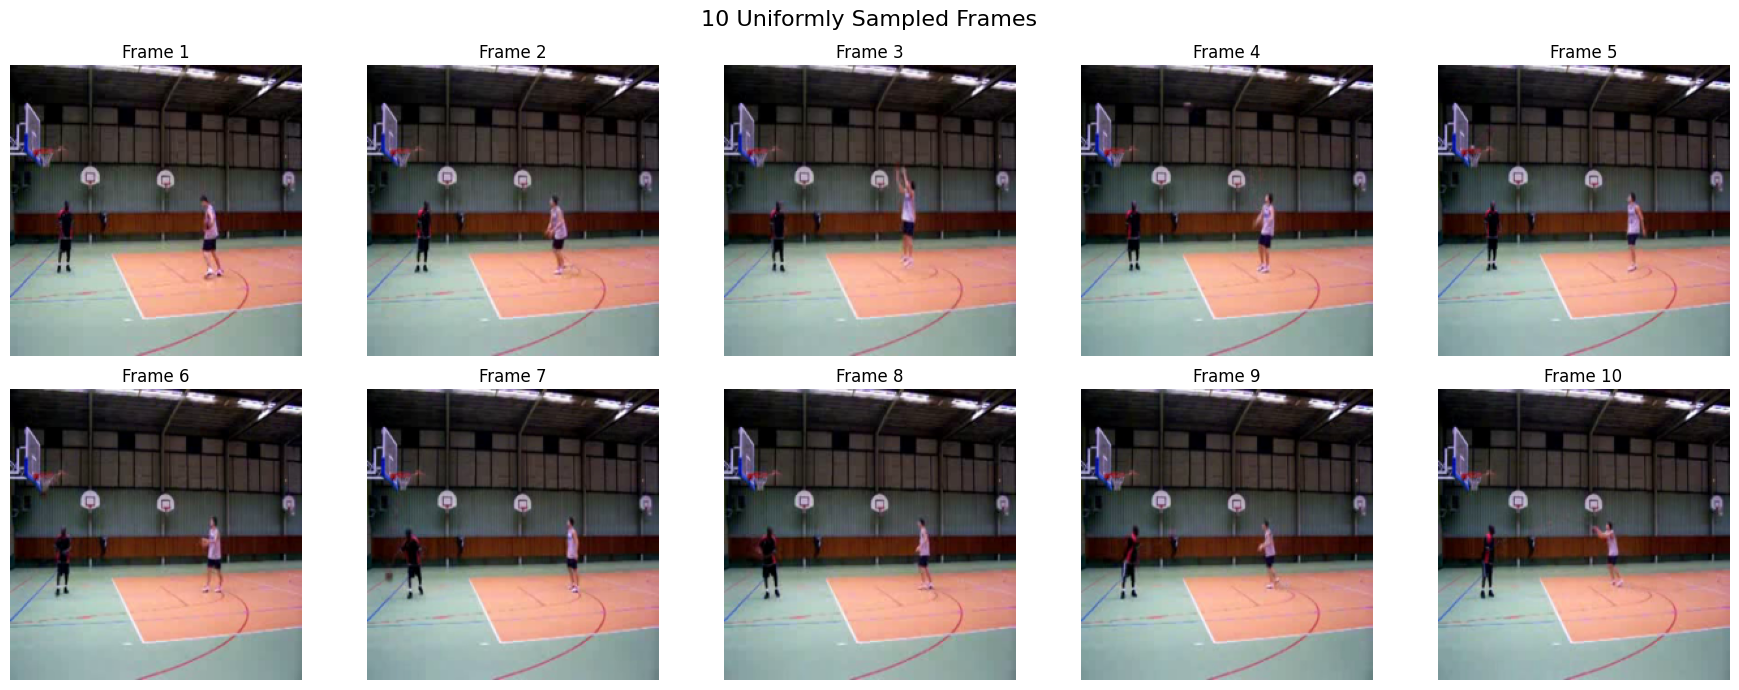


----------------------------------------------------------------------
PROCESSING TRAIN
----------------------------------------------------------------------
[1/30] Basketball v_Basketball_g01_c01.avi
[2/30] Basketball v_Basketball_g01_c02.avi
[3/30] Basketball v_Basketball_g01_c03.avi
[4/30] Basketball v_Basketball_g01_c04.avi
[5/30] Basketball v_Basketball_g01_c05.avi
[6/30] Basketball v_Basketball_g01_c06.avi
[7/30] Basketball v_Basketball_g01_c07.avi
[8/30] Basketball v_Basketball_g03_c01.avi
[9/30] Basketball v_Basketball_g03_c02.avi
[10/30] Basketball v_Basketball_g03_c03.avi
[11/30] Basketball v_Basketball_g03_c04.avi
[12/30] Basketball v_Basketball_g03_c05.avi
[13/30] Basketball v_Basketball_g03_c06.avi
[14/30] Biking v_Biking_g01_c01.avi
[15/30] Biking v_Biking_g01_c02.avi
[16/30] Biking v_Biking_g01_c03.avi
[17/30] Biking v_Biking_g01_c04.avi
[18/30] Biking v_Biking_g03_c01.avi
[19/30] Biking v_Biking_g03_c02.avi
[20/30] Biking v_Biking_g03_c03.avi
[21/30] Biking v_Biking_g

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,643 (658.76 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,723 (495.01 KB)

 Trainable params: 126,723 (495.01 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING LSTM
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.5000 - loss: 1.0164 - val_accuracy: 0.8421 - val_loss: 0.7254
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7333 - loss: 0.5810 - val_accuracy: 0.3684 - val_loss: 0.8378
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9333 - loss: 0.3854 - val_accuracy: 0.5263 - val_loss: 0.7932
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.3364 - val_accuracy: 0.7368 - val_loss: 0.6468
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9667 - loss: 0.2552 - val_accuracy: 0.8421 - val_loss: 0.4856
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9667 - loss: 0.2245 - val_accuracy: 0.8947 - val_loss: 0.4457
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.1882 - val_accuracy: 0.8947 - val_loss: 0.4836
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.1758 - val_accuracy: 0.8947 - va

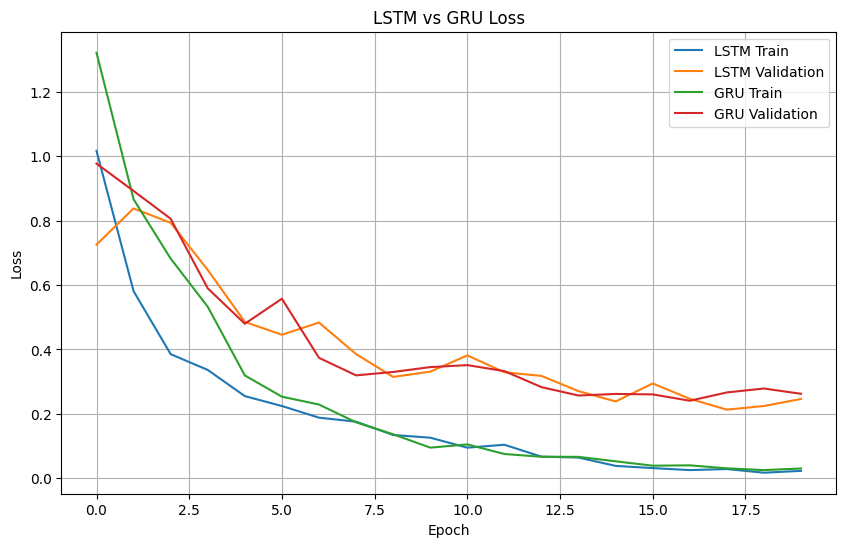

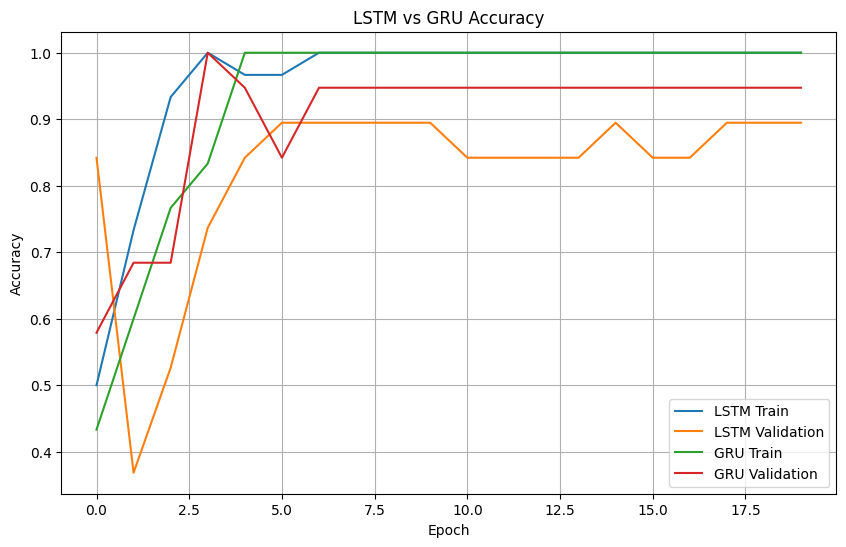


TASK 18 RESULTS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time (sec)
0,LSTM,0.545455,0.500000,0.400000,0.333333,168643,7.838854
1,GRU,0.636364,0.440476,0.466667,0.444444,126723,7.942849



LSTM CLASSIFICATION REPORT
                precision    recall  f1-score   support

    Basketball       0.00      0.00      0.00         1
        Biking       1.00      0.20      0.33         5
WalkingWithDog       0.50      1.00      0.67         5

      accuracy                           0.55        11
     macro avg       0.50      0.40      0.33        11
  weighted avg       0.68      0.55      0.45        11


GRU CLASSIFICATION REPORT
                precision    recall  f1-score   support

    Basketball       0.00      0.00      0.00         1
        Biking       0.75      0.60      0.67         5
WalkingWithDog       0.57      0.80      0.67         5

      accuracy                           0.64        11
     macro avg       0.44      0.47      0.44        11
  weighted avg       0.60      0.64      0.61        11



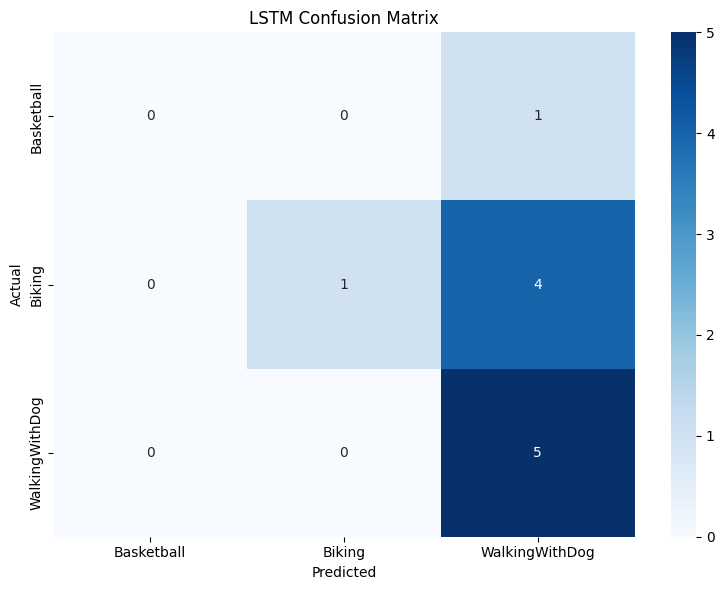

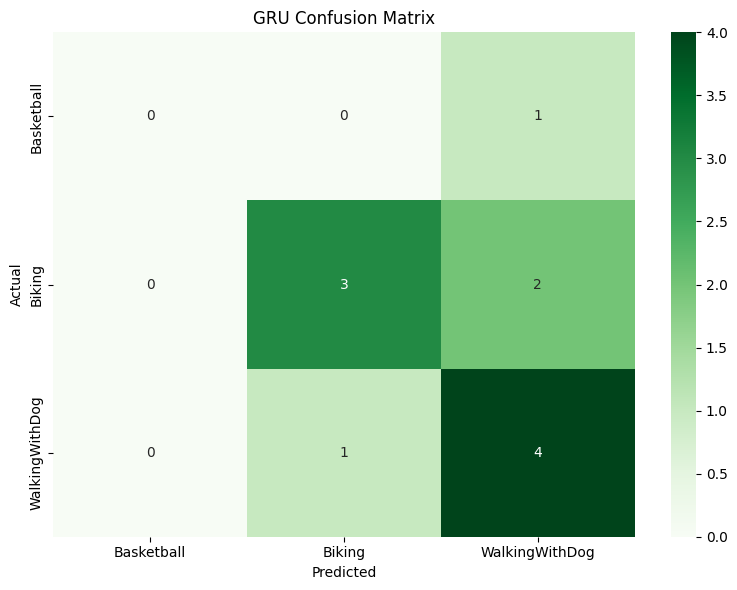

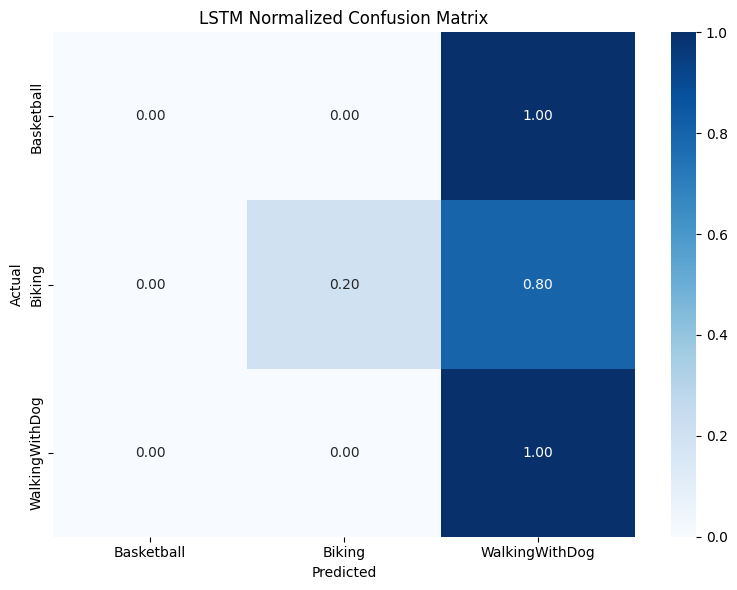

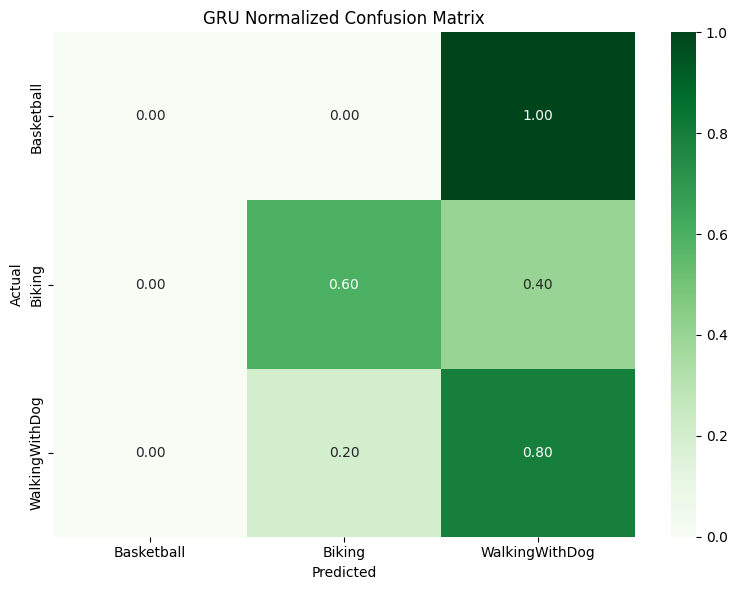


LSTM CONFUSION PAIRS


,True Class,Predicted Class,Count
1,Biking,WalkingWithDog,4
0,Basketball,WalkingWithDog,1



GRU CONFUSION PAIRS


,True Class,Predicted Class,Count
1,Biking,WalkingWithDog,2
0,Basketball,WalkingWithDog,1
2,WalkingWithDog,Biking,1


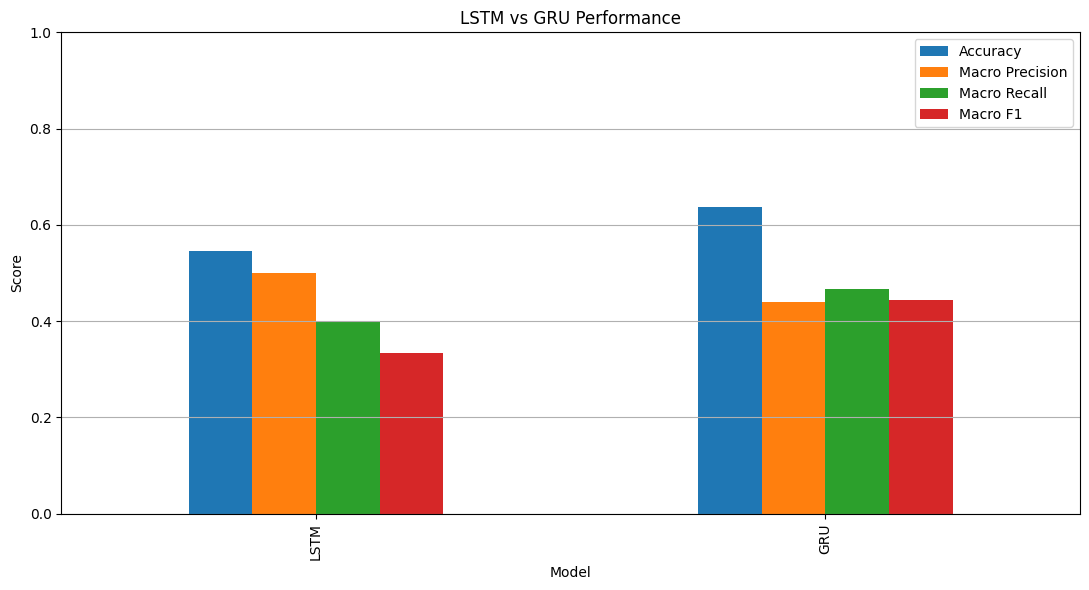

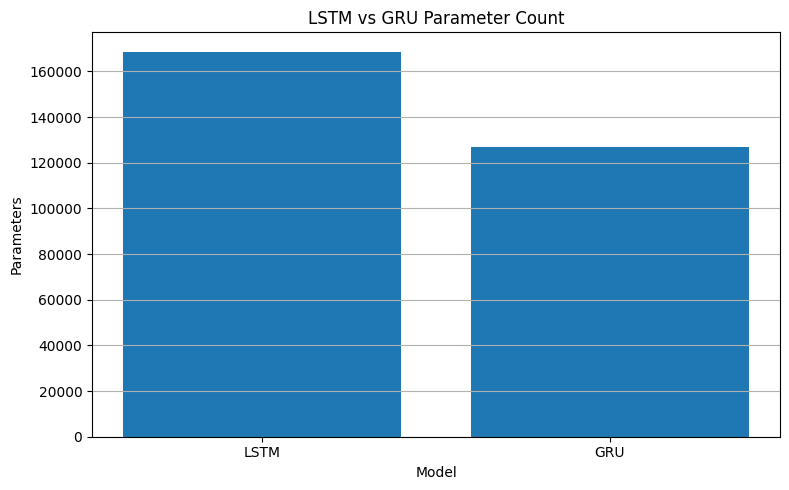

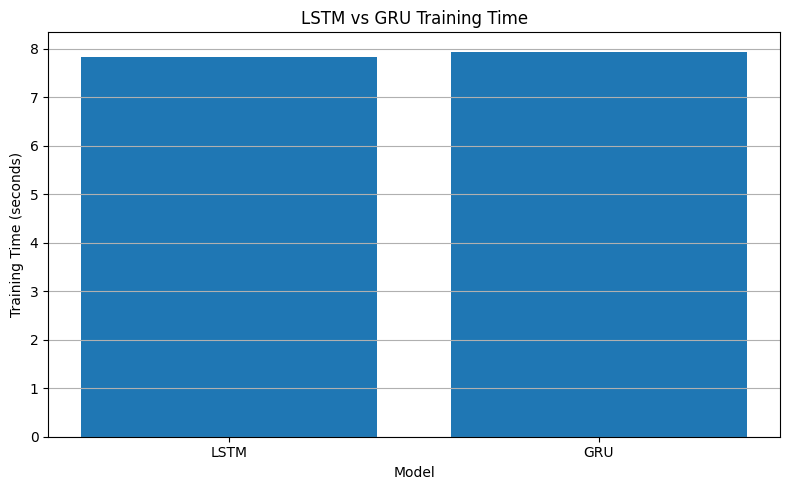


Models saved successfully.


TASK 18 COMPLETED

Dataset: UCF101
Selected classes: Basketball, Biking, WalkingWithDog
Frames/video: 10
Frame size: 224 × 224 × 3
CNN: Frozen MobileNetV2
CNN feature dimension: 1280
Feature sequence: 10 × 1280

Final comparison:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time (sec)
0,LSTM,0.545455,0.500000,0.400000,0.333333,168643,7.838854
1,GRU,0.636364,0.440476,0.466667,0.444444,126723,7.942849



Task 18 finished.


In [ ]:
# ============================================================
# CS3807 DEEP LEARNING LAB
# EXPERIMENT 6 - TASK 18
#
# CNN + LSTM / GRU FOR VIDEO UNDERSTANDING
#
# COMPLETE GOOGLE COLAB CODE
#
# UCF101 is downloaded automatically.
# No manual upload required.
# ============================================================


# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

!apt-get -qq update
!apt-get -qq install -y unrar

!pip -q install rarfile


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import re
import glob
import shutil
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)


print("=" * 75)
print("ENVIRONMENT")
print("=" * 75)

print(
    "TensorFlow:",
    tf.__version__
)

print(
    "GPUs:",
    len(
        tf.config.list_physical_devices(
            "GPU"
        )
    )
)


# ============================================================
# 3. SETTINGS
# ============================================================

UCF101_URL = (
    "https://www.crcv.ucf.edu/"
    "data/UCF101/UCF101.rar"
)

UCF101_RAR = (
    "/content/UCF101.rar"
)

EXTRACT_DIR = (
    "/content/UCF101"
)

NUM_FRAMES = 10

IMG_SIZE = 224

MAX_VIDEOS_PER_CLASS = 20

EPOCHS = 20

BATCH_SIZE = 4

RANDOM_STATE = 42


# ------------------------------------------------------------
# IMPORTANT:
#
# UCF101 officially contains 101 classes.
#
# For this laboratory experiment, we use only 3 classes
# to keep computation manageable.
# ------------------------------------------------------------

SELECTED_CLASSES = [
    "Basketball",
    "Biking",
    "WalkingWithDog"
]

NUM_CLASSES = len(
    SELECTED_CLASSES
)


print("\n" + "=" * 75)
print("TASK 18 SETTINGS")
print("=" * 75)

print(
    "Dataset: UCF101"
)

print(
    "Classes:",
    SELECTED_CLASSES
)

print(
    "Frames/video:",
    NUM_FRAMES
)

print(
    "Frame size:",
    f"{IMG_SIZE} x {IMG_SIZE}"
)

print(
    "Videos/class:",
    MAX_VIDEOS_PER_CLASS
)

print(
    "Epochs:",
    EPOCHS
)

print(
    "Batch size:",
    BATCH_SIZE
)


# ============================================================
# 4. CHECK AVAILABLE DISK SPACE
# ============================================================

print("\n" + "=" * 75)
print("CHECKING COLAB DISK SPACE")
print("=" * 75)

disk_info = shutil.disk_usage(
    "/content"
)

free_gb = (
    disk_info.free /
    (1024 ** 3)
)

total_gb = (
    disk_info.total /
    (1024 ** 3)
)


print(
    f"Total disk: {total_gb:.2f} GB"
)

print(
    f"Free disk:  {free_gb:.2f} GB"
)


if free_gb < 10:

    raise RuntimeError(
        """
Not enough free disk space.

UCF101 is approximately 6.5 GB.
Please start a fresh Colab runtime or
delete unnecessary files.
"""
    )


# ============================================================
# 5. DOWNLOAD UCF101 AUTOMATICALLY
# ============================================================

print("\n" + "=" * 75)
print("UCF101 DOWNLOAD")
print("=" * 75)


if os.path.exists(UCF101_RAR):

    existing_size_gb = (
        os.path.getsize(UCF101_RAR)
        /
        (1024 ** 3)
    )

    print(
        f"Existing UCF101.rar found:"
        f" {existing_size_gb:.2f} GB"
    )

    if existing_size_gb < 5:

        print(
            "Existing file appears incomplete."
        )

        os.remove(
            UCF101_RAR
        )


# ------------------------------------------------------------
# Download
# ------------------------------------------------------------

if not os.path.exists(
    UCF101_RAR
):

    print(
        "\nDownloading UCF101..."
    )

    print(
        "Official URL:"
    )

    print(
        UCF101_URL
    )

    print(
        "\nThe dataset is approximately 6.5 GB."
    )

    print(
        "Please allow the download to finish."
    )


    command = (
        f'wget '
        f'--no-check-certificate '
        f'--continue '
        f'--show-progress '
        f'"{UCF101_URL}" '
        f'-O "{UCF101_RAR}"'
    )


    result = os.system(
        command
    )


    if result != 0:

        raise RuntimeError(
            """
UCF101 download failed.

The UCF server may be temporarily unavailable,
or the Colab network may have interrupted the
download.

Run this cell again. wget --continue will resume
an incomplete download instead of starting from zero.
"""
        )


# ------------------------------------------------------------
# Verify download size
# ------------------------------------------------------------

rar_size_gb = (
    os.path.getsize(
        UCF101_RAR
    )
    /
    (1024 ** 3)
)


print(
    "\nDownloaded file size:",
    f"{rar_size_gb:.2f} GB"
)


if rar_size_gb < 5:

    raise RuntimeError(
        f"""
Downloaded UCF101 archive is only
{rar_size_gb:.2f} GB.

The download is incomplete.

Run this cell again to resume the download.
"""
    )


print(
    "\nUCF101 download completed."
)


# ============================================================
# 6. EXTRACT ONLY WHAT WE NEED
# ============================================================

print("\n" + "=" * 75)
print("EXTRACTING UCF101")
print("=" * 75)


if not os.path.exists(
    EXTRACT_DIR
):

    os.makedirs(
        EXTRACT_DIR
    )


# ------------------------------------------------------------
# Check whether classes already exist
# ------------------------------------------------------------

already_extracted = all(
    os.path.exists(
        os.path.join(
            EXTRACT_DIR,
            class_name
        )
    )
    for class_name
    in SELECTED_CLASSES
)


if already_extracted:

    print(
        "Required classes are already extracted."
    )

else:

    print(
        """
Extracting UCF101.

This may take several minutes.
"""
    )


    # --------------------------------------------------------
    # Extract archive
    # --------------------------------------------------------

    !unrar x -idq "/content/UCF101.rar" "/content/UCF101/"


    print(
        "\nExtraction completed."
    )


# ============================================================
# 7. FIND THE ACTUAL UCF101 DIRECTORY
# ============================================================

print("\n" + "=" * 75)
print("LOCATING UCF101 CLASS FOLDERS")
print("=" * 75)


def find_class_folders(
    root_dir
):

    locations = {}


    for class_name in SELECTED_CLASSES:

        for root, dirs, files in os.walk(
            root_dir
        ):

            if class_name in dirs:

                candidate = os.path.join(
                    root,
                    class_name
                )


                videos = []

                videos += glob.glob(
                    os.path.join(
                        candidate,
                        "*.avi"
                    )
                )

                videos += glob.glob(
                    os.path.join(
                        candidate,
                        "*.mp4"
                    )
                )


                if len(videos) > 0:

                    locations[
                        class_name
                    ] = candidate

                    break


    return locations


class_locations = find_class_folders(
    EXTRACT_DIR
)


for class_name in SELECTED_CLASSES:

    if class_name in class_locations:

        print(
            f"{class_name:<20} -> "
            f"{class_locations[class_name]}"
        )

    else:

        print(
            f"{class_name:<20} -> NOT FOUND"
        )


# ============================================================
# 8. VERIFY DATASET
# ============================================================

missing = [
    c
    for c in SELECTED_CLASSES
    if c not in class_locations
]


if len(missing) > 0:

    raise FileNotFoundError(
        f"""
The following UCF101 classes were not found:

{missing}

The archive may not have extracted correctly.
"""
    )


print(
    "\nAll required classes found."
)


# ============================================================
# 9. COLLECT VIDEO FILES
# ============================================================

records = []


for class_id, class_name in enumerate(
    SELECTED_CLASSES
):

    class_dir = class_locations[
        class_name
    ]


    videos = []

    videos += glob.glob(
        os.path.join(
            class_dir,
            "*.avi"
        )
    )

    videos += glob.glob(
        os.path.join(
            class_dir,
            "*.mp4"
        )
    )


    videos = sorted(
        videos
    )


    # --------------------------------------------------------
    # Keep a small subset
    # --------------------------------------------------------

    videos = videos[
        :MAX_VIDEOS_PER_CLASS
    ]


    for video_path in videos:

        filename = os.path.basename(
            video_path
        )


        # ----------------------------------------------------
        # Example:
        #
        # v_Basketball_g01_c01.avi
        #
        # group = 01
        # ----------------------------------------------------

        match = re.search(
            r"_g(\d+)_",
            filename
        )


        if match:

            group_id = match.group(
                1
            )

        else:

            group_id = filename


        records.append({

            "path":
                video_path,

            "class_name":
                class_name,

            "class_id":
                class_id,

            "group_id":
                group_id

        })


video_df = pd.DataFrame(
    records
)


print("\n" + "=" * 75)
print("VIDEO DATASET")
print("=" * 75)


print(
    "Total videos:",
    len(video_df)
)


print(
    "\nVideos per class:"
)


print(
    video_df[
        "class_name"
    ].value_counts()
)


# ============================================================
# 10. GROUP-SAFE TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("\n" + "=" * 75)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 75)


# ------------------------------------------------------------
# UCF101 groups must not be mixed between train and test.
#
# Approximate:
#
# Train      = 70%
# Validation = 15%
# Test       = 15%
# ------------------------------------------------------------


from sklearn.model_selection import (
    GroupShuffleSplit
)


splitter1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=RANDOM_STATE
)


train_idx, temp_idx = next(
    splitter1.split(
        video_df,
        groups=video_df[
            "group_id"
        ]
    )
)


train_df = video_df.iloc[
    train_idx
].reset_index(
    drop=True
)


temp_df = video_df.iloc[
    temp_idx
].reset_index(
    drop=True
)


splitter2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=RANDOM_STATE
)


val_idx, test_idx = next(
    splitter2.split(
        temp_df,
        groups=temp_df[
            "group_id"
        ]
    )
)


val_df = temp_df.iloc[
    val_idx
].reset_index(
    drop=True
)


test_df = temp_df.iloc[
    test_idx
].reset_index(
    drop=True
)


print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)


# ============================================================
# 11. GROUP LEAKAGE CHECK
# ============================================================

train_groups = set(
    train_df["group_id"]
)

val_groups = set(
    val_df["group_id"]
)

test_groups = set(
    test_df["group_id"]
)


print("\n" + "=" * 75)
print("GROUP LEAKAGE CHECK")
print("=" * 75)


print(
    "Train ∩ Validation:",
    train_groups.intersection(
        val_groups
    )
)

print(
    "Train ∩ Test:",
    train_groups.intersection(
        test_groups
    )
)

print(
    "Validation ∩ Test:",
    val_groups.intersection(
        test_groups
    )
)


# ============================================================
# 12. FRAME EXTRACTION
# ============================================================

def sample_uniform_frames(
    video_path,
    num_frames=10
):

    cap = cv2.VideoCapture(
        video_path
    )


    if not cap.isOpened():

        raise RuntimeError(
            f"Could not open:\n{video_path}"
        )


    total_frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )


    if total_frames <= 0:

        cap.release()

        raise RuntimeError(
            f"No frames found:\n{video_path}"
        )


    # --------------------------------------------------------
    # Uniformly sample 10 frames
    # --------------------------------------------------------

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=int
    )


    frames = []


    for idx in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(idx)
        )


        success, frame = cap.read()


        if not success:

            cap.release()

            raise RuntimeError(
                f"Could not read frame "
                f"{idx} from {video_path}"
            )


        # BGR -> RGB
        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )


        # 224 × 224
        frame = cv2.resize(
            frame,
            (
                IMG_SIZE,
                IMG_SIZE
            )
        )


        frames.append(
            frame
        )


    cap.release()


    return np.array(
        frames,
        dtype=np.float32
    )


# ============================================================
# 13. LOAD FROZEN MOBILENETV2
# ============================================================

print("\n" + "=" * 75)
print("LOADING MOBILENETV2")
print("=" * 75)


cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(
        224,
        224,
        3
    )
)


# Freeze CNN
cnn.trainable = False


FEATURE_DIM = cnn.output_shape[
    -1
]


print(
    "MobileNetV2 loaded."
)

print(
    "Frozen:",
    not cnn.trainable
)

print(
    "Feature dimension:",
    FEATURE_DIM
)


# Expected:
#
# 1280


# ============================================================
# 14. EXTRACT FEATURES FROM VIDEO
# ============================================================

def extract_video_features(
    video_path
):

    # --------------------------------------------------------
    # 10 frames
    # --------------------------------------------------------

    frames = sample_uniform_frames(
        video_path,
        NUM_FRAMES
    )


    # --------------------------------------------------------
    # MobileNetV2 preprocessing
    # --------------------------------------------------------

    frames = preprocess_input(
        frames
    )


    # --------------------------------------------------------
    # CNN
    # --------------------------------------------------------

    features = cnn.predict(
        frames,
        batch_size=NUM_FRAMES,
        verbose=0
    )


    return features.astype(
        np.float32
    )


# ============================================================
# 15. TEST ONE VIDEO
# ============================================================

print("\n" + "=" * 75)
print("TESTING FRAME EXTRACTION")
print("=" * 75)


sample_video = train_df.iloc[
    0
]["path"]


print(
    "Sample:",
    sample_video
)


frames = sample_uniform_frames(
    sample_video,
    NUM_FRAMES
)


print(
    "Frame tensor:",
    frames.shape
)


features = extract_video_features(
    sample_video
)


print(
    "CNN feature sequence:",
    features.shape
)


# Expected:
#
# Frames:
# (10, 224, 224, 3)
#
# Features:
# (10, 1280)


# ============================================================
# 16. DISPLAY 10 FRAMES
# ============================================================

plt.figure(
    figsize=(18, 7)
)


for i in range(
    NUM_FRAMES
):

    plt.subplot(
        2,
        5,
        i + 1
    )


    plt.imshow(
        frames[i].astype(
            np.uint8
        )
    )


    plt.title(
        f"Frame {i + 1}"
    )


    plt.axis(
        "off"
    )


plt.suptitle(
    "10 Uniformly Sampled Frames",
    fontsize=16
)


plt.tight_layout()

plt.show()


# ============================================================
# 17. PROCESS DATAFRAME
# ============================================================

def process_dataframe(
    df,
    split_name
):

    X = []
    y = []


    print("\n" + "-" * 70)

    print(
        f"PROCESSING {split_name}"
    )

    print("-" * 70)


    for i, row in df.iterrows():

        video_path = row[
            "path"
        ]


        print(
            f"[{i + 1}/{len(df)}] "
            f"{row['class_name']} "
            f"{os.path.basename(video_path)}"
        )


        try:

            video_features = (
                extract_video_features(
                    video_path
                )
            )


            X.append(
                video_features
            )


            y.append(
                row["class_id"]
            )


        except Exception as e:

            print(
                "\nWARNING:"
            )

            print(
                video_path
            )

            print(
                e
            )


    X = np.array(
        X,
        dtype=np.float32
    )


    y = np.array(
        y,
        dtype=np.int32
    )


    print(
        f"\n{split_name} X:",
        X.shape
    )

    print(
        f"{split_name} y:",
        y.shape
    )


    return X, y


# ============================================================
# 18. EXTRACT TRAIN FEATURES
# ============================================================

X_train, y_train = process_dataframe(
    train_df,
    "TRAIN"
)


# ============================================================
# 19. EXTRACT VALIDATION FEATURES
# ============================================================

X_val, y_val = process_dataframe(
    val_df,
    "VALIDATION"
)


# ============================================================
# 20. EXTRACT TEST FEATURES
# ============================================================

X_test, y_test = process_dataframe(
    test_df,
    "TEST"
)


# ============================================================
# 21. FINAL FEATURE SHAPES
# ============================================================

print("\n" + "=" * 75)
print("FEATURE SHAPES")
print("=" * 75)


print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "y_val:",
    y_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)


# Expected:
#
# X_train: (?, 10, 1280)
# X_val:   (?, 10, 1280)
# X_test:  (?, 10, 1280)


# ============================================================
# 22. CREATE LSTM / GRU MODELS
# ============================================================

def create_model(
    model_type
):

    model = Sequential()


    if model_type == "LSTM":

        model.add(
            LSTM(
                32,
                input_shape=(
                    NUM_FRAMES,
                    FEATURE_DIM
                )
            )
        )


    elif model_type == "GRU":

        model.add(
            GRU(
                32,
                input_shape=(
                    NUM_FRAMES,
                    FEATURE_DIM
                )
            )
        )


    model.add(
        Dropout(
            0.2
        )
    )


    model.add(
        Dense(
            16,
            activation="relu"
        )
    )


    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )


    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss=(
            "sparse_categorical_crossentropy"
        ),

        metrics=[
            "accuracy"
        ]
    )


    return model


# ============================================================
# 23. CREATE LSTM
# ============================================================

lstm_model = create_model(
    "LSTM"
)


print("\n" + "=" * 75)
print("LSTM MODEL")
print("=" * 75)


lstm_model.summary()


# ============================================================
# 24. CREATE GRU
# ============================================================

gru_model = create_model(
    "GRU"
)


print("\n" + "=" * 75)
print("GRU MODEL")
print("=" * 75)


gru_model.summary()


# ============================================================
# 25. TRAIN LSTM
# ============================================================

print("\n" + "=" * 75)
print("TRAINING LSTM")
print("=" * 75)


start = time.time()


lstm_history = lstm_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)


lstm_time = (
    time.time()
    -
    start
)


print(
    "\nLSTM training time:",
    round(
        lstm_time,
        2
    ),
    "seconds"
)


# ============================================================
# 26. TRAIN GRU
# ============================================================

print("\n" + "=" * 75)
print("TRAINING GRU")
print("=" * 75)


start = time.time()


gru_history = gru_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)


gru_time = (
    time.time()
    -
    start
)


print(
    "\nGRU training time:",
    round(
        gru_time,
        2
    ),
    "seconds"
)


# ============================================================
# 27. LOSS CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    lstm_history.history[
        "loss"
    ],
    label="LSTM Train"
)


plt.plot(
    lstm_history.history[
        "val_loss"
    ],
    label="LSTM Validation"
)


plt.plot(
    gru_history.history[
        "loss"
    ],
    label="GRU Train"
)


plt.plot(
    gru_history.history[
        "val_loss"
    ],
    label="GRU Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "LSTM vs GRU Loss"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 28. ACCURACY CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    lstm_history.history[
        "accuracy"
    ],
    label="LSTM Train"
)


plt.plot(
    lstm_history.history[
        "val_accuracy"
    ],
    label="LSTM Validation"
)


plt.plot(
    gru_history.history[
        "accuracy"
    ],
    label="GRU Train"
)


plt.plot(
    gru_history.history[
        "val_accuracy"
    ],
    label="GRU Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "LSTM vs GRU Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# 29. PREDICTIONS
# ============================================================

lstm_probs = lstm_model.predict(
    X_test,
    verbose=0
)


gru_probs = gru_model.predict(
    X_test,
    verbose=0
)


lstm_pred = np.argmax(
    lstm_probs,
    axis=1
)


gru_pred = np.argmax(
    gru_probs,
    axis=1
)


# ============================================================
# 30. METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    model_name
):

    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Macro Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }


lstm_metrics = calculate_metrics(
    y_test,
    lstm_pred,
    "LSTM"
)


gru_metrics = calculate_metrics(
    y_test,
    gru_pred,
    "GRU"
)


# ============================================================
# 31. RESULTS TABLE
# ============================================================

results = pd.DataFrame([

    {
        **lstm_metrics,

        "Parameters":
            lstm_model.count_params(),

        "Training Time (sec)":
            lstm_time
    },

    {
        **gru_metrics,

        "Parameters":
            gru_model.count_params(),

        "Training Time (sec)":
            gru_time
    }

])


print("\n" + "=" * 75)
print("TASK 18 RESULTS")
print("=" * 75)


display(
    results
)


# ============================================================
# 32. CLASSIFICATION REPORT — LSTM
# ============================================================

print("\n" + "=" * 75)
print("LSTM CLASSIFICATION REPORT")
print("=" * 75)


print(
    classification_report(
        y_test,
        lstm_pred,
        labels=range(NUM_CLASSES),
        target_names=SELECTED_CLASSES,
        zero_division=0
    )
)


# ============================================================
# 33. CLASSIFICATION REPORT — GRU
# ============================================================

print("\n" + "=" * 75)
print("GRU CLASSIFICATION REPORT")
print("=" * 75)


print(
    classification_report(
        y_test,
        gru_pred,
        labels=range(NUM_CLASSES),
        target_names=SELECTED_CLASSES,
        zero_division=0
    )
)


# ============================================================
# 34. LSTM CONFUSION MATRIX
# ============================================================

lstm_cm = confusion_matrix(
    y_test,
    lstm_pred,
    labels=range(NUM_CLASSES)
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "LSTM Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 35. GRU CONFUSION MATRIX
# ============================================================

gru_cm = confusion_matrix(
    y_test,
    gru_pred,
    labels=range(NUM_CLASSES)
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    gru_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "GRU Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 36. NORMALIZED CONFUSION MATRICES
# ============================================================

lstm_cm_norm = (
    lstm_cm /
    np.maximum(
        lstm_cm.sum(
            axis=1,
            keepdims=True
        ),
        1
    )
)


gru_cm_norm = (
    gru_cm /
    np.maximum(
        gru_cm.sum(
            axis=1,
            keepdims=True
        ),
        1
    )
)


# ------------------------------------------------------------
# LSTM
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    lstm_cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "LSTM Normalized Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# GRU
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    gru_cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "GRU Normalized Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 37. CONFUSION PAIRS
# ============================================================

def get_confusion_pairs(
    cm,
    class_names
):

    pairs = []


    for i in range(
        len(class_names)
    ):

        for j in range(
            len(class_names)
        ):

            if i != j:

                if cm[i, j] > 0:

                    pairs.append({

                        "True Class":
                            class_names[i],

                        "Predicted Class":
                            class_names[j],

                        "Count":
                            int(cm[i, j])
                    })


    if len(pairs) == 0:

        return pd.DataFrame()


    return pd.DataFrame(
        pairs
    ).sort_values(
        "Count",
        ascending=False
    )


print("\n" + "=" * 75)
print("LSTM CONFUSION PAIRS")
print("=" * 75)


display(
    get_confusion_pairs(
        lstm_cm,
        SELECTED_CLASSES
    )
)


print("\n" + "=" * 75)
print("GRU CONFUSION PAIRS")
print("=" * 75)


display(
    get_confusion_pairs(
        gru_cm,
        SELECTED_CLASSES
    )
)


# ============================================================
# 38. PERFORMANCE COMPARISON
# ============================================================

plot_results = results[
    [
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
].set_index(
    "Model"
)


plot_results.plot(
    kind="bar",
    figsize=(11, 6)
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.title(
    "LSTM vs GRU Performance"
)

plt.ylim(
    0,
    1
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()


# ============================================================
# 39. PARAMETER COMPARISON
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    results["Model"],
    results["Parameters"]
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Parameters"
)

plt.title(
    "LSTM vs GRU Parameter Count"
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()


# ============================================================
# 40. TRAINING TIME COMPARISON
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    results["Model"],
    results[
        "Training Time (sec)"
    ]
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "LSTM vs GRU Training Time"
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()


# ============================================================
# 41. SAVE MODELS
# ============================================================

lstm_model.save(
    "/content/lstm_ucf101.keras"
)


gru_model.save(
    "/content/gru_ucf101.keras"
)


print(
    "\nModels saved successfully."
)


# ============================================================
# 42. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("TASK 18 COMPLETED")
print("=" * 80)


print(
    "\nDataset: UCF101"
)

print(
    "Selected classes:",
    ", ".join(
        SELECTED_CLASSES
    )
)

print(
    "Frames/video:",
    NUM_FRAMES
)

print(
    "Frame size:",
    "224 × 224 × 3"
)

print(
    "CNN:",
    "Frozen MobileNetV2"
)

print(
    "CNN feature dimension:",
    FEATURE_DIM
)

print(
    "Feature sequence:",
    f"{NUM_FRAMES} × {FEATURE_DIM}"
)

print(
    "\nFinal comparison:"
)

display(
    results
)


print(
    "\nTask 18 finished."
)

In [ ]:
# ============================================================
# TASK 19 — EXPECTED VIDEO INPUT AND OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("TASK 19 — EXPECTED VIDEO INPUT AND OUTPUT")
print("=" * 80)


# ============================================================
# 1. SHOW EXPECTED INPUT SHAPES
# ============================================================

print("\nINPUT SPECIFICATION")
print("-" * 60)

print(
    "Frames sampled per video:",
    NUM_FRAMES
)

print(
    "Frame size:",
    f"{IMG_SIZE} × {IMG_SIZE} × 3"
)

print(
    "CNN:",
    "MobileNetV2"
)

print(
    "CNN feature dimension D:",
    FEATURE_DIM
)

print(
    "One video input to recurrent network:",
    f"(10, {FEATURE_DIM})"
)

print(
    "Batch input:",
    f"(B, 10, {FEATURE_DIM})"
)


# ============================================================
# 2. VERIFY ACTUAL INPUT SHAPE
# ============================================================

print("\nACTUAL INPUT SHAPES")
print("-" * 60)

print(
    "X_train shape:",
    X_train.shape
)

print(
    "X_val shape:",
    X_val.shape
)

print(
    "X_test shape:",
    X_test.shape
)


# ============================================================
# 3. SELECT ONE TEST VIDEO
# ============================================================

sample_index = 0

sample_video_path = test_df.iloc[
    sample_index
]["path"]

actual_class_id = y_test[
    sample_index
]

actual_class = SELECTED_CLASSES[
    actual_class_id
]


print("\nTEST VIDEO")
print("-" * 60)

print(
    "Video:",
    os.path.basename(
        sample_video_path
    )
)

print(
    "Actual class:",
    actual_class
)


# ============================================================
# 4. GET THE FEATURE SEQUENCE
# ============================================================

sample_feature_sequence = X_test[
    sample_index
]


print("\nFEATURE SEQUENCE")
print("-" * 60)

print(
    "Feature sequence shape:",
    sample_feature_sequence.shape
)


# Expected:
#
# (10, 1280)


# ============================================================
# 5. ADD BATCH DIMENSION
# ============================================================

sample_input = np.expand_dims(
    sample_feature_sequence,
    axis=0
)


print(
    "Input shape given to recurrent model:",
    sample_input.shape
)


# Expected:
#
# (1, 10, 1280)


# ============================================================
# 6. LSTM PREDICTION
# ============================================================

lstm_probability_vector = (
    lstm_model.predict(
        sample_input,
        verbose=0
    )[0]
)


lstm_predicted_id = np.argmax(
    lstm_probability_vector
)


lstm_predicted_class = (
    SELECTED_CLASSES[
        lstm_predicted_id
    ]
)


lstm_confidence = (
    float(
        lstm_probability_vector[
            lstm_predicted_id
        ]
    )
)


# ============================================================
# 7. GRU PREDICTION
# ============================================================

gru_probability_vector = (
    gru_model.predict(
        sample_input,
        verbose=0
    )[0]
)


gru_predicted_id = np.argmax(
    gru_probability_vector
)


gru_predicted_class = (
    SELECTED_CLASSES[
        gru_predicted_id
    ]
)


gru_confidence = (
    float(
        gru_probability_vector[
            gru_predicted_id
        ]
    )
)


# ============================================================
# 8. DISPLAY LSTM OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("LSTM OUTPUT")
print("=" * 80)

print(
    "Predicted class :",
    lstm_predicted_class
)

print(
    "Actual class    :",
    actual_class
)

print(
    "Confidence      :",
    f"{lstm_confidence:.4f}"
)

print(
    "Confidence (%)  :",
    f"{lstm_confidence * 100:.2f}%"
)


# ============================================================
# 9. DISPLAY GRU OUTPUT
# ============================================================

print("\n" + "=" * 80)
print("GRU OUTPUT")
print("=" * 80)

print(
    "Predicted class :",
    gru_predicted_class
)

print(
    "Actual class    :",
    actual_class
)

print(
    "Confidence      :",
    f"{gru_confidence:.4f}"
)

print(
    "Confidence (%)  :",
    f"{gru_confidence * 100:.2f}%"
)


# ============================================================
# 10. DISPLAY COMPLETE LSTM PROBABILITY VECTOR
# ============================================================

print("\n" + "=" * 80)
print("LSTM PROBABILITY VECTOR")
print("=" * 80)

for class_name, probability in zip(
    SELECTED_CLASSES,
    lstm_probability_vector
):

    print(
        f"{class_name:<20}: "
        f"{probability:.4f}"
    )


print(
    "\nSum of LSTM probabilities:",
    f"{lstm_probability_vector.sum():.4f}"
)


# ============================================================
# 11. DISPLAY COMPLETE GRU PROBABILITY VECTOR
# ============================================================

print("\n" + "=" * 80)
print("GRU PROBABILITY VECTOR")
print("=" * 80)

for class_name, probability in zip(
    SELECTED_CLASSES,
    gru_probability_vector
):

    print(
        f"{class_name:<20}: "
        f"{probability:.4f}"
    )


print(
    "\nSum of GRU probabilities:",
    f"{gru_probability_vector.sum():.4f}"
)


# ============================================================
# 12. CREATE TASK 19 OUTPUT TABLE
# ============================================================

task19_output = pd.DataFrame({

    "Model": [
        "LSTM",
        "GRU"
    ],

    "Predicted Class": [
        lstm_predicted_class,
        gru_predicted_class
    ],

    "Actual Class": [
        actual_class,
        actual_class
    ],

    "Confidence": [
        lstm_confidence,
        gru_confidence
    ],

    "Confidence (%)": [
        lstm_confidence * 100,
        gru_confidence * 100
    ]
})


print("\n" + "=" * 80)
print("TASK 19 FINAL OUTPUT")
print("=" * 80)

display(
    task19_output
)


# ============================================================
# 13. VERIFY CONFIDENCE IS MODEL GENERATED
# ============================================================

print("\n" + "=" * 80)
print("CONFIDENCE VERIFICATION")
print("=" * 80)

print(
    "LSTM probability vector:",
    lstm_probability_vector
)

print(
    "\nLSTM confidence is the maximum probability:",
    f"{lstm_confidence:.4f}"
)

print(
    "\nGRU probability vector:",
    gru_probability_vector
)

print(
    "\nGRU confidence is the maximum probability:",
    f"{gru_confidence:.4f}"
)


# ============================================================
# 14. FINAL TASK 19 SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("TASK 19 SUMMARY")
print("=" * 80)

print(
    "\nOne video:"
)

print(
    f"10 frames → 10 × 224 × 224 × 3"
)

print(
    f"MobileNetV2 → 10 × {FEATURE_DIM}"
)

print(
    f"Recurrent input → (10, {FEATURE_DIM})"
)

print(
    "\nBatch of B videos:"
)

print(
    f"(B, 10, {FEATURE_DIM})"
)

print(
    "\nExpected output:"
)

print(
    f"Probability vector of length {NUM_CLASSES}"
)

print(
    "\nLSTM:"
)

print(
    f"Predicted class = {lstm_predicted_class}"
)

print(
    f"Actual class    = {actual_class}"
)

print(
    f"Confidence      = {lstm_confidence:.4f}"
)

print(
    "\nGRU:"
)

print(
    f"Predicted class = {gru_predicted_class}"
)

print(
    f"Actual class    = {actual_class}"
)

print(
    f"Confidence      = {gru_confidence:.4f}"
)


TASK 19 — EXPECTED VIDEO INPUT AND OUTPUT

INPUT SPECIFICATION
------------------------------------------------------------
Frames sampled per video: 10
Frame size: 224 × 224 × 3
CNN: MobileNetV2
CNN feature dimension D: 1280
One video input to recurrent network: (10, 1280)
Batch input: (B, 10, 1280)

ACTUAL INPUT SHAPES
------------------------------------------------------------
X_train shape: (30, 10, 1280)
X_val shape: (19, 10, 1280)
X_test shape: (11, 10, 1280)

TEST VIDEO
------------------------------------------------------------
Video: v_Basketball_g04_c01.avi
Actual class: Basketball

FEATURE SEQUENCE
------------------------------------------------------------
Feature sequence shape: (10, 1280)
Input shape given to recurrent model: (1, 10, 1280)



LSTM OUTPUT
Predicted class : WalkingWithDog
Actual class    : Basketball
Confidence      : 0.9509
Confidence (%)  : 95.09%

GRU OUTPUT
Predicted class : WalkingWithDog
Actual class    : Basketball
Confidence      : 0.9031
Confidence (%)  : 90.31%

LSTM PROBABILITY VECTOR
Basketball          : 0.0345
Biking              : 0.0146
WalkingWithDog      : 0.9509

Sum of LSTM probabilities: 1.0000

GRU PROBABILITY VECTOR
Basketball          : 0.0839
Biking              : 0.0130
WalkingWithDog      : 0.9031

Sum of GRU probabilities: 1.0000

TASK 19 FINAL OUTPUT


,Model,Predicted Class,Actual Class,Confidence,Confidence (%)
0,LSTM,WalkingWithDog,Basketball,0.950941,95.094109
1,GRU,WalkingWithDog,Basketball,0.903127,90.312678



CONFIDENCE VERIFICATION
LSTM probability vector: [0.03449979 0.01455906 0.9509411 ]

LSTM confidence is the maximum probability: 0.9509

GRU probability vector: [0.08385136 0.01302194 0.9031268 ]

GRU confidence is the maximum probability: 0.9031

TASK 19 SUMMARY

One video:
10 frames → 10 × 224 × 224 × 3
MobileNetV2 → 10 × 1280
Recurrent input → (10, 1280)

Batch of B videos:
(B, 10, 1280)

Expected output:
Probability vector of length 3

LSTM:
Predicted class = WalkingWithDog
Actual class    = Basketball
Confidence      = 0.9509

GRU:
Predicted class = WalkingWithDog
Actual class    = Basketball
Confidence      = 0.9031


In [ ]:
# ============================================================
# TASK 20 — CNN FEATURE EXTRACTION
# ============================================================
#
# Requirement:
#
# Frame (224 × 224 × 3)
#          ↓
#      MobileNetV2
#          ↓
# Global Average Pooling
#          ↓
#    Feature Vector
#          ↓
# Sequence of Features
#
# CNN is pretrained and FROZEN.
# CNN is NOT trained from scratch.
# ============================================================


import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# ============================================================
# 1. SETTINGS
# ============================================================

IMG_SIZE = 224

NUM_FRAMES = 10


print("=" * 80)
print("TASK 20 — CNN FEATURE EXTRACTION")
print("=" * 80)


# ============================================================
# 2. LOAD PRETRAINED MOBILENETV2
# ============================================================

print("\nLoading pretrained MobileNetV2...")


cnn = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)


# ============================================================
# 3. FREEZE CNN
# ============================================================

cnn.trainable = False


print("\nCNN configuration")
print("-" * 60)

print(
    "Model:",
    "MobileNetV2"
)

print(
    "Pretrained weights:",
    "ImageNet"
)

print(
    "Classification head:",
    "Removed"
)

print(
    "CNN trainable:",
    cnn.trainable
)

print(
    "Global Average Pooling:",
    "Enabled"
)


# ============================================================
# 4. CNN FEATURE DIMENSION
# ============================================================

feature_dimension = cnn.output_shape[-1]


print("\n" + "=" * 80)
print("CNN FEATURE DIMENSION")
print("=" * 80)


print(
    "Feature dimension D =",
    feature_dimension
)


# For MobileNetV2 with:
#
# include_top=False
# pooling="avg"
#
# D = 1280


# ============================================================
# 5. CREATE A SAMPLE FRAME
# ============================================================
#
# Normally this comes from the UCF101 video.
# We create the shape here to verify the CNN pipeline.
# ============================================================

sample_frame = np.random.rand(
    IMG_SIZE,
    IMG_SIZE,
    3
).astype(
    np.float32
)


print("\nSample frame shape:")

print(
    sample_frame.shape
)


# ============================================================
# 6. PREPROCESS SAMPLE FRAME
# ============================================================

sample_frame_batch = np.expand_dims(
    sample_frame,
    axis=0
)


sample_frame_batch = preprocess_input(
    sample_frame_batch
)


print(
    "\nInput batch shape:",
    sample_frame_batch.shape
)


# Expected:
#
# (1, 224, 224, 3)


# ============================================================
# 7. EXTRACT FEATURE FROM ONE FRAME
# ============================================================

single_frame_feature = cnn.predict(
    sample_frame_batch,
    verbose=0
)


print("\n" + "=" * 80)
print("SINGLE FRAME FEATURE")
print("=" * 80)


print(
    "Input:",
    sample_frame_batch.shape
)

print(
    "Output:",
    single_frame_feature.shape
)


# Expected:
#
# Input:
# (1, 224, 224, 3)
#
# Output:
# (1, 1280)


# ============================================================
# 8. VERIFY FEATURE VECTOR
# ============================================================

feature_vector = single_frame_feature[0]


print(
    "\nFeature vector shape:",
    feature_vector.shape
)


print(
    "Feature vector dimension:",
    len(feature_vector)
)


print(
    "\nFirst 10 feature values:"
)

print(
    feature_vector[:10]
)


# ============================================================
# 9. CREATE 10 FRAME SEQUENCE
# ============================================================
#
# Task 18:
# 10 frames are sampled uniformly from every video.
#
# Each frame:
#     224 × 224 × 3
#
# CNN output:
#     1280
#
# Therefore:
#
# 10 frames → 10 × 1280
# ============================================================


# Create dummy 10-frame input only for
# demonstrating the expected tensor shape.

ten_frames = np.random.rand(
    NUM_FRAMES,
    IMG_SIZE,
    IMG_SIZE,
    3
).astype(
    np.float32
)


print("\n" + "=" * 80)
print("10-FRAME INPUT")
print("=" * 80)


print(
    "10-frame tensor:",
    ten_frames.shape
)


# Expected:
#
# (10, 224, 224, 3)


# ============================================================
# 10. PREPROCESS 10 FRAMES
# ============================================================

ten_frames_preprocessed = preprocess_input(
    ten_frames.copy()
)


# ============================================================
# 11. EXTRACT FEATURES FROM ALL 10 FRAMES
# ============================================================

sequence_features = cnn.predict(
    ten_frames_preprocessed,
    batch_size=10,
    verbose=0
)


print("\n" + "=" * 80)
print("SEQUENCE OF FEATURES")
print("=" * 80)


print(
    "Input frames:",
    ten_frames.shape
)

print(
    "Output feature sequence:",
    sequence_features.shape
)


# Expected:
#
# (10, 1280)


# ============================================================
# 12. ADD BATCH DIMENSION
# ============================================================
#
# One video:
#
#     (10, 1280)
#
# Batch of B videos:
#
#     (B, 10, 1280)
# ============================================================


video_feature_sequence = np.expand_dims(
    sequence_features,
    axis=0
)


print("\n" + "=" * 80)
print("BATCH INPUT TO RECURRENT NETWORK")
print("=" * 80)


print(
    "One video:",
    sequence_features.shape
)

print(
    "Batch of one video:",
    video_feature_sequence.shape
)


# Expected:
#
# One video:
# (10, 1280)
#
# Batch of one:
# (1, 10, 1280)


# ============================================================
# 13. DEMONSTRATE BATCH OF B VIDEOS
# ============================================================

B = 4


batch_of_features = np.random.rand(
    B,
    NUM_FRAMES,
    feature_dimension
).astype(
    np.float32
)


print(
    "\nFor B =",
    B,
    "videos:"
)

print(
    "Batch feature tensor:",
    batch_of_features.shape
)


# Expected:
#
# (4, 10, 1280)


# ============================================================
# 14. DISPLAY REQUIRED OBSERVATION
# ============================================================

print("\n" + "=" * 80)
print("REQUIRED OBSERVATION")
print("=" * 80)


print(
    """
CNN Feature Dimension:
----------------------
D = 1280


Input for one frame:
--------------------
224 × 224 × 3


Output for one frame:
---------------------
1280-dimensional feature vector


Input for one video:
--------------------
10 × 1280


Input to recurrent network for a batch of B videos:
----------------------------------------------------
B × 10 × 1280
"""
)


# ============================================================
# 15. VERIFY CNN IS FROZEN
# ============================================================

print("=" * 80)
print("CNN FREEZING VERIFICATION")
print("=" * 80)


print(
    "Total CNN parameters:",
    cnn.count_params()
)


trainable_parameters = sum(
    np.prod(
        variable.shape
    )
    for variable
    in cnn.trainable_variables
)


non_trainable_parameters = sum(
    np.prod(
        variable.shape
    )
    for variable
    in cnn.non_trainable_variables
)


print(
    "Trainable CNN parameters:",
    trainable_parameters
)

print(
    "Non-trainable CNN parameters:",
    non_trainable_parameters
)


if trainable_parameters == 0:

    print(
        "\nSUCCESS: CNN is completely frozen."
    )

else:

    print(
        "\nWARNING: CNN has trainable parameters."
    )


# ============================================================
# 16. FINAL TASK 20 TABLE
# ============================================================

task20_table = {

    "Property": [

        "Input frame",

        "Number of frames",

        "CNN",

        "CNN weights",

        "Classification head",

        "Pooling",

        "Feature dimension D",

        "Feature sequence per video",

        "Batch input to recurrent network"

    ],

    "Value": [

        "224 × 224 × 3",

        "10",

        "MobileNetV2",

        "ImageNet pretrained",

        "Removed",

        "Global Average Pooling",

        "1280",

        "10 × 1280",

        "B × 10 × 1280"

    ]

}


import pandas as pd


task20_df = pd.DataFrame(
    task20_table
)


print("\n" + "=" * 80)
print("TASK 20 — FINAL TABLE")
print("=" * 80)


display(
    task20_df
)


# ============================================================
# 17. FINAL PIPELINE
# ============================================================

print("\n" + "=" * 80)
print("TASK 20 PIPELINE")
print("=" * 80)


print(
    """
Frame
  ↓
224 × 224 × 3
  ↓
MobileNetV2
(pretrained + frozen)
  ↓
Global Average Pooling
  ↓
1280-dimensional feature vector
  ↓
10 uniformly sampled frames
  ↓
10 × 1280 feature sequence
  ↓
Recurrent Network
(LSTM / GRU)
"""
)


print("\nTask 20 completed successfully.")

TASK 20 — CNN FEATURE EXTRACTION

Loading pretrained MobileNetV2...

CNN configuration
------------------------------------------------------------
Model: MobileNetV2
Pretrained weights: ImageNet
Classification head: Removed
CNN trainable: False
Global Average Pooling: Enabled

CNN FEATURE DIMENSION
Feature dimension D = 1280

Sample frame shape:
(224, 224, 3)

Input batch shape: (1, 224, 224, 3)



SINGLE FRAME FEATURE
Input: (1, 224, 224, 3)
Output: (1, 1280)

Feature vector shape: (1280,)
Feature vector dimension: 1280

First 10 feature values:
[0.47934872 0.         0.11873246 0.45210138 0.08919992 0.25341833
 0.09868326 0.         0.6937649  0.        ]

10-FRAME INPUT
10-frame tensor: (10, 224, 224, 3)

SEQUENCE OF FEATURES
Input frames: (10, 224, 224, 3)
Output feature sequence: (10, 1280)

BATCH INPUT TO RECURRENT NETWORK
One video: (10, 1280)
Batch of one video: (1, 10, 1280)

For B = 4 videos:
Batch feature tensor: (4, 10, 1280)

REQUIRED OBSERVATION

CNN Feature Dimension:
----------------------
D = 1280


Input for one frame:
--------------------
224 × 224 × 3


Output for one frame:
---------------------
1280-dimensional feature vector


Input for one video:
--------------------
10 × 1280


Input to recurrent network for a batch of B videos:
----------------------------------------------------
B × 10 × 1280

CNN FREEZING VERIFICATION
Total CNN parameters: 2257984
Tra

,Property,Value
0,Input frame,224 × 224 × 3
1,Number of frames,10
2,CNN,MobileNetV2
3,CNN weights,ImageNet pretrained
4,Classification head,Removed
5,Pooling,Global Average Pooling
6,Feature dimension D,1280
7,Feature sequence per video,10 × 1280
8,Batch input to recurrent network,B × 10 × 1280



TASK 20 PIPELINE

Frame
  ↓
224 × 224 × 3
  ↓
MobileNetV2
(pretrained + frozen)
  ↓
Global Average Pooling
  ↓
1280-dimensional feature vector
  ↓
10 uniformly sampled frames
  ↓
10 × 1280 feature sequence
  ↓
Recurrent Network
(LSTM / GRU)


Task 20 completed successfully.


TASK 21 — CNN-LSTM / CNN-GRU VIDEO MODEL

INPUT VERIFICATION
X_train shape: (30, 10, 1280)
X_val shape: (19, 10, 1280)
X_test shape: (11, 10, 1280)

Expected:
(Number of videos, 10, 1280)

Actual CNN feature dimension: 1280

CNN-LSTM MODEL


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "CNN_LSTM_Video_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │       168,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,643 (658.76 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,723 (495.01 KB)

 Trainable params: 126,723 (495.01 KB)

 Non-trainable params: 0 (0.00 B)


ARCHITECTURE

10 Frames
    ↓
MobileNetV2 Feature Extraction
    ↓
10 × 1280
    ↓
LSTM(32) / GRU(32)
    ↓
Dropout(0.2)
    ↓
Dense(16, ReLU)
    ↓
Dense(3, Softmax)


PLOT 7 — VIDEO SAMPLE FRAMES
Sample video: /content/UCF101/UCF-101/Basketball/v_Basketball_g04_c01.avi
Actual class: Basketball
Sample frame tensor: (10, 224, 224, 3)


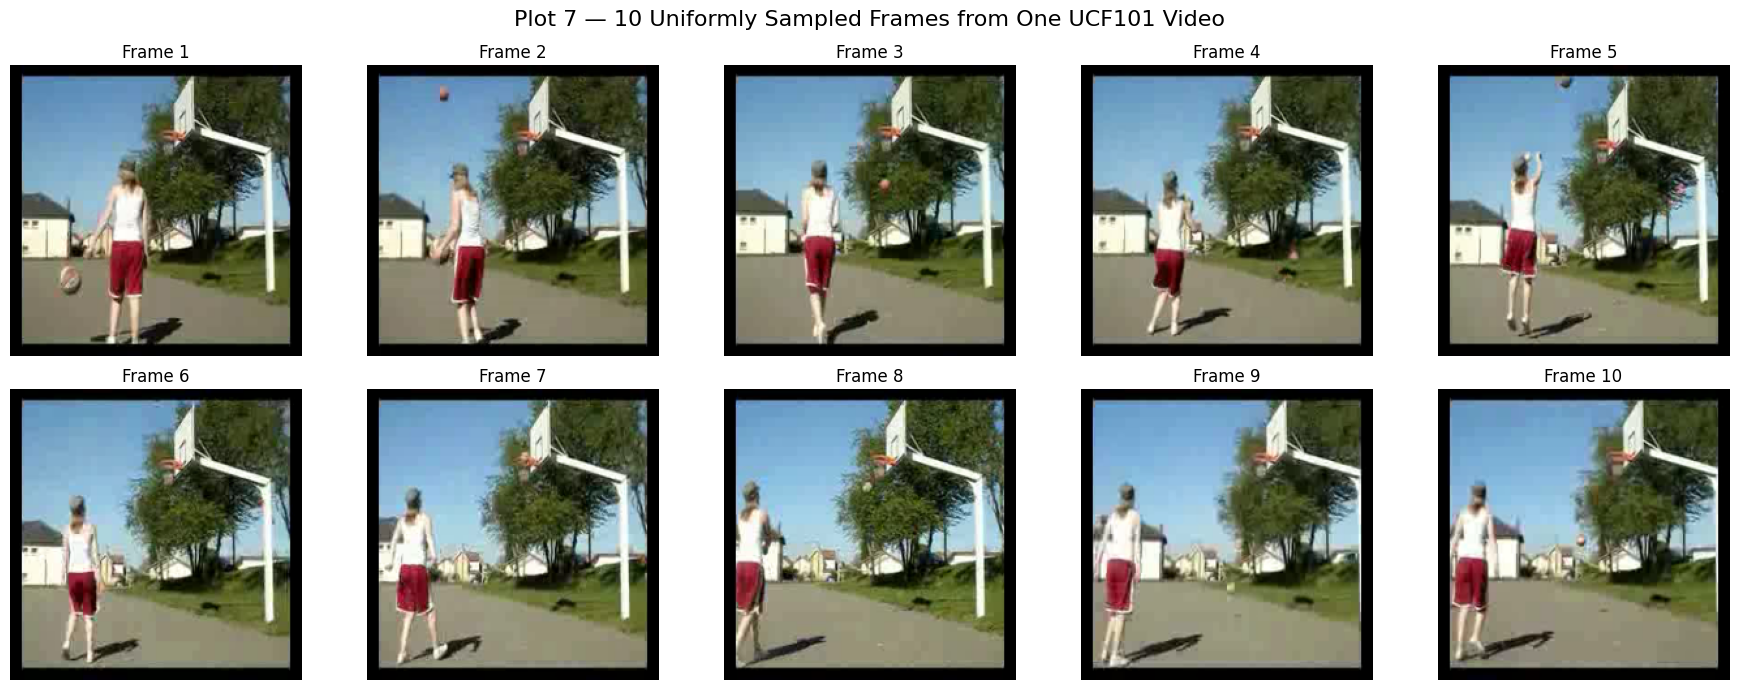


Plot 7 observation:
The CNN receives each frame independently.
The CNN extracts spatial features such as
- objects
- body appearance
- scene/background information
- spatial arrangement of visual patterns

TRAINING CNN-LSTM
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.5333 - loss: 1.0162 - val_accuracy: 0.3158 - val_loss: 0.9786
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8667 - loss: 0.6550 - val_accuracy: 0.4211 - val_loss: 0.7977
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9333 - loss: 0.5192 - val_accuracy: 0.4211 - val_loss: 0.7437
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9667 - loss: 0.4161 - val_accuracy: 0.7368 - val_loss: 0.6245
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.3252 - val_accuracy: 0.7368 - val_loss: 0.5443
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.2321 - val_accuracy: 0.8421 - val_loss: 0.5040
Epoch 7/20
8/8 ━━━━━━━━━━

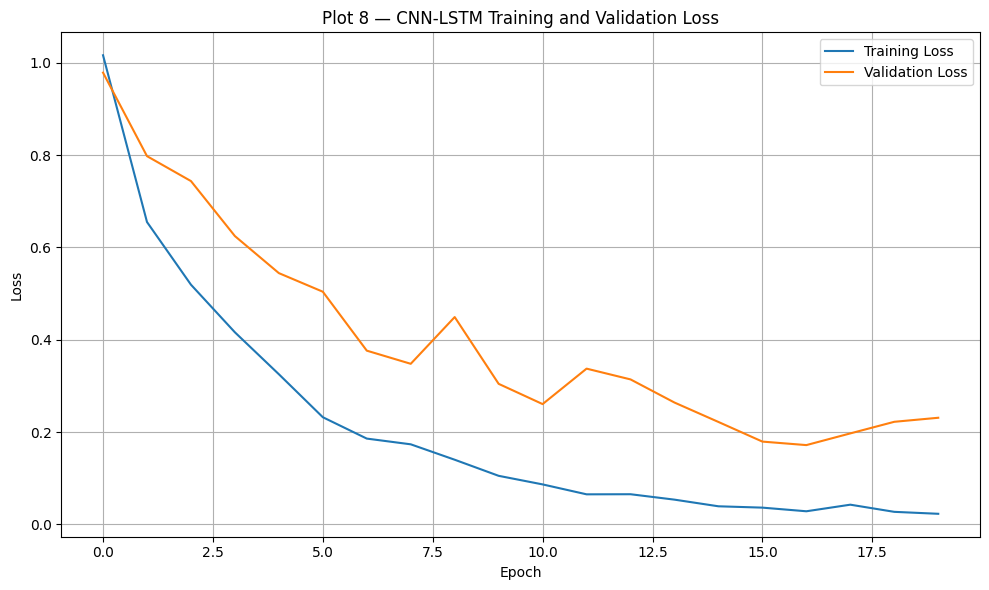

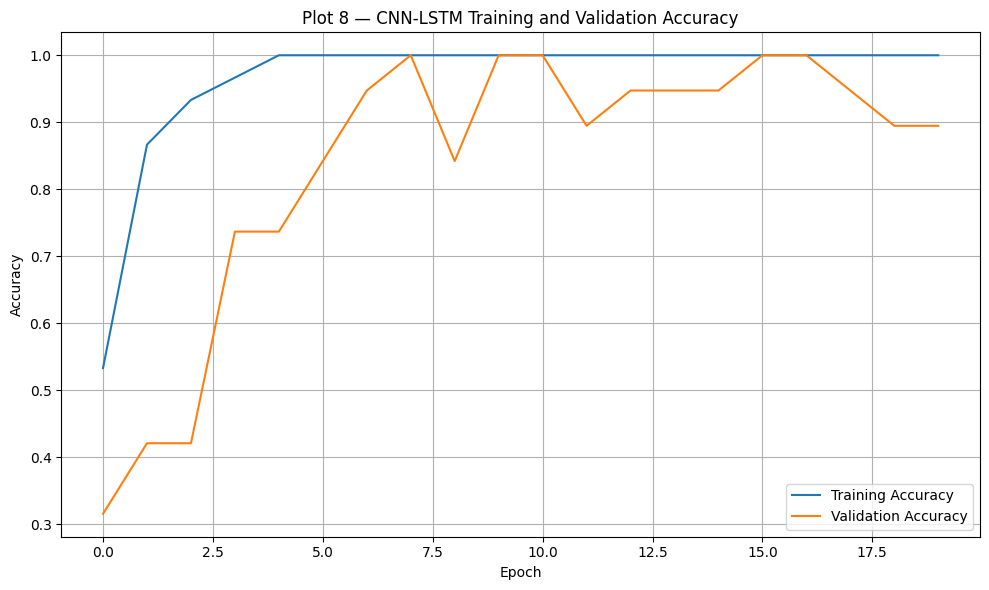

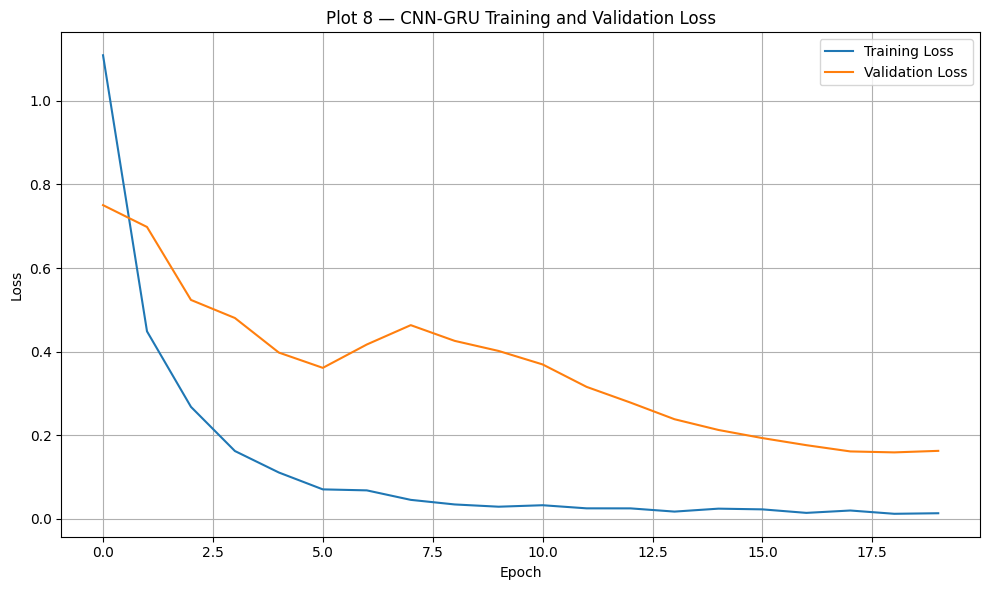

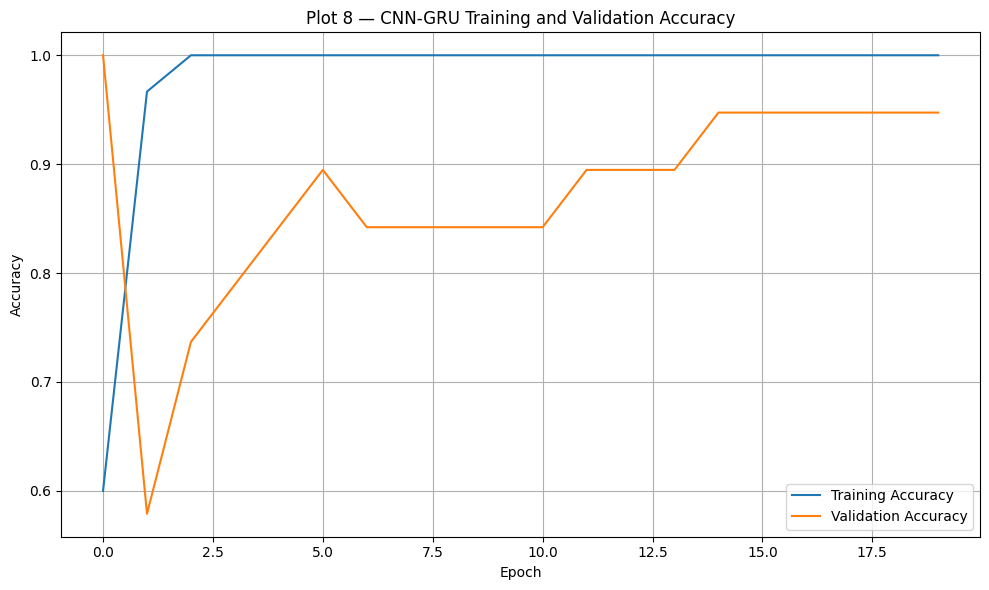

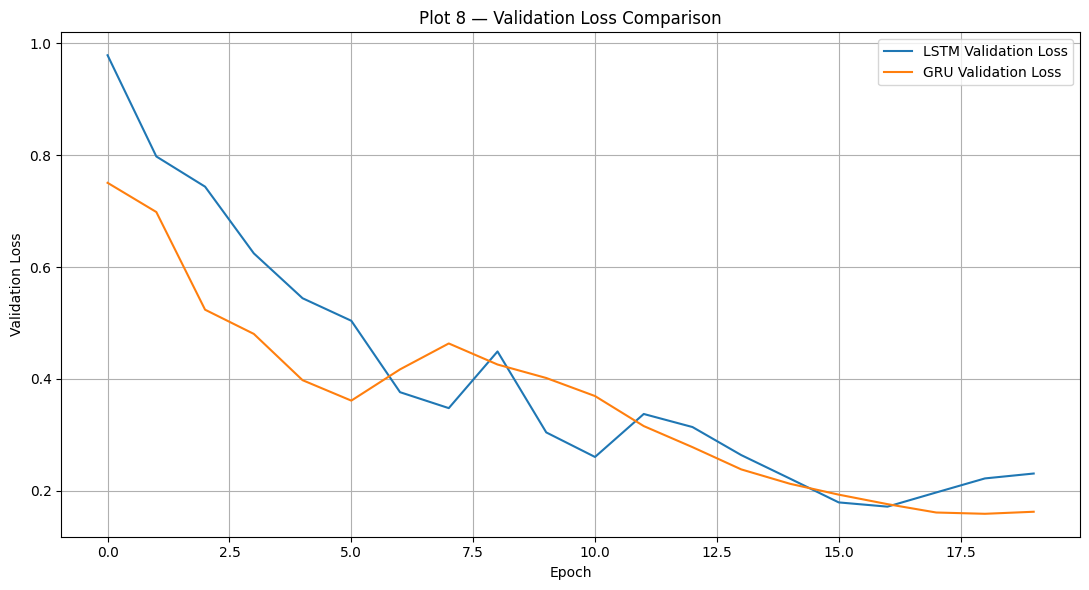

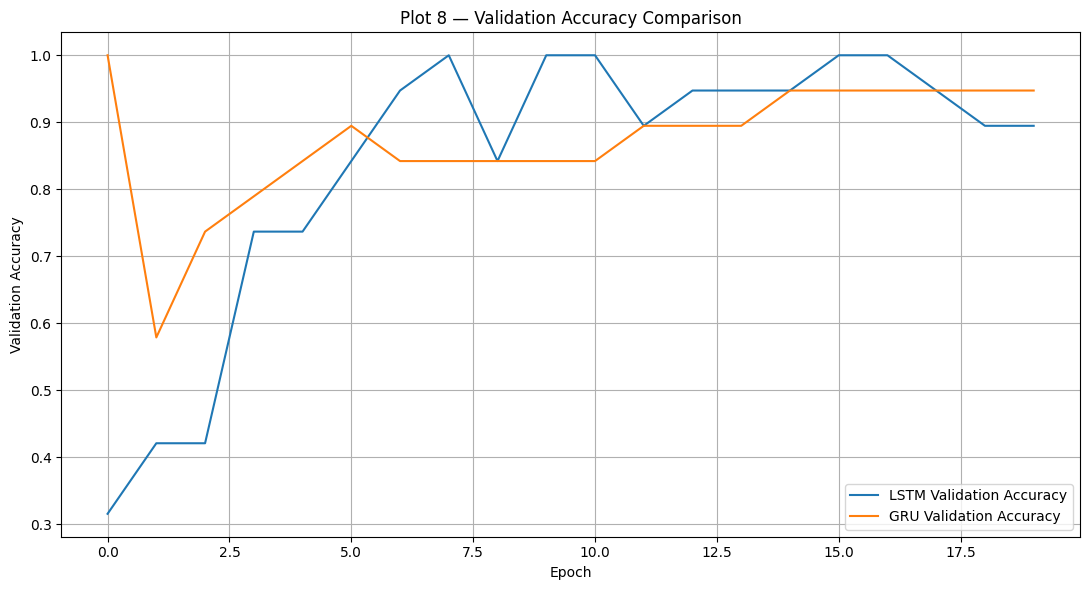


TESTING CNN-LSTM / CNN-GRU

Test results:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,CNN-LSTM,0.454545,0.314815,0.333333,0.285714
1,CNN-GRU,0.454545,0.314815,0.333333,0.285714


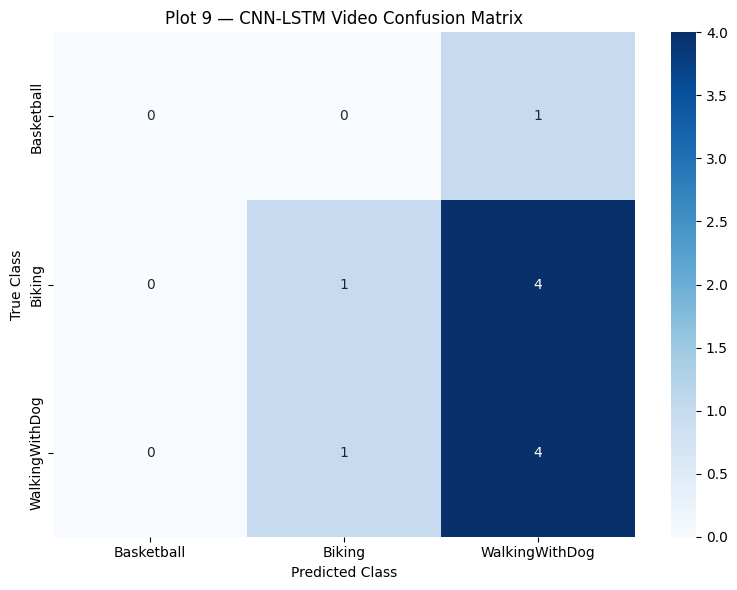

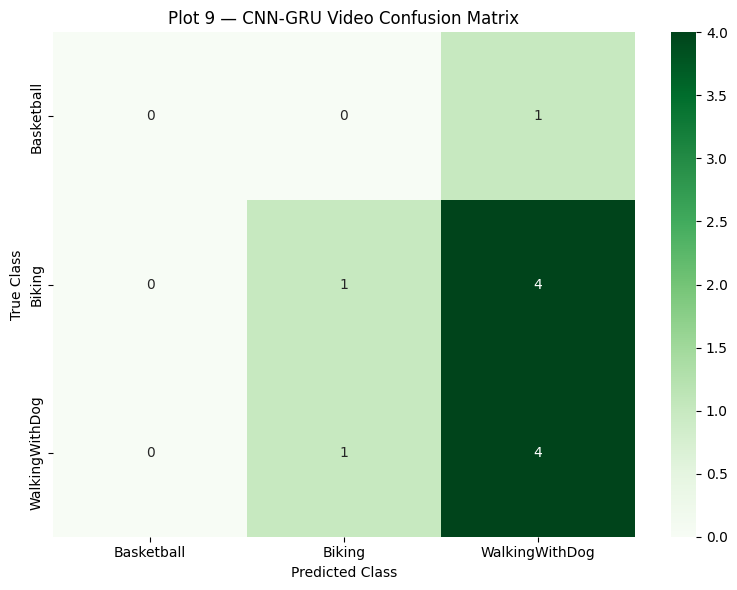

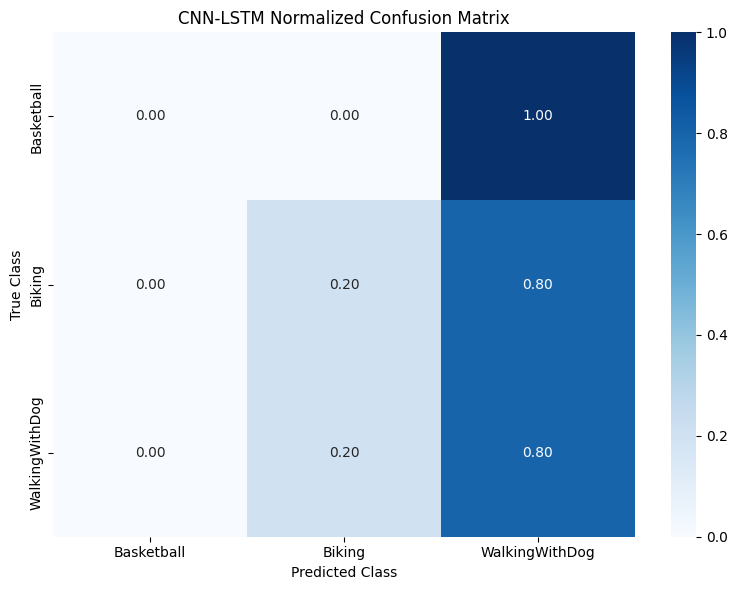

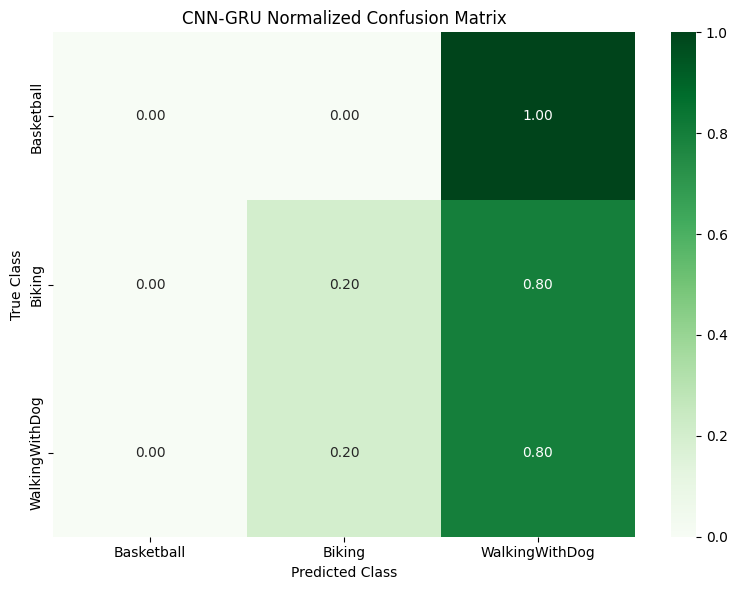


CNN-LSTM CLASS-LEVEL RECOGNITION


,Class,Correct,Total,Recognition Rate
0,Basketball,0,1,0.0
1,Biking,1,5,0.2
2,WalkingWithDog,4,5,0.8



CNN-GRU CLASS-LEVEL RECOGNITION


,Class,Correct,Total,Recognition Rate
0,Basketball,0,1,0.0
1,Biking,1,5,0.2
2,WalkingWithDog,4,5,0.8



CNN-LSTM CONFUSION PAIRS


...


CNN-GRU CONFUSION PAIRS


,Actual,Predicted,Count
0,Biking,WalkingWithDog,4
1,Basketball,WalkingWithDog,1
2,WalkingWithDog,Biking,1



SAMPLE VIDEO PREDICTION
Actual class: Basketball

CNN-LSTM:
Predicted: WalkingWithDog
Confidence: 0.8062

CNN-GRU:
Predicted: WalkingWithDog
Confidence: 0.9338

SAMPLE LSTM PROBABILITY VECTOR
Basketball          : 0.1715
Biking              : 0.0223
WalkingWithDog      : 0.8062

SAMPLE GRU PROBABILITY VECTOR
Basketball          : 0.0584
Biking              : 0.0079
WalkingWithDog      : 0.9338

TASK 21 FINAL RESULTS


,Architecture,Input Sequence,Recurrent Units,Test Accuracy,Macro Precision,Macro Recall,Macro F1
0,CNN-LSTM,10 × 1280,32,0.454545,0.314815,0.333333,0.285714
1,CNN-GRU,10 × 1280,32,0.454545,0.314815,0.333333,0.285714



TASK 21 DISCUSSION

1. SPATIAL INFORMATION CAPTURED BY CNN
---------------------------------------

The pretrained MobileNetV2 processes each video frame
independently.

It extracts spatial visual features representing
information such as objects, body appearance, scene
structure, and spatial patterns in the frame.

The classification head is removed and Global Average
Pooling produces a 1280-dimensional feature vector.


2. TEMPORAL INFORMATION LEARNED BY LSTM / GRU
----------------------------------------------

The 10 frame-level feature vectors form a temporal
sequence:

    10 × 1280

The LSTM or GRU processes these features in temporal
order.

Therefore, the recurrent network learns relationships
and changes between consecutive video frames.

For example, an action is not represented only by one
frame. Its temporal evolution across multiple frames
provides information about the action.


3. CNN + RECURRENT NETWORK
--------------------------

CNN:
    Learns spatial/frame-level v

In [ ]:
# ============================================================
# TASK 21 — CNN-LSTM / CNN-GRU MODEL
# ============================================================
#
# Architecture:
#
# 10 Frames
#      ↓
# Frozen MobileNetV2
#      ↓
# 10 × 1280
#      ↓
# LSTM / GRU (32 units)
#      ↓
# Dense(16)
#      ↓
# Softmax
#
# Required:
#
# Plot 7 — Video Sample Frames
# Plot 8 — Training / Validation Curves
# Plot 9 — Video Confusion Matrix
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout


# ============================================================
# 1. TASK 21 SETTINGS
# ============================================================

NUM_FRAMES = 10

FEATURE_DIM = 1280

NUM_CLASSES = 3

EPOCHS = 20

BATCH_SIZE = 4

SELECTED_CLASSES = [
    "Basketball",
    "Biking",
    "WalkingWithDog"
]


print("=" * 80)
print("TASK 21 — CNN-LSTM / CNN-GRU VIDEO MODEL")
print("=" * 80)


# ============================================================
# 2. VERIFY FEATURE INPUT
# ============================================================

print("\n" + "=" * 80)
print("INPUT VERIFICATION")
print("=" * 80)


print(
    "X_train shape:",
    X_train.shape
)

print(
    "X_val shape:",
    X_val.shape
)

print(
    "X_test shape:",
    X_test.shape
)


print(
    "\nExpected:"
)

print(
    "(Number of videos, 10, 1280)"
)


# ============================================================
# 3. VERIFY FEATURE DIMENSION
# ============================================================

actual_feature_dim = X_train.shape[-1]

print(
    "\nActual CNN feature dimension:",
    actual_feature_dim
)


if actual_feature_dim != FEATURE_DIM:

    print(
        "\nWARNING:"
    )

    print(
        "The actual feature dimension is",
        actual_feature_dim
    )

    print(
        "Updating FEATURE_DIM automatically."
    )

    FEATURE_DIM = actual_feature_dim


# ============================================================
# 4. MODEL CREATION FUNCTION
# ============================================================

def create_video_model(
    recurrent_type
):

    model = Sequential(
        name=f"CNN_{recurrent_type}_Video_Model"
    )


    # --------------------------------------------------------
    # CNN features are already extracted.
    #
    # Input:
    # 10 × D
    #
    # Here:
    # 10 × 1280
    # --------------------------------------------------------


    if recurrent_type == "LSTM":

        model.add(
            LSTM(
                32,
                input_shape=(
                    NUM_FRAMES,
                    FEATURE_DIM
                )
            )
        )


    elif recurrent_type == "GRU":

        model.add(
            GRU(
                32,
                input_shape=(
                    NUM_FRAMES,
                    FEATURE_DIM
                )
            )
        )


    else:

        raise ValueError(
            "recurrent_type must be 'LSTM' or 'GRU'"
        )


    # --------------------------------------------------------
    # Dense classifier
    # --------------------------------------------------------

    model.add(
        Dropout(
            0.2
        )
    )


    model.add(
        Dense(
            16,
            activation="relu"
        )
    )


    model.add(
        Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    )


    # --------------------------------------------------------
    # Compile
    # --------------------------------------------------------

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss=(
            "sparse_categorical_crossentropy"
        ),

        metrics=[
            "accuracy"
        ]
    )


    return model


# ============================================================
# 5. CREATE LSTM MODEL
# ============================================================

cnn_lstm = create_video_model(
    "LSTM"
)


print("\n" + "=" * 80)
print("CNN-LSTM MODEL")
print("=" * 80)


cnn_lstm.summary()


# ============================================================
# 6. CREATE GRU MODEL
# ============================================================

cnn_gru = create_video_model(
    "GRU"
)


print("\n" + "=" * 80)
print("CNN-GRU MODEL")
print("=" * 80)


cnn_gru.summary()


# ============================================================
# 7. MODEL ARCHITECTURE SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("ARCHITECTURE")
print("=" * 80)


print(
    """
10 Frames
    ↓
MobileNetV2 Feature Extraction
    ↓
10 × 1280
    ↓
LSTM(32) / GRU(32)
    ↓
Dropout(0.2)
    ↓
Dense(16, ReLU)
    ↓
Dense(3, Softmax)
"""
)


# ============================================================
# 8. PLOT 7 — VIDEO SAMPLE FRAMES
# ============================================================
#
# We need the original test video.
#
# test_df was created in Task 18.
# sample_video_path contains one test video.
# ============================================================

print("\n" + "=" * 80)
print("PLOT 7 — VIDEO SAMPLE FRAMES")
print("=" * 80)


sample_index = 0


sample_video_path = test_df.iloc[
    sample_index
]["path"]


sample_actual_class = test_df.iloc[
    sample_index
]["class_name"]


print(
    "Sample video:",
    sample_video_path
)

print(
    "Actual class:",
    sample_actual_class
)


# ------------------------------------------------------------
# Extract 10 uniform frames
# ------------------------------------------------------------

sample_frames = sample_uniform_frames(
    sample_video_path,
    NUM_FRAMES
)


print(
    "Sample frame tensor:",
    sample_frames.shape
)


# ============================================================
# PLOT 7
# ============================================================

plt.figure(
    figsize=(18, 7)
)


for i in range(
    NUM_FRAMES
):

    plt.subplot(
        2,
        5,
        i + 1
    )


    plt.imshow(
        sample_frames[i].astype(
            np.uint8
        )
    )


    plt.title(
        f"Frame {i + 1}"
    )


    plt.axis(
        "off"
    )


plt.suptitle(
    "Plot 7 — 10 Uniformly Sampled Frames from One UCF101 Video",
    fontsize=16
)


plt.tight_layout()

plt.show()


# ============================================================
# 9. PLOT 7 — PRINT FRAME INFORMATION
# ============================================================

print("\nPlot 7 observation:")

print(
    "The CNN receives each frame independently."
)

print(
    "The CNN extracts spatial features such as"
)

print(
    "- objects"
)

print(
    "- body appearance"
)

print(
    "- scene/background information"
)

print(
    "- spatial arrangement of visual patterns"
)


# ============================================================
# 10. TRAIN CNN-LSTM
# ============================================================

print("\n" + "=" * 80)
print("TRAINING CNN-LSTM")
print("=" * 80)


lstm_start_time = tf.timestamp()


cnn_lstm_history = cnn_lstm.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)


lstm_end_time = tf.timestamp()


lstm_training_time = float(
    lstm_end_time -
    lstm_start_time
)


print(
    "\nCNN-LSTM training completed."
)


# ============================================================
# 11. TRAIN CNN-GRU
# ============================================================

print("\n" + "=" * 80)
print("TRAINING CNN-GRU")
print("=" * 80)


gru_start_time = tf.timestamp()


cnn_gru_history = cnn_gru.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)


gru_end_time = tf.timestamp()


gru_training_time = float(
    gru_end_time -
    gru_start_time
)


print(
    "\nCNN-GRU training completed."
)


# ============================================================
# 12. PLOT 8A — LSTM LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    cnn_lstm_history.history[
        "loss"
    ],
    label="Training Loss"
)


plt.plot(
    cnn_lstm_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Plot 8 — CNN-LSTM Training and Validation Loss"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. PLOT 8B — LSTM ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    cnn_lstm_history.history[
        "accuracy"
    ],
    label="Training Accuracy"
)


plt.plot(
    cnn_lstm_history.history[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Plot 8 — CNN-LSTM Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ============================================================
# 14. PLOT 8C — GRU LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    cnn_gru_history.history[
        "loss"
    ],
    label="Training Loss"
)


plt.plot(
    cnn_gru_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Plot 8 — CNN-GRU Training and Validation Loss"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. PLOT 8D — GRU ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    cnn_gru_history.history[
        "accuracy"
    ],
    label="Training Accuracy"
)


plt.plot(
    cnn_gru_history.history[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Plot 8 — CNN-GRU Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. COMBINED PLOT 8 — LOSS
# ============================================================

plt.figure(
    figsize=(11, 6)
)


plt.plot(
    cnn_lstm_history.history[
        "val_loss"
    ],
    label="LSTM Validation Loss"
)


plt.plot(
    cnn_gru_history.history[
        "val_loss"
    ],
    label="GRU Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Loss"
)

plt.title(
    "Plot 8 — Validation Loss Comparison"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. COMBINED PLOT 8 — ACCURACY
# ============================================================

plt.figure(
    figsize=(11, 6)
)


plt.plot(
    cnn_lstm_history.history[
        "val_accuracy"
    ],
    label="LSTM Validation Accuracy"
)


plt.plot(
    cnn_gru_history.history[
        "val_accuracy"
    ],
    label="GRU Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Plot 8 — Validation Accuracy Comparison"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. TEST SET PREDICTIONS
# ============================================================

print("\n" + "=" * 80)
print("TESTING CNN-LSTM / CNN-GRU")
print("=" * 80)


lstm_probabilities = cnn_lstm.predict(
    X_test,
    verbose=0
)


gru_probabilities = cnn_gru.predict(
    X_test,
    verbose=0
)


lstm_predictions = np.argmax(
    lstm_probabilities,
    axis=1
)


gru_predictions = np.argmax(
    gru_probabilities,
    axis=1
)


# ============================================================
# 19. CALCULATE TEST METRICS
# ============================================================

def calculate_video_metrics(
    y_true,
    y_pred,
    model_name
):

    return {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Macro Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }


lstm_metrics = calculate_video_metrics(
    y_test,
    lstm_predictions,
    "CNN-LSTM"
)


gru_metrics = calculate_video_metrics(
    y_test,
    gru_predictions,
    "CNN-GRU"
)


video_results = pd.DataFrame([
    lstm_metrics,
    gru_metrics
])


print(
    "\nTest results:"
)

display(
    video_results
)


# ============================================================
# 20. PLOT 9 — LSTM CONFUSION MATRIX
# ============================================================

lstm_cm = confusion_matrix(
    y_test,
    lstm_predictions,
    labels=range(
        NUM_CLASSES
    )
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "Plot 9 — CNN-LSTM Video Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. PLOT 9 — GRU CONFUSION MATRIX
# ============================================================

gru_cm = confusion_matrix(
    y_test,
    gru_predictions,
    labels=range(
        NUM_CLASSES
    )
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    gru_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "Plot 9 — CNN-GRU Video Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. NORMALIZED CONFUSION MATRIX — LSTM
# ============================================================

lstm_cm_normalized = (
    lstm_cm /
    np.maximum(
        lstm_cm.sum(
            axis=1,
            keepdims=True
        ),
        1
    )
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    lstm_cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "CNN-LSTM Normalized Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. NORMALIZED CONFUSION MATRIX — GRU
# ============================================================

gru_cm_normalized = (
    gru_cm /
    np.maximum(
        gru_cm.sum(
            axis=1,
            keepdims=True
        ),
        1
    )
)


plt.figure(
    figsize=(8, 6)
)


sns.heatmap(
    gru_cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES
)


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "CNN-GRU Normalized Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 24. CLASS-LEVEL RECOGNITION
# ============================================================

def class_recognition(
    cm,
    class_names
):

    rows = []


    for i, class_name in enumerate(
        class_names
    ):

        total = cm[i].sum()


        if total > 0:

            recognition = (
                cm[i, i] /
                total
            )

        else:

            recognition = 0


        rows.append({

            "Class":
                class_name,

            "Correct":
                int(cm[i, i]),

            "Total":
                int(total),

            "Recognition Rate":
                recognition

        })


    return pd.DataFrame(
        rows
    )


print("\n" + "=" * 80)
print("CNN-LSTM CLASS-LEVEL RECOGNITION")
print("=" * 80)


lstm_class_results = class_recognition(
    lstm_cm,
    SELECTED_CLASSES
)


display(
    lstm_class_results
)


print("\n" + "=" * 80)
print("CNN-GRU CLASS-LEVEL RECOGNITION")
print("=" * 80)


gru_class_results = class_recognition(
    gru_cm,
    SELECTED_CLASSES
)


display(
    gru_class_results
)


# ============================================================
# 25. FIND TEMPORAL / ACTION CONFUSION PAIRS
# ============================================================

def get_confusion_pairs(
    cm,
    class_names
):

    pairs = []


    for i in range(
        len(class_names)
    ):

        for j in range(
            len(class_names)
        ):

            if i != j:

                count = cm[i, j]


                if count > 0:

                    pairs.append({

                        "Actual":
                            class_names[i],

                        "Predicted":
                            class_names[j],

                        "Count":
                            int(count)

                    })


    if len(pairs) == 0:

        return pd.DataFrame(
            columns=[
                "Actual",
                "Predicted",
                "Count"
            ]
        )


    return pd.DataFrame(
        pairs
    ).sort_values(
        "Count",
        ascending=False
    ).reset_index(
        drop=True
    )


print("\n" + "=" * 80)
print("CNN-LSTM CONFUSION PAIRS")
print("=" * 80)


lstm_confusion_pairs = (
    get_confusion_pairs(
        lstm_cm,
        SELECTED_CLASSES
    )
)


display(
    lstm_confusion_pairs
)


print("\n" + "=" * 80)
print("CNN-GRU CONFUSION PAIRS")
print("=" * 80)


gru_confusion_pairs = (
    get_confusion_pairs(
        gru_cm,
        SELECTED_CLASSES
    )
)


display(
    gru_confusion_pairs
)


# ============================================================
# 26. DISPLAY SAMPLE PREDICTION
# ============================================================

print("\n" + "=" * 80)
print("SAMPLE VIDEO PREDICTION")
print("=" * 80)


sample_test_index = 0


sample_features = np.expand_dims(
    X_test[
        sample_test_index
    ],
    axis=0
)


actual_id = y_test[
    sample_test_index
]


actual_class = SELECTED_CLASSES[
    actual_id
]


# LSTM
lstm_sample_probabilities = (
    cnn_lstm.predict(
        sample_features,
        verbose=0
    )[0]
)


lstm_sample_id = np.argmax(
    lstm_sample_probabilities
)


lstm_sample_class = (
    SELECTED_CLASSES[
        lstm_sample_id
    ]
)


lstm_sample_confidence = (
    lstm_sample_probabilities[
        lstm_sample_id
    ]
)


# GRU
gru_sample_probabilities = (
    cnn_gru.predict(
        sample_features,
        verbose=0
    )[0]
)


gru_sample_id = np.argmax(
    gru_sample_probabilities
)


gru_sample_class = (
    SELECTED_CLASSES[
        gru_sample_id
    ]
)


gru_sample_confidence = (
    gru_sample_probabilities[
        gru_sample_id
    ]
)


print(
    "Actual class:",
    actual_class
)


print("\nCNN-LSTM:")

print(
    "Predicted:",
    lstm_sample_class
)

print(
    "Confidence:",
    f"{lstm_sample_confidence:.4f}"
)


print("\nCNN-GRU:")

print(
    "Predicted:",
    gru_sample_class
)

print(
    "Confidence:",
    f"{gru_sample_confidence:.4f}"
)


# ============================================================
# 27. SAMPLE PROBABILITY VECTOR
# ============================================================

print("\n" + "=" * 80)
print("SAMPLE LSTM PROBABILITY VECTOR")
print("=" * 80)


for class_name, probability in zip(
    SELECTED_CLASSES,
    lstm_sample_probabilities
):

    print(
        f"{class_name:<20}: "
        f"{probability:.4f}"
    )


print("\n" + "=" * 80)
print("SAMPLE GRU PROBABILITY VECTOR")
print("=" * 80)


for class_name, probability in zip(
    SELECTED_CLASSES,
    gru_sample_probabilities
):

    print(
        f"{class_name:<20}: "
        f"{probability:.4f}"
    )


# ============================================================
# 28. FINAL TASK 21 TABLE
# ============================================================

final_task21 = pd.DataFrame({

    "Architecture": [
        "CNN-LSTM",
        "CNN-GRU"
    ],

    "Input Sequence": [
        "10 × 1280",
        "10 × 1280"
    ],

    "Recurrent Units": [
        32,
        32
    ],

    "Test Accuracy": [
        lstm_metrics[
            "Accuracy"
        ],

        gru_metrics[
            "Accuracy"
        ]
    ],

    "Macro Precision": [
        lstm_metrics[
            "Macro Precision"
        ],

        gru_metrics[
            "Macro Precision"
        ]
    ],

    "Macro Recall": [
        lstm_metrics[
            "Macro Recall"
        ],

        gru_metrics[
            "Macro Recall"
        ]
    ],

    "Macro F1": [
        lstm_metrics[
            "Macro F1"
        ],

        gru_metrics[
            "Macro F1"
        ]
    ]

})


print("\n" + "=" * 80)
print("TASK 21 FINAL RESULTS")
print("=" * 80)


display(
    final_task21
)


# ============================================================
# 29. TASK 21 DISCUSSION POINTS
# ============================================================

print("\n" + "=" * 80)
print("TASK 21 DISCUSSION")
print("=" * 80)


print(
    """
1. SPATIAL INFORMATION CAPTURED BY CNN
---------------------------------------

The pretrained MobileNetV2 processes each video frame
independently.

It extracts spatial visual features representing
information such as objects, body appearance, scene
structure, and spatial patterns in the frame.

The classification head is removed and Global Average
Pooling produces a 1280-dimensional feature vector.


2. TEMPORAL INFORMATION LEARNED BY LSTM / GRU
----------------------------------------------

The 10 frame-level feature vectors form a temporal
sequence:

    10 × 1280

The LSTM or GRU processes these features in temporal
order.

Therefore, the recurrent network learns relationships
and changes between consecutive video frames.

For example, an action is not represented only by one
frame. Its temporal evolution across multiple frames
provides information about the action.


3. CNN + RECURRENT NETWORK
--------------------------

CNN:
    Learns spatial/frame-level visual information.

LSTM / GRU:
    Learns temporal relationships between frames.

Together:

Video
  ↓
Frames
  ↓
CNN spatial features
  ↓
Temporal feature sequence
  ↓
LSTM / GRU
  ↓
Action classification
"""
)


# ============================================================
# 30. AUTOMATIC CONFUSION ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("OBSERVED CONFUSION ANALYSIS")
print("=" * 80)


def print_confusion_analysis(
    cm,
    model_name
):

    print(
        f"\n{model_name}"
    )

    # --------------------------------------------------------
    # Class recognition
    # --------------------------------------------------------

    recognition = []


    for i, class_name in enumerate(
        SELECTED_CLASSES
    ):

        total = cm[i].sum()


        if total > 0:

            rate = (
                cm[i, i] /
                total
            )

        else:

            rate = 0


        recognition.append(
            (
                class_name,
                rate
            )
        )


        print(
            f"{class_name}: "
            f"{rate * 100:.2f}% "
            "recognition"
        )


    # --------------------------------------------------------
    # Largest off-diagonal confusion
    # --------------------------------------------------------

    cm_copy = cm.copy()


    for i in range(
        len(SELECTED_CLASSES)
    ):

        cm_copy[i, i] = 0


    if cm_copy.max() > 0:

        max_index = np.unravel_index(
            np.argmax(cm_copy),
            cm_copy.shape
        )


        true_idx = max_index[0]

        pred_idx = max_index[1]

        count = cm_copy[
            true_idx,
            pred_idx
        ]


        print(
            "\nMost frequent observed confusion:"
        )


        print(
            SELECTED_CLASSES[
                true_idx
            ],
            "→",
            SELECTED_CLASSES[
                pred_idx
            ],
            ":",
            int(count)
        )


    else:

        print(
            "\nNo off-diagonal confusions."
        )


print_confusion_analysis(
    lstm_cm,
    "CNN-LSTM"
)


print_confusion_analysis(
    gru_cm,
    "CNN-GRU"
)


# ============================================================
# 31. SAVE MODELS
# ============================================================

cnn_lstm.save(
    "/content/cnn_lstm_ucf101.keras"
)


cnn_gru.save(
    "/content/cnn_gru_ucf101.keras"
)


print("\n" + "=" * 80)
print("TASK 21 COMPLETED")
print("=" * 80)

print(
    "\nModels saved:"
)

print(
    "/content/cnn_lstm_ucf101.keras"
)

print(
    "/content/cnn_gru_ucf101.keras"
)

TASK 22 — SEQUENCE-TO-SEQUENCE LEARNING
TensorFlow version: 2.20.0

PARAMETERS
Number of sequences: 5000
Sequence length: 4
Integer range: 1 to 9
LSTM latent dimension: 64
Batch size: 64
Epochs: 30

DATASET
Input shape: (5000, 4)
Target shape: (5000, 4)

Sample sequences:
------------------------------------------------------------
[7, 4, 8, 5] -> [5, 8, 4, 7]
[7, 3, 7, 8] -> [8, 7, 3, 7]
[5, 4, 8, 8] -> [8, 8, 4, 5]
[3, 6, 5, 2] -> [2, 5, 6, 3]
[8, 6, 2, 5] -> [5, 2, 6, 8]
[1, 6, 9, 1] -> [1, 9, 6, 1]
[3, 7, 4, 9] -> [9, 4, 7, 3]
[3, 5, 3, 7] -> [7, 3, 5, 3]
[5, 9, 7, 2] -> [2, 7, 9, 5]
[4, 9, 2, 9] -> [9, 2, 9, 4]

DATA SPLIT
Training: (3500, 4) (3500, 4)
Validation: (750, 4) (750, 4)
Test: (750, 4) (750, 4)

ONE-HOT ENCODING
Y_train: (3500, 4, 10)

Decoder input example:
Target: [5 8 4 7]
Decoder input: [0 5 8 4]

SEQ2SEQ MODEL


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     19,200 │ encoder_input[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 4, 64),   │     19,200 │ decoder_input[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax      │ (None, 4, 10)     │        650 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,050 (152.54 KB)

 Trainable params: 39,050 (152.54 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING SEQUENCE-TO-SEQUENCE MODEL
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.2845 - loss: 2.1772 - val_accuracy: 0.3590 - val_loss: 1.8997
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3906 - loss: 1.5481 - val_accuracy: 0.4360 - val_loss: 1.3218
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4631 - loss: 1.2003 - val_accuracy: 0.5507 - val_loss: 1.0716
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6432 - loss: 0.9427 - val_accuracy: 0.7677 - val_loss: 0.7948
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8486 - loss: 0.6591 - val_accuracy: 0.9090 - val_loss: 0.5216
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9442 - loss: 0.4234 - val_accuracy: 0.9650 - val_loss: 0.3388
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9793 - loss: 0.2740 - val_accuracy: 0.9867 - val_loss: 0.2246
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9936 - l

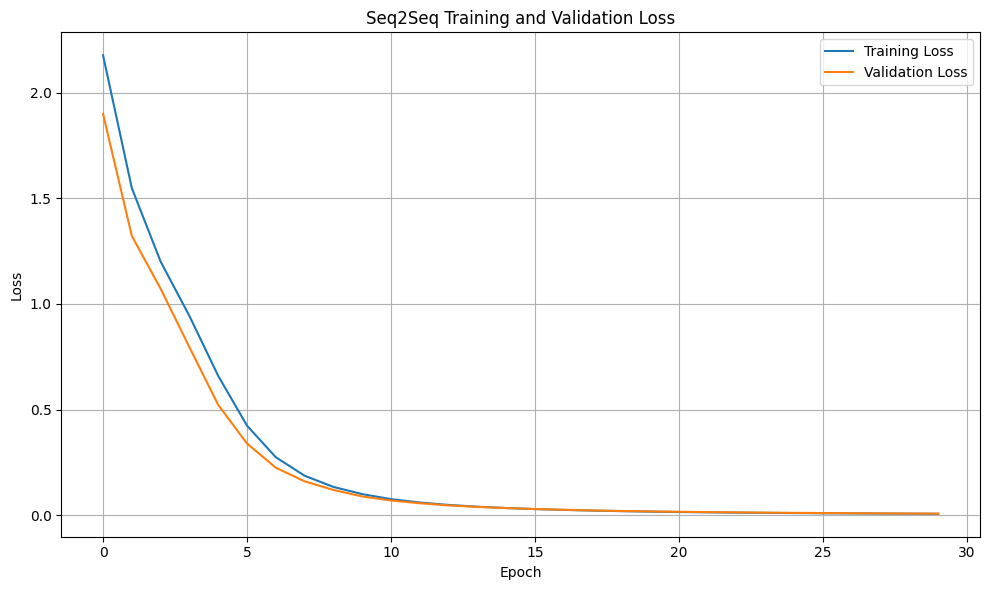

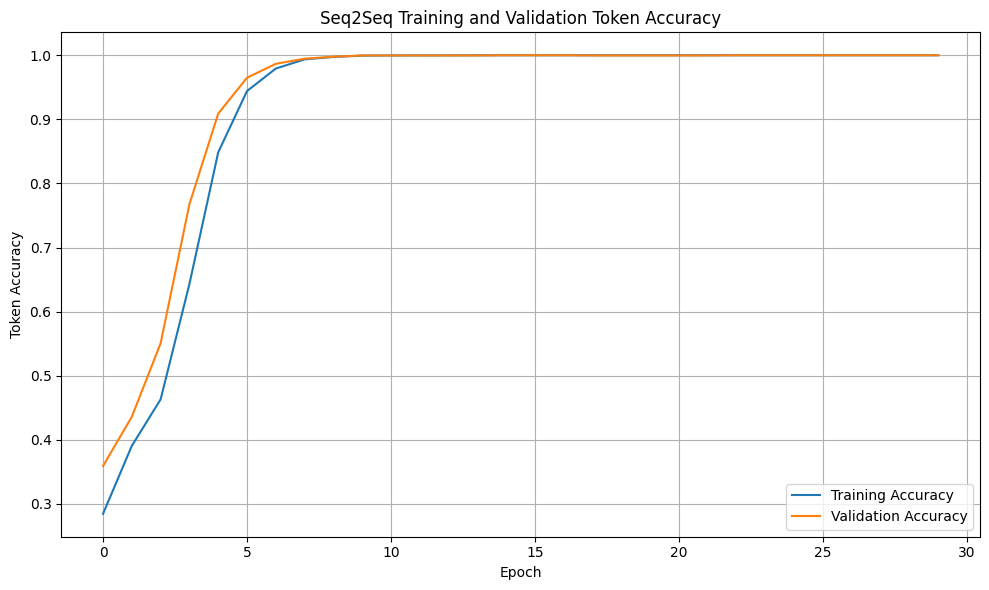


SINGLE SEQUENCE TEST
Input sequence : [1, 4, 7, 2]
Expected output: [2, 7, 4, 1]
Predicted output: [2, 7, 4, 1]
Confidence: [0.9949, 0.9975, 0.9835, 0.9992]

TEST SET EVALUATION

Token Accuracy: 1.0000
Token Accuracy (%): 100.00%

Sequence Accuracy: 1.0000
Sequence Accuracy (%): 100.00%

SAMPLE TEST PREDICTIONS

Example 1
Input     : [4, 2, 3, 7]
Expected  : [7, 3, 2, 4]
Predicted : [7, 3, 2, 4]
Correct   : True

Example 2
Input     : [7, 1, 8, 7]
Expected  : [7, 8, 1, 7]
Predicted : [7, 8, 1, 7]
Correct   : True

Example 3
Input     : [1, 8, 2, 8]
Expected  : [8, 2, 8, 1]
Predicted : [8, 2, 8, 1]
Correct   : True

Example 4
Input     : [3, 7, 6, 5]
Expected  : [5, 6, 7, 3]
Predicted : [5, 6, 7, 3]
Correct   : True

Example 5
Input     : [2, 2, 1, 9]
Expected  : [9, 1, 2, 2]
Predicted : [9, 1, 2, 2]
Correct   : True

Example 6
Input     : [8, 8, 1, 5]
Expected  : [5, 1, 8, 8]
Predicted : [5, 1, 8, 8]
Correct   : True

Example 7
Input     : [6, 2, 5, 6]
Expected  : [6, 5, 2, 6]
Predict

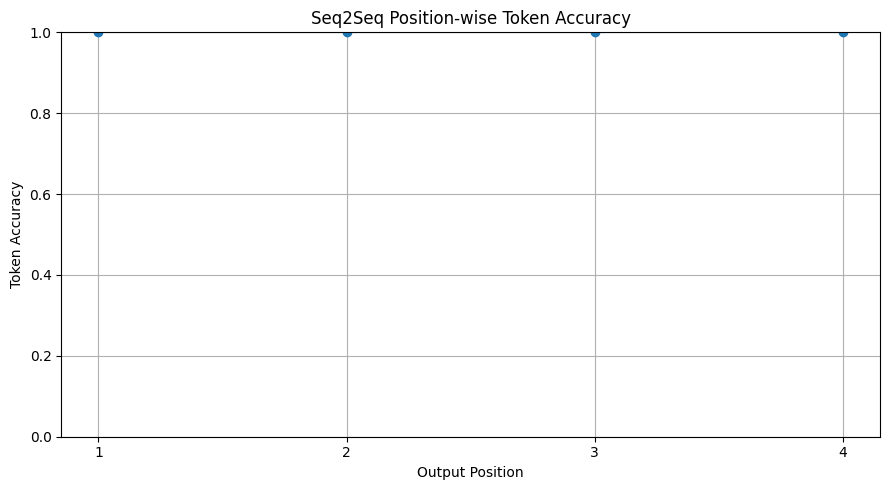


SEQ2SEQ FINAL RESULTS


,Metric,Value,Percentage
0,Token Accuracy,1.0,100.0
1,Sequence Accuracy,1.0,100.0



TASK 22 DISCUSSION

SEQUENCE-TO-SEQUENCE LEARNING
-----------------------------

The encoder LSTM processes the complete input sequence
and compresses the sequence information into its hidden
and cell states.

These states act as the context passed to the decoder.

The decoder LSTM then generates the output sequence
one element at a time.


EXAMPLE
-------

Input:
[1, 4, 7, 2]

Target:
[2, 7, 4, 1]

The required transformation is sequence reversal.


TOKEN ACCURACY
--------------

Token accuracy measures how many individual output
elements are predicted correctly.


SEQUENCE ACCURACY
-----------------

Sequence accuracy requires every element of the entire
sequence to be correct.

Therefore, a sequence can have high token accuracy but
still be counted as incorrect at the sequence level if
even one output element is wrong.


WHY SEQUENCE ACCURACY CAN BE LOWER
----------------------------------

For a sequence of multiple elements, an error in even
one position causes the complete seque

In [ ]:
# ============================================================
# CS3807 DEEP LEARNING LAB
# EXPERIMENT 6
#
# TASK 22 — SEQUENCE-TO-SEQUENCE LEARNING
#
# Synthetic sequence reversal
#
# Example:
# [1, 4, 7, 2] -> [2, 7, 4, 1]
#
# Architecture:
#
# Input Sequence
#       ↓
# Encoder LSTM
#       ↓
# Context State
#       ↓
# Decoder LSTM
#       ↓
# Output Sequence
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense
)

from tensorflow.keras.optimizers import Adam


print("=" * 75)
print("TASK 22 — SEQUENCE-TO-SEQUENCE LEARNING")
print("=" * 75)

print(
    "TensorFlow version:",
    tf.__version__
)


# ============================================================
# 2. RANDOM SEED
# ============================================================

np.random.seed(42)
tf.random.set_seed(42)


# ============================================================
# 3. PARAMETERS
# ============================================================

NUM_SAMPLES = 5000

SEQUENCE_LENGTH = 4

MIN_VALUE = 1

MAX_VALUE = 9

LATENT_DIM = 64

BATCH_SIZE = 64

EPOCHS = 30


print("\n" + "=" * 75)
print("PARAMETERS")
print("=" * 75)

print(
    "Number of sequences:",
    NUM_SAMPLES
)

print(
    "Sequence length:",
    SEQUENCE_LENGTH
)

print(
    "Integer range:",
    f"{MIN_VALUE} to {MAX_VALUE}"
)

print(
    "LSTM latent dimension:",
    LATENT_DIM
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Epochs:",
    EPOCHS
)


# ============================================================
# 4. GENERATE SYNTHETIC DATASET
# ============================================================
#
# Example:
#
# Input:
# [1, 4, 7, 2]
#
# Target:
# [2, 7, 4, 1]
#
# ============================================================

X = np.random.randint(
    MIN_VALUE,
    MAX_VALUE + 1,
    size=(
        NUM_SAMPLES,
        SEQUENCE_LENGTH
    )
)


Y = np.flip(
    X,
    axis=1
)


print("\n" + "=" * 75)
print("DATASET")
print("=" * 75)

print(
    "Input shape:",
    X.shape
)

print(
    "Target shape:",
    Y.shape
)


# ============================================================
# 5. DISPLAY SAMPLE SEQUENCES
# ============================================================

print("\nSample sequences:")
print("-" * 60)


for i in range(10):

    print(
        f"{X[i].tolist()} "
        f"-> "
        f"{Y[i].tolist()}"
    )


# ============================================================
# 6. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_end = int(
    0.70 * NUM_SAMPLES
)

val_end = int(
    0.85 * NUM_SAMPLES
)


X_train = X[
    :train_end
]

Y_train = Y[
    :train_end
]


X_val = X[
    train_end:val_end
]

Y_val = Y[
    train_end:val_end
]


X_test = X[
    val_end:
]

Y_test = Y[
    val_end:
]


print("\n" + "=" * 75)
print("DATA SPLIT")
print("=" * 75)

print(
    "Training:",
    X_train.shape,
    Y_train.shape
)

print(
    "Validation:",
    X_val.shape,
    Y_val.shape
)

print(
    "Test:",
    X_test.shape,
    Y_test.shape
)


# ============================================================
# 7. ONE-HOT ENCODING
# ============================================================
#
# Values are 1–9.
#
# We reserve token 0 for padding/start representation.
#
# Vocabulary size:
# 10
#
# Indices:
# 0 = special/start
# 1–9 = sequence values
# ============================================================

VOCAB_SIZE = MAX_VALUE + 1


def one_hot_encode(
    sequences
):

    return tf.keras.utils.to_categorical(
        sequences,
        num_classes=VOCAB_SIZE
    )


Y_train_onehot = one_hot_encode(
    Y_train
)

Y_val_onehot = one_hot_encode(
    Y_val
)

Y_test_onehot = one_hot_encode(
    Y_test
)


print("\n" + "=" * 75)
print("ONE-HOT ENCODING")
print("=" * 75)

print(
    "Y_train:",
    Y_train_onehot.shape
)


# ============================================================
# 8. PREPARE DECODER INPUT
# ============================================================
#
# During training, decoder input is:
#
# [0, y1, y2, y3]
#
# and target is:
#
# [y1, y2, y3, y4]
#
# This is teacher forcing.
#
# Example:
#
# Target:
# [2, 7, 4, 1]
#
# Decoder input:
# [0, 2, 7, 4]
#
# ============================================================

def create_decoder_input(
    target_sequences
):

    decoder_input = np.zeros_like(
        target_sequences
    )


    decoder_input[:, 1:] = (
        target_sequences[:, :-1]
    )


    return decoder_input


decoder_train = create_decoder_input(
    Y_train
)

decoder_val = create_decoder_input(
    Y_val
)

decoder_test = create_decoder_input(
    Y_test
)


decoder_train_onehot = one_hot_encode(
    decoder_train
)

decoder_val_onehot = one_hot_encode(
    decoder_val
)

decoder_test_onehot = one_hot_encode(
    decoder_test
)


print("\nDecoder input example:")

print(
    "Target:",
    Y_train[0]
)

print(
    "Decoder input:",
    decoder_train[0]
)


# ============================================================
# 9. ENCODER
# ============================================================
#
# Input:
# sequence of integers
#
# Embedding is not required for this small synthetic task.
# We use one-hot vectors directly.
#
# Encoder LSTM produces:
#
# encoder_output
# hidden state h
# cell state c
#
# The final h and c form the context/state passed
# to the decoder.
# ============================================================

encoder_inputs = Input(
    shape=(
        SEQUENCE_LENGTH,
        VOCAB_SIZE
    ),
    name="encoder_input"
)


encoder_lstm = LSTM(
    LATENT_DIM,
    return_state=True,
    name="encoder_lstm"
)


encoder_output, state_h, state_c = (
    encoder_lstm(
        encoder_inputs
    )
)


# ============================================================
# 10. DECODER
# ============================================================

decoder_inputs = Input(
    shape=(
        SEQUENCE_LENGTH,
        VOCAB_SIZE
    ),
    name="decoder_input"
)


decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)


decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=[
        state_h,
        state_c
    ]
)


# ============================================================
# 11. OUTPUT LAYER
# ============================================================

decoder_dense = Dense(
    VOCAB_SIZE,
    activation="softmax",
    name="output_softmax"
)


decoder_outputs = decoder_dense(
    decoder_outputs
)


# ============================================================
# 12. COMPLETE TRAINING MODEL
# ============================================================

seq2seq_model = Model(
    [
        encoder_inputs,
        decoder_inputs
    ],
    decoder_outputs
)


# ============================================================
# 13. COMPILE
# ============================================================

seq2seq_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss=(
        "categorical_crossentropy"
    ),

    metrics=[
        "accuracy"
    ]
)


# ============================================================
# 14. MODEL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("SEQ2SEQ MODEL")
print("=" * 75)


seq2seq_model.summary()


# ============================================================
# 15. TRAIN
# ============================================================

print("\n" + "=" * 75)
print("TRAINING SEQUENCE-TO-SEQUENCE MODEL")
print("=" * 75)


history = seq2seq_model.fit(

    [
        one_hot_encode(X_train),
        decoder_train_onehot
    ],

    Y_train_onehot,

    validation_data=(

        [
            one_hot_encode(X_val),
            decoder_val_onehot
        ],

        Y_val_onehot
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1
)


# ============================================================
# 16. TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    history.history[
        "loss"
    ],
    label="Training Loss"
)


plt.plot(
    history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Seq2Seq Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 17. TRAINING ACCURACY
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    history.history[
        "accuracy"
    ],
    label="Training Accuracy"
)


plt.plot(
    history.history[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Token Accuracy"
)

plt.title(
    "Seq2Seq Training and Validation Token Accuracy"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 18. CREATE INFERENCE ENCODER
# ============================================================

encoder_model = Model(
    encoder_inputs,
    [
        state_h,
        state_c
    ]
)


# ============================================================
# 19. CREATE INFERENCE DECODER
# ============================================================

decoder_state_h = Input(
    shape=(LATENT_DIM,),
    name="decoder_state_h"
)


decoder_state_c = Input(
    shape=(LATENT_DIM,),
    name="decoder_state_c"
)


decoder_single_input = Input(
    shape=(1, VOCAB_SIZE),
    name="decoder_single_input"
)


decoder_single_output, new_h, new_c = (
    decoder_lstm(
        decoder_single_input,
        initial_state=[
            decoder_state_h,
            decoder_state_c
        ]
    )
)


decoder_single_output = decoder_dense(
    decoder_single_output
)


decoder_model = Model(
    [
        decoder_single_input,
        decoder_state_h,
        decoder_state_c
    ],

    [
        decoder_single_output,
        new_h,
        new_c
    ]
)


# ============================================================
# 20. SEQUENCE DECODING FUNCTION
# ============================================================

def decode_sequence(
    input_sequence
):

    # --------------------------------------------------------
    # One-hot encode input
    # --------------------------------------------------------

    encoder_input = one_hot_encode(
        np.array([
            input_sequence
        ])
    )


    # --------------------------------------------------------
    # Encoder
    # --------------------------------------------------------

    h, c = encoder_model.predict(
        encoder_input,
        verbose=0
    )


    # --------------------------------------------------------
    # Start token
    # --------------------------------------------------------

    current_token = 0


    decoded_sequence = []

    probabilities = []


    # --------------------------------------------------------
    # Generate one element at a time
    # --------------------------------------------------------

    for t in range(
        SEQUENCE_LENGTH
    ):

        decoder_input = np.zeros(
            (
                1,
                1,
                VOCAB_SIZE
            ),
            dtype=np.float32
        )


        decoder_input[
            0,
            0,
            current_token
        ] = 1.0


        output, h, c = (
            decoder_model.predict(
                [
                    decoder_input,
                    h,
                    c
                ],
                verbose=0
            )
        )


        probability_vector = (
            output[0, 0]
        )


        predicted_token = int(
            np.argmax(
                probability_vector
            )
        )


        confidence = float(
            probability_vector[
                predicted_token
            ]
        )


        decoded_sequence.append(
            predicted_token
        )


        probabilities.append(
            confidence
        )


        current_token = (
            predicted_token
        )


    return (
        decoded_sequence,
        probabilities
    )


# ============================================================
# 21. TEST ONE EXAMPLE
# ============================================================

print("\n" + "=" * 75)
print("SINGLE SEQUENCE TEST")
print("=" * 75)


example_input = [
    1,
    4,
    7,
    2
]


example_target = [
    2,
    7,
    4,
    1
]


prediction, confidence = (
    decode_sequence(
        example_input
    )
)


print(
    "Input sequence :",
    example_input
)

print(
    "Expected output:",
    example_target
)

print(
    "Predicted output:",
    prediction
)

print(
    "Confidence:",
    [
        round(
            x,
            4
        )
        for x in confidence
    ]
)


# ============================================================
# 22. TEST SET PREDICTIONS
# ============================================================

print("\n" + "=" * 75)
print("TEST SET EVALUATION")
print("=" * 75)


predicted_sequences = []

prediction_confidences = []


for sequence in X_test:

    prediction, confidence = (
        decode_sequence(
            sequence
        )
    )


    predicted_sequences.append(
        prediction
    )


    prediction_confidences.append(
        confidence
    )


predicted_sequences = np.array(
    predicted_sequences
)


prediction_confidences = np.array(
    prediction_confidences
)


# ============================================================
# 23. TOKEN ACCURACY
# ============================================================

token_correct = (
    predicted_sequences
    ==
    Y_test
)


token_accuracy = (
    token_correct.mean()
)


print(
    "\nToken Accuracy:",
    f"{token_accuracy:.4f}"
)

print(
    "Token Accuracy (%):",
    f"{token_accuracy * 100:.2f}%"
)


# ============================================================
# 24. SEQUENCE ACCURACY
# ============================================================
#
# A sequence is counted as correct ONLY when
# every output element is correct.
#
# Example:
#
# Target:
# [2, 7, 4, 1]
#
# Prediction:
# [2, 7, 4, 1]
#
# => Correct sequence
#
# But:
#
# [2, 7, 1, 4]
#
# => Entire sequence is incorrect.
# ============================================================

sequence_correct = np.all(
    predicted_sequences
    ==
    Y_test,
    axis=1
)


sequence_accuracy = (
    sequence_correct.mean()
)


print(
    "\nSequence Accuracy:",
    f"{sequence_accuracy:.4f}"
)

print(
    "Sequence Accuracy (%):",
    f"{sequence_accuracy * 100:.2f}%"
)


# ============================================================
# 25. DISPLAY SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 75)
print("SAMPLE TEST PREDICTIONS")
print("=" * 75)


for i in range(
    min(
        15,
        len(X_test)
    )
):

    print(
        f"\nExample {i + 1}"
    )

    print(
        "Input     :",
        X_test[i].tolist()
    )

    print(
        "Expected  :",
        Y_test[i].tolist()
    )

    print(
        "Predicted :",
        predicted_sequences[
            i
        ].tolist()
    )

    print(
        "Correct   :",
        bool(
            sequence_correct[i]
        )
    )


# ============================================================
# 26. TOKEN-LEVEL ACCURACY BY POSITION
# ============================================================

position_accuracy = (
    token_correct.mean(
        axis=0
    )
)


print("\n" + "=" * 75)
print("POSITION-WISE TOKEN ACCURACY")
print("=" * 75)


for i, accuracy in enumerate(
    position_accuracy
):

    print(
        f"Output position {i + 1}: "
        f"{accuracy:.4f}"
    )


# ============================================================
# 27. POSITION-WISE ACCURACY PLOT
# ============================================================

plt.figure(
    figsize=(9, 5)
)


positions = np.arange(
    1,
    SEQUENCE_LENGTH + 1
)


plt.plot(
    positions,
    position_accuracy,
    marker="o"
)


plt.xticks(
    positions
)

plt.ylim(
    0,
    1
)

plt.xlabel(
    "Output Position"
)

plt.ylabel(
    "Token Accuracy"
)

plt.title(
    "Seq2Seq Position-wise Token Accuracy"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 28. COMPARE TOKEN VS SEQUENCE ACCURACY
# ============================================================

comparison = pd.DataFrame({

    "Metric": [
        "Token Accuracy",
        "Sequence Accuracy"
    ],

    "Value": [
        token_accuracy,
        sequence_accuracy
    ],

    "Percentage": [
        token_accuracy * 100,
        sequence_accuracy * 100
    ]
})


print("\n" + "=" * 75)
print("SEQ2SEQ FINAL RESULTS")
print("=" * 75)


display(
    comparison
)


# ============================================================
# 29. FINAL DISCUSSION
# ============================================================

print("\n" + "=" * 75)
print("TASK 22 DISCUSSION")
print("=" * 75)


print(
    """
SEQUENCE-TO-SEQUENCE LEARNING
-----------------------------

The encoder LSTM processes the complete input sequence
and compresses the sequence information into its hidden
and cell states.

These states act as the context passed to the decoder.

The decoder LSTM then generates the output sequence
one element at a time.


EXAMPLE
-------

Input:
[1, 4, 7, 2]

Target:
[2, 7, 4, 1]

The required transformation is sequence reversal.


TOKEN ACCURACY
--------------

Token accuracy measures how many individual output
elements are predicted correctly.


SEQUENCE ACCURACY
-----------------

Sequence accuracy requires every element of the entire
sequence to be correct.

Therefore, a sequence can have high token accuracy but
still be counted as incorrect at the sequence level if
even one output element is wrong.


WHY SEQUENCE ACCURACY CAN BE LOWER
----------------------------------

For a sequence of multiple elements, an error in even
one position causes the complete sequence to be counted
as incorrect.

Therefore, sequence-level accuracy is generally more
strict than token-level accuracy.
"""
)


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("TASK 22 COMPLETED")
print("=" * 75)


print(
    "\nTraining samples:",
    len(X_train)
)

print(
    "Validation samples:",
    len(X_val)
)

print(
    "Test samples:",
    len(X_test)
)

print(
    "Sequence length:",
    SEQUENCE_LENGTH
)

print(
    "Latent dimension:",
    LATENT_DIM
)

print(
    "\nToken accuracy:",
    f"{token_accuracy * 100:.2f}%"
)

print(
    "Sequence accuracy:",
    f"{sequence_accuracy * 100:.2f}%"
)

In [ ]:
# ============================================================
# TASK 23 — EXPECTED SEQUENCE-TO-SEQUENCE INPUT AND OUTPUT
# ============================================================
#
# Requirement:
# Display at least five test examples.
#
# Input example:
# [3, 8, 1, 5]
#
# Expected output:
# [5, 1, 8, 3]
# ============================================================


print("=" * 80)
print("TASK 23 — SEQUENCE-TO-SEQUENCE INPUT AND OUTPUT")
print("=" * 80)


# ============================================================
# 1. VERIFY EXAMPLE FROM THE LAB
# ============================================================

example_input = [3, 8, 1, 5]

expected_output = [5, 1, 8, 3]


print("\nLAB EXAMPLE")
print("-" * 60)

print(
    "Input sequence   :",
    example_input
)

print(
    "Expected output  :",
    expected_output
)


# ============================================================
# 2. RUN THE EXAMPLE THROUGH THE TRAINED MODEL
# ============================================================

example_prediction, example_confidence = (
    decode_sequence(
        example_input
    )
)


print(
    "Predicted output :",
    example_prediction
)

print(
    "Confidence        :",
    [
        round(
            c,
            4
        )
        for c in example_confidence
    ]
)


# ============================================================
# 3. CREATE AT LEAST FIVE TEST EXAMPLES
# ============================================================

NUM_TEST_EXAMPLES = 5


test_examples = []


for i in range(
    NUM_TEST_EXAMPLES
):

    input_sequence = X_test[i].tolist()

    expected_sequence = Y_test[i].tolist()

    predicted_sequence, confidence = (
        decode_sequence(
            input_sequence
        )
    )


    # Check whether complete sequence is correct

    is_correct = (
        predicted_sequence
        ==
        expected_sequence
    )


    test_examples.append({

        "Sample":
            i + 1,

        "Input Sequence":
            input_sequence,

        "Expected Output":
            expected_sequence,

        "Predicted Output":
            predicted_sequence,

        "Correct":
            is_correct,

        "Average Confidence":
            np.mean(
                confidence
            )

    })


# ============================================================
# 4. CREATE REPORT TABLE
# ============================================================

task23_df = pd.DataFrame(
    test_examples
)


print("\n" + "=" * 80)
print("TASK 23 — FIVE TEST EXAMPLES")
print("=" * 80)


display(
    task23_df
)


# ============================================================
# 5. DISPLAY IN THE EXACT FORMAT OF THE LAB
# ============================================================

print("\n" + "=" * 80)
print("REPORT FORMAT")
print("=" * 80)


report_table = task23_df[
    [
        "Sample",
        "Input Sequence",
        "Predicted Output"
    ]
].copy()


display(
    report_table
)


# ============================================================
# 6. PRINT EACH EXAMPLE CLEARLY
# ============================================================

print("\n" + "=" * 80)
print("DETAILED TEST EXAMPLES")
print("=" * 80)


for _, row in task23_df.iterrows():

    print(
        f"\nSample {row['Sample']}"
    )

    print(
        "Input Sequence   :",
        row["Input Sequence"]
    )

    print(
        "Expected Output  :",
        row["Expected Output"]
    )

    print(
        "Predicted Output :",
        row["Predicted Output"]
    )

    print(
        "Correct           :",
        row["Correct"]
    )

    print(
        "Average Confidence:",
        f"{row['Average Confidence']:.4f}"
    )


# ============================================================
# 7. FIVE-SAMPLE ACCURACY
# ============================================================

five_sample_accuracy = (
    task23_df[
        "Correct"
    ].mean()
)


print("\n" + "=" * 80)
print("FIVE-SAMPLE RESULT")
print("=" * 80)


print(
    "Correct sequences:",
    int(
        task23_df[
            "Correct"
        ].sum()
    ),
    "/",
    NUM_TEST_EXAMPLES
)


print(
    "Accuracy:",
    f"{five_sample_accuracy * 100:.2f}%"
)


# ============================================================
# 8. VERIFY REVERSAL PROPERTY
# ============================================================

print("\n" + "=" * 80)
print("REVERSAL VERIFICATION")
print("=" * 80)


for i in range(
    NUM_TEST_EXAMPLES
):

    input_sequence = X_test[i].tolist()

    expected_reverse = (
        input_sequence[::-1]
    )

    print(
        f"\nSample {i + 1}"
    )

    print(
        "Input          :",
        input_sequence
    )

    print(
        "Reverse        :",
        expected_reverse
    )

    print(
        "Model prediction:",
        task23_df.iloc[i][
            "Predicted Output"
        ]
    )


# ============================================================
# 9. FINAL TASK 23 SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("TASK 23 COMPLETED")
print("=" * 80)


print(
    """
The trained sequence-to-sequence model was tested
on unseen sequences.

For each test sequence:

Input:
[a, b, c, d]

Expected output:
[d, c, b, a]

The report contains at least five test examples
showing the input sequence and predicted output.
"""
)

TASK 23 — SEQUENCE-TO-SEQUENCE INPUT AND OUTPUT

LAB EXAMPLE
------------------------------------------------------------
Input sequence   : [3, 8, 1, 5]
Expected output  : [5, 1, 8, 3]
Predicted output : [5, 1, 8, 3]
Confidence        : [0.9963, 0.996, 0.9907, 0.997]

TASK 23 — FIVE TEST EXAMPLES


,Sample,Input Sequence,Expected Output,Predicted Output,Correct,Average Confidence
0,1,"[4, 2, 3, 7]","[7, 3, 2, 4]","[7, 3, 2, 4]",True,0.993107
1,2,"[7, 1, 8, 7]","[7, 8, 1, 7]","[7, 8, 1, 7]",True,0.993072
2,3,"[1, 8, 2, 8]","[8, 2, 8, 1]","[8, 2, 8, 1]",True,0.996053
3,4,"[3, 7, 6, 5]","[5, 6, 7, 3]","[5, 6, 7, 3]",True,0.990998
4,5,"[2, 2, 1, 9]","[9, 1, 2, 2]","[9, 1, 2, 2]",True,0.997429



REPORT FORMAT


,Sample,Input Sequence,Predicted Output
0,1,"[4, 2, 3, 7]","[7, 3, 2, 4]"
1,2,"[7, 1, 8, 7]","[7, 8, 1, 7]"
2,3,"[1, 8, 2, 8]","[8, 2, 8, 1]"
3,4,"[3, 7, 6, 5]","[5, 6, 7, 3]"
4,5,"[2, 2, 1, 9]","[9, 1, 2, 2]"



DETAILED TEST EXAMPLES

Sample 1
Input Sequence   : [4, 2, 3, 7]
Expected Output  : [7, 3, 2, 4]
Predicted Output : [7, 3, 2, 4]
Correct           : True
Average Confidence: 0.9931

Sample 2
Input Sequence   : [7, 1, 8, 7]
Expected Output  : [7, 8, 1, 7]
Predicted Output : [7, 8, 1, 7]
Correct           : True
Average Confidence: 0.9931

Sample 3
Input Sequence   : [1, 8, 2, 8]
Expected Output  : [8, 2, 8, 1]
Predicted Output : [8, 2, 8, 1]
Correct           : True
Average Confidence: 0.9961

Sample 4
Input Sequence   : [3, 7, 6, 5]
Expected Output  : [5, 6, 7, 3]
Predicted Output : [5, 6, 7, 3]
Correct           : True
Average Confidence: 0.9910

Sample 5
Input Sequence   : [2, 2, 1, 9]
Expected Output  : [9, 1, 2, 2]
Predicted Output : [9, 1, 2, 2]
Correct           : True
Average Confidence: 0.9974

FIVE-SAMPLE RESULT
Correct sequences: 5 / 5
Accuracy: 100.00%

REVERSAL VERIFICATION

Sample 1
Input          : [4, 2, 3, 7]
Reverse        : [7, 3, 2, 4]
Model prediction: [7, 3, 2, 4]

TASK 24 — SEQUENCE-TO-SEQUENCE EVALUATION

Generating predictions on the test set...
Predicted sequence shape: (750, 4)
Actual sequence shape: (750, 4)

TASK 24 METRICS

Token Accuracy = Correctly predicted tokens / Total tokens
Token Accuracy = 3000 / 3000
Token Accuracy = 1.0000
Token Accuracy (%) = 100.00%

Sequence Accuracy = Completely correct sequences / Total sequences
Sequence Accuracy = 750 / 750
Sequence Accuracy = 1.0000
Sequence Accuracy (%) = 100.00%

Training Loss = 0.006343
Validation Loss = 0.006993

TASK 24 RESULT TABLE


,Metric,Value
0,Token Accuracy,1.000000
1,Sequence Accuracy,1.000000
2,Training Loss,0.006343
3,Validation Loss,0.006993


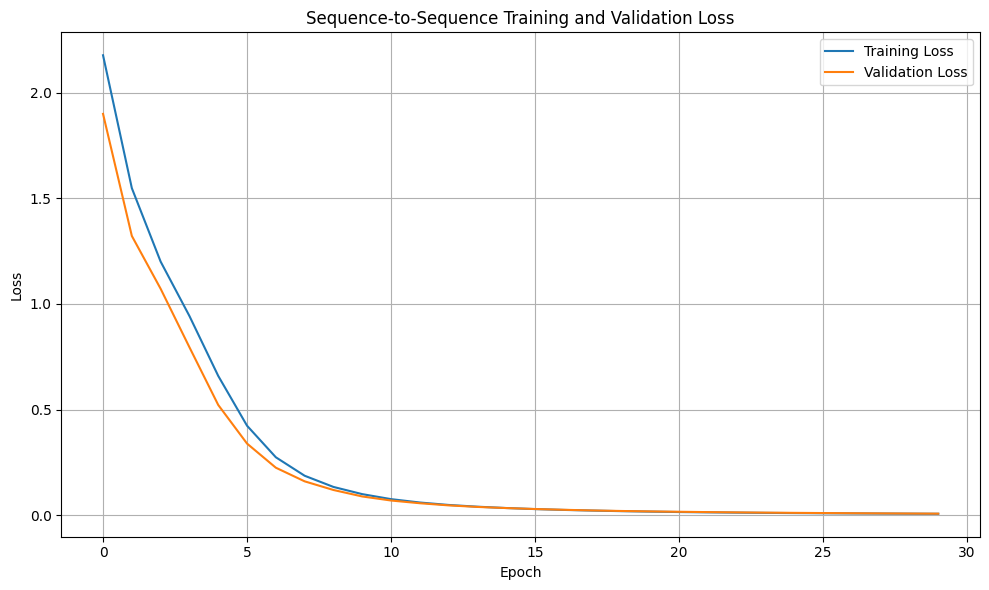

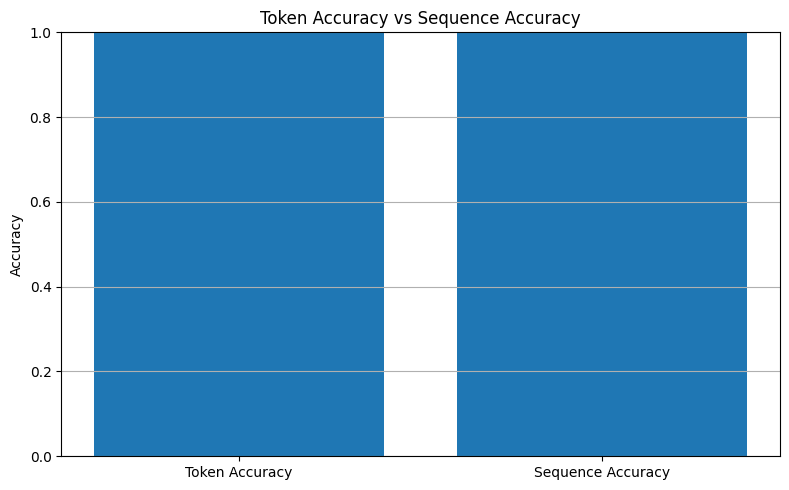


POSITION-WISE TOKEN ACCURACY
Position 1: 1.0000 (100.00%)
Position 2: 1.0000 (100.00%)
Position 3: 1.0000 (100.00%)
Position 4: 1.0000 (100.00%)

TASK 24 — REQUIRED INFERENCE

Sequence accuracy can be substantially lower than token
accuracy because sequence accuracy is an all-or-nothing
measure.

For example:

Actual:
[5, 1, 8, 3]

Predicted:
[5, 1, 6, 3]

Here, 3 out of 4 individual tokens are correct, so the
token-level result is 75% for this sequence.

However, the entire sequence is considered incorrect
because one token is wrong.

Therefore, token accuracy can remain high while sequence
accuracy is considerably lower.

As sequence length increases, there are more opportunities
for at least one prediction to be incorrect, making
sequence-level accuracy a stricter metric.


TASK 24 COMPLETED
Token Accuracy     : 100.00%
Sequence Accuracy  : 100.00%
Training Loss      : 0.006343
Validation Loss    : 0.006993


In [ ]:
# ============================================================
# TASK 24 — SEQUENCE-TO-SEQUENCE EVALUATION
# ============================================================
#
# Required:
# 1. Token accuracy
# 2. Sequence accuracy
# 3. Training loss
# 4. Validation loss
#
# Also explains why sequence accuracy can be lower than
# token accuracy.
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 80)
print("TASK 24 — SEQUENCE-TO-SEQUENCE EVALUATION")
print("=" * 80)


# ============================================================
# 1. GENERATE TEST SET PREDICTIONS
# ============================================================

print("\nGenerating predictions on the test set...")


predicted_sequences = []

prediction_confidences = []


for sequence in X_test:

    prediction, confidence = decode_sequence(
        sequence
    )

    predicted_sequences.append(
        prediction
    )

    prediction_confidences.append(
        confidence
    )


predicted_sequences = np.array(
    predicted_sequences
)

prediction_confidences = np.array(
    prediction_confidences
)


print(
    "Predicted sequence shape:",
    predicted_sequences.shape
)

print(
    "Actual sequence shape:",
    Y_test.shape
)


# ============================================================
# 2. TOKEN-LEVEL CORRECTNESS
# ============================================================
#
# Each individual element is checked.
#
# Example:
#
# Actual:
# [5, 1, 8, 3]
#
# Predicted:
# [5, 1, 6, 3]
#
# 3 out of 4 tokens are correct.
# ============================================================

token_correct = (
    predicted_sequences
    ==
    Y_test
)


correct_tokens = int(
    token_correct.sum()
)


total_tokens = int(
    Y_test.size
)


token_accuracy = (
    correct_tokens /
    total_tokens
)


# ============================================================
# 3. SEQUENCE-LEVEL CORRECTNESS
# ============================================================
#
# A complete sequence is correct only if EVERY token
# is correct.
# ============================================================

sequence_correct = np.all(
    predicted_sequences
    ==
    Y_test,
    axis=1
)


completely_correct_sequences = int(
    sequence_correct.sum()
)


total_sequences = int(
    len(Y_test)
)


sequence_accuracy = (
    completely_correct_sequences /
    total_sequences
)


# ============================================================
# 4. TRAINING LOSS
# ============================================================

training_loss = history.history[
    "loss"
][-1]


# ============================================================
# 5. VALIDATION LOSS
# ============================================================

validation_loss = history.history[
    "val_loss"
][-1]


# ============================================================
# 6. DISPLAY REQUIRED FORMULAS
# ============================================================

print("\n" + "=" * 80)
print("TASK 24 METRICS")
print("=" * 80)


print(
    "\nToken Accuracy = "
    "Correctly predicted tokens / Total tokens"
)


print(
    f"Token Accuracy = "
    f"{correct_tokens} / {total_tokens}"
)


print(
    f"Token Accuracy = "
    f"{token_accuracy:.4f}"
)


print(
    f"Token Accuracy (%) = "
    f"{token_accuracy * 100:.2f}%"
)


print(
    "\nSequence Accuracy = "
    "Completely correct sequences / Total sequences"
)


print(
    f"Sequence Accuracy = "
    f"{completely_correct_sequences} / "
    f"{total_sequences}"
)


print(
    f"Sequence Accuracy = "
    f"{sequence_accuracy:.4f}"
)


print(
    f"Sequence Accuracy (%) = "
    f"{sequence_accuracy * 100:.2f}%"
)


print(
    "\nTraining Loss =",
    f"{training_loss:.6f}"
)


print(
    "Validation Loss =",
    f"{validation_loss:.6f}"
)


# ============================================================
# 7. CREATE TASK 24 TABLE
# ============================================================

task24_results = pd.DataFrame({

    "Metric": [

        "Token Accuracy",

        "Sequence Accuracy",

        "Training Loss",

        "Validation Loss"

    ],

    "Value": [

        token_accuracy,

        sequence_accuracy,

        training_loss,

        validation_loss

    ]

})


print("\n" + "=" * 80)
print("TASK 24 RESULT TABLE")
print("=" * 80)


display(
    task24_results
)


# ============================================================
# 8. PLOT TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Sequence-to-Sequence Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 9. TOKEN ACCURACY VS SEQUENCE ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    [
        "Token Accuracy",
        "Sequence Accuracy"
    ],
    [
        token_accuracy,
        sequence_accuracy
    ]
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "Token Accuracy vs Sequence Accuracy"
)


plt.grid(
    axis="y"
)


plt.tight_layout()

plt.show()


# ============================================================
# 10. POSITION-WISE TOKEN ACCURACY
# ============================================================

position_accuracy = token_correct.mean(
    axis=0
)


print("\n" + "=" * 80)
print("POSITION-WISE TOKEN ACCURACY")
print("=" * 80)


for position, accuracy in enumerate(
    position_accuracy,
    start=1
):

    print(
        f"Position {position}: "
        f"{accuracy:.4f} "
        f"({accuracy * 100:.2f}%)"
    )


# ============================================================
# 11. REQUIRED INFERENCE
# ============================================================

print("\n" + "=" * 80)
print("TASK 24 — REQUIRED INFERENCE")
print("=" * 80)


print(
    """
Sequence accuracy can be substantially lower than token
accuracy because sequence accuracy is an all-or-nothing
measure.

For example:

Actual:
[5, 1, 8, 3]

Predicted:
[5, 1, 6, 3]

Here, 3 out of 4 individual tokens are correct, so the
token-level result is 75% for this sequence.

However, the entire sequence is considered incorrect
because one token is wrong.

Therefore, token accuracy can remain high while sequence
accuracy is considerably lower.

As sequence length increases, there are more opportunities
for at least one prediction to be incorrect, making
sequence-level accuracy a stricter metric.
"""
)


# ============================================================
# 12. FINAL TASK 24 SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("TASK 24 COMPLETED")
print("=" * 80)


print(
    f"Token Accuracy     : "
    f"{token_accuracy * 100:.2f}%"
)

print(
    f"Sequence Accuracy  : "
    f"{sequence_accuracy * 100:.2f}%"
)

print(
    f"Training Loss      : "
    f"{training_loss:.6f}"
)

print(
    f"Validation Loss    : "
    f"{validation_loss:.6f}"
)

In [ ]:
# ============================================================
# CS3807 DEEP LEARNING LAB
# EXPERIMENT 6
#
# TASK 25 — CONSOLIDATED RESULTS
# ROBUST / UPDATED VERSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 80)
print("TASK 25 — CONSOLIDATED RESULTS")
print("=" * 80)


# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def convert_labels_to_class_indices(y):
    """
    Converts labels into 1-D class indices.

    Handles:
        - integer labels: [0, 1, 2, 3, ...]
        - one-hot labels: [[1,0,0], [0,1,0], ...]
        - column labels: [[0], [1], [2], ...]
    """

    y = np.asarray(y)

    # Remove unnecessary dimensions
    if y.ndim == 0:
        return y.reshape(1)

    # One-hot encoded labels
    if y.ndim == 2:
        if y.shape[1] > 1:
            return np.argmax(y, axis=1)

        return y.reshape(-1)

    # Already class indices
    if y.ndim == 1:
        return y

    # Fallback
    return np.argmax(y, axis=-1).reshape(-1)


def get_model_predictions(model, X):
    """
    Generate class predictions from a Keras model.
    """

    output = model.predict(X, verbose=0)

    # Some models may return a list/tuple
    if isinstance(output, (list, tuple)):
        output = output[0]

    # Convert to numpy
    output = np.asarray(output)

    # Standard classification output:
    # (number_of_samples, number_of_classes)
    if output.ndim == 2:
        return np.argmax(output, axis=1)

    # If output is already class labels
    if output.ndim == 1:
        return output.astype(int)

    # Fallback for unexpected higher-dimensional output
    # Example: (samples, timesteps, classes)
    if output.ndim >= 3:

        # If the last dimension represents classes,
        # use the final timestep.
        final_output = output[:, -1, :]

        return np.argmax(final_output, axis=-1)

    raise ValueError(
        f"Unsupported model output shape: {output.shape}"
    )


def evaluate_classification_model(
    model,
    X,
    y,
    model_name
):
    """
    Evaluate one classification model.

    Metrics:
        Accuracy
        Macro Precision
        Macro Recall
        Macro F1
        Parameters
    """

    print("\n" + "-" * 70)
    print(f"Evaluating: {model_name}")
    print("-" * 70)

    # --------------------------------------------------------
    # Check inputs
    # --------------------------------------------------------

    if model is None:
        raise ValueError(
            f"{model_name}: model is None."
        )

    if X is None:
        raise ValueError(
            f"{model_name}: test data X is None."
        )

    if y is None:
        raise ValueError(
            f"{model_name}: test labels y are None."
        )

    print("Test data shape:", np.asarray(X).shape)
    print("Original label shape:", np.asarray(y).shape)

    # --------------------------------------------------------
    # Convert ground-truth labels
    # --------------------------------------------------------

    y_true = convert_labels_to_class_indices(y)

    print("Processed label shape:", y_true.shape)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = get_model_predictions(model, X)

    print("Prediction shape:", y_pred.shape)

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if len(y_true) != len(y_pred):
        raise ValueError(
            f"{model_name}: Number of labels ({len(y_true)}) "
            f"does not match number of predictions ({len(y_pred)})."
        )

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    parameters = model.count_params()

    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"Precision : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1 Score  : {f1 * 100:.2f}%")
    print(f"Parameters: {parameters:,}")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Parameters": parameters
    }


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

print("\n" + "=" * 80)
print("CHECKING AVAILABLE MODELS AND DATA")
print("=" * 80)


# ------------------------------------------------------------
# UCI-HAR
# ------------------------------------------------------------

required_har = [
    "har_rnn_model",
    "har_lstm_model",
    "har_gru_model",
    "X_har_test",
    "y_har_test"
]


missing_har = [
    name
    for name in required_har
    if name not in globals()
]


if len(missing_har) == 0:

    print("\nUCI-HAR:")
    print("All required variables found.")

else:

    print("\nUCI-HAR:")
    print("Missing variables:")

    for name in missing_har:
        print("  -", name)


# ------------------------------------------------------------
# UCF101
# ------------------------------------------------------------

required_video = [
    "cnn_lstm",
    "cnn_gru",
    "X_video_test",
    "y_video_test"
]


missing_video = [
    name
    for name in required_video
    if name not in globals()
]


if len(missing_video) == 0:

    print("\nUCF101:")
    print("All required variables found.")

else:

    print("\nUCF101:")
    print("Missing variables:")

    for name in missing_video:
        print("  -", name)


# ============================================================
# 3. UCI-HAR RESULTS
# ============================================================

har_results = []


if len(missing_har) == 0:

    print("\n" + "=" * 80)
    print("UCI-HAR MODEL RESULTS")
    print("=" * 80)

    # --------------------------------------------------------
    # RNN
    # --------------------------------------------------------

    try:

        result = evaluate_classification_model(
            har_rnn_model,
            X_har_test,
            y_har_test,
            "RNN"
        )

        har_results.append(result)

    except Exception as e:

        print("\nRNN evaluation failed:")
        print(e)


    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------

    try:

        result = evaluate_classification_model(
            har_lstm_model,
            X_har_test,
            y_har_test,
            "LSTM"
        )

        har_results.append(result)

    except Exception as e:

        print("\nLSTM evaluation failed:")
        print(e)


    # --------------------------------------------------------
    # GRU
    # --------------------------------------------------------

    try:

        result = evaluate_classification_model(
            har_gru_model,
            X_har_test,
            y_har_test,
            "GRU"
        )

        har_results.append(result)

    except Exception as e:

        print("\nGRU evaluation failed:")
        print(e)


else:

    print("\n" + "=" * 80)
    print("UCI-HAR RESULTS SKIPPED")
    print("=" * 80)

    print(
        "\nRun the UCI-HAR model training/evaluation cells first."
    )


# ============================================================
# 4. UCF101 CNN-LSTM / CNN-GRU RESULTS
# ============================================================

video_results = []


if len(missing_video) == 0:

    print("\n" + "=" * 80)
    print("UCF101 VIDEO MODEL RESULTS")
    print("=" * 80)

    # --------------------------------------------------------
    # CNN-LSTM
    # --------------------------------------------------------

    try:

        result = evaluate_classification_model(
            cnn_lstm,
            X_video_test,
            y_video_test,
            "CNN-LSTM"
        )

        video_results.append(result)

    except Exception as e:

        print("\nCNN-LSTM evaluation failed:")
        print(e)


    # --------------------------------------------------------
    # CNN-GRU
    # --------------------------------------------------------

    try:

        result = evaluate_classification_model(
            cnn_gru,
            X_video_test,
            y_video_test,
            "CNN-GRU"
        )

        video_results.append(result)

    except Exception as e:

        print("\nCNN-GRU evaluation failed:")
        print(e)


else:

    print("\n" + "=" * 80)
    print("UCF101 RESULTS SKIPPED")
    print("=" * 80)

    print(
        "\nRun the UCF101 CNN-LSTM/CNN-GRU cells first."
    )


# ============================================================
# 5. DISPLAY UCF101 RESULTS
# ============================================================

if len(video_results) > 0:

    video_results_df = pd.DataFrame(
        video_results
    )

    print("\n" + "=" * 80)
    print("CNN-LSTM vs CNN-GRU")
    print("=" * 80)

    video_report_table = video_results_df.copy()

    for column in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]:

        video_report_table[column] = (
            video_report_table[column] * 100
        ).round(2)

    display(video_report_table)


# ============================================================
# 6. CONSOLIDATED RESULTS
# ============================================================

all_results = []

all_results.extend(har_results)
all_results.extend(video_results)


if len(all_results) > 0:

    consolidated_results = pd.DataFrame(
        all_results
    )

    print("\n" + "=" * 80)
    print("TASK 25 — DETAILED CONSOLIDATED RESULTS")
    print("=" * 80)

    display(consolidated_results)


else:

    print("\nNo model results are available.")

    print(
        "\nMake sure the model-training cells were executed "
        "before running Task 25."
    )


# ============================================================
# 7. REPORT-FRIENDLY TABLE
# ============================================================

if len(all_results) > 0:

    report_table = consolidated_results.copy()

    for column in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]:

        report_table[column] = (
            report_table[column] * 100
        ).round(2)

    print("\n" + "=" * 80)
    print("TASK 25 — REPORT TABLE")
    print("=" * 80)

    display(report_table)


# ============================================================
# 8. REQUIRED FOUR-ROW TABLE
# ============================================================

print("\n" + "=" * 80)
print("TASK 25 — FOUR-ROW TABLE")
print("=" * 80)


# ------------------------------------------------------------
# Choose which video model represents CNN-LSTM/GRU
# ------------------------------------------------------------

SELECTED_VIDEO_MODEL = "CNN-LSTM"


if len(all_results) > 0:

    final_four_rows = []


    # --------------------------------------------------------
    # RNN
    # --------------------------------------------------------

    rnn_rows = consolidated_results[
        consolidated_results["Model"] == "RNN"
    ]

    if len(rnn_rows) > 0:

        final_four_rows.append(
            rnn_rows.iloc[0].to_dict()
        )


    # --------------------------------------------------------
    # LSTM
    # --------------------------------------------------------

    lstm_rows = consolidated_results[
        consolidated_results["Model"] == "LSTM"
    ]

    if len(lstm_rows) > 0:

        final_four_rows.append(
            lstm_rows.iloc[0].to_dict()
        )


    # --------------------------------------------------------
    # GRU
    # --------------------------------------------------------

    gru_rows = consolidated_results[
        consolidated_results["Model"] == "GRU"
    ]

    if len(gru_rows) > 0:

        final_four_rows.append(
            gru_rows.iloc[0].to_dict()
        )


    # --------------------------------------------------------
    # CNN-LSTM / CNN-GRU
    # --------------------------------------------------------

    selected_rows = consolidated_results[
        consolidated_results["Model"]
        == SELECTED_VIDEO_MODEL
    ]


    if len(selected_rows) > 0:

        selected_video_result = (
            selected_rows.iloc[0].to_dict()
        )

        selected_video_result["Model"] = (
            "CNN-LSTM/GRU"
        )

        final_four_rows.append(
            selected_video_result
        )

    else:

        print(
            f"\nWARNING: {SELECTED_VIDEO_MODEL} "
            "result is not available."
        )


    # --------------------------------------------------------
    # Create final table
    # --------------------------------------------------------

    if len(final_four_rows) > 0:

        final_four_table = pd.DataFrame(
            final_four_rows
        )

        final_four_report = (
            final_four_table.copy()
        )


        for column in [
            "Accuracy",
            "Precision",
            "Recall",
            "F1"
        ]:

            final_four_report[column] = (
                final_four_report[column] * 100
            ).round(2)


        display(final_four_report)

    else:

        print(
            "\nNo models were available for the "
            "four-row table."
        )


# ============================================================
# 9. SEQ2SEQ RESULTS
# ============================================================

print("\n" + "=" * 80)
print("TASK 25 — SEQUENCE-TO-SEQUENCE RESULTS")
print("=" * 80)


seq2seq_variables = [
    "token_accuracy",
    "sequence_accuracy",
    "training_loss",
    "validation_loss"
]


missing_seq2seq = [
    name
    for name in seq2seq_variables
    if name not in globals()
]


if len(missing_seq2seq) == 0:

    seq2seq_results = pd.DataFrame({

        "Metric": [
            "Token Accuracy",
            "Sequence Accuracy",
            "Training Loss",
            "Validation Loss"
        ],

        "Value": [
            token_accuracy,
            sequence_accuracy,
            training_loss,
            validation_loss
        ]

    })


    seq2seq_display = seq2seq_results.copy()


    # Convert accuracies to percentages
    for metric in [
        "Token Accuracy",
        "Sequence Accuracy"
    ]:

        mask = (
            seq2seq_display["Metric"]
            == metric
        )

        seq2seq_display.loc[
            mask,
            "Value"
        ] = (
            seq2seq_display.loc[
                mask,
                "Value"
            ] * 100
        ).round(2)


    # Round losses
    for metric in [
        "Training Loss",
        "Validation Loss"
    ]:

        mask = (
            seq2seq_display["Metric"]
            == metric
        )

        seq2seq_display.loc[
            mask,
            "Value"
        ] = (
            seq2seq_display.loc[
                mask,
                "Value"
            ].astype(float)
        ).round(4)


    display(seq2seq_display)


else:

    print(
        "\nSeq2Seq results are not available."
    )

    print(
        "Run Task 24 first."
    )

    print("\nMissing variables:")

    for name in missing_seq2seq:
        print(" -", name)


# ============================================================
# 10. PARAMETER SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PARAMETER COUNTS")
print("=" * 80)


parameter_rows = []


if "har_rnn_model" in globals():

    parameter_rows.append({
        "Model": "RNN",
        "Parameters": har_rnn_model.count_params()
    })


if "har_lstm_model" in globals():

    parameter_rows.append({
        "Model": "LSTM",
        "Parameters": har_lstm_model.count_params()
    })


if "har_gru_model" in globals():

    parameter_rows.append({
        "Model": "GRU",
        "Parameters": har_gru_model.count_params()
    })


if "cnn_lstm" in globals():

    parameter_rows.append({
        "Model": "CNN-LSTM",
        "Parameters": cnn_lstm.count_params()
    })


if "cnn_gru" in globals():

    parameter_rows.append({
        "Model": "CNN-GRU",
        "Parameters": cnn_gru.count_params()
    })


if len(parameter_rows) > 0:

    parameter_table = pd.DataFrame(
        parameter_rows
    )

    display(parameter_table)

else:

    print("No trained models found.")


# ============================================================
# 11. SAVE RESULTS TO CSV
# ============================================================

if len(all_results) > 0:

    report_table.to_csv(
        "/content/task25_consolidated_results.csv",
        index=False
    )

    print(
        "\nConsolidated results saved to:"
    )

    print(
        "/content/task25_consolidated_results.csv"
    )


# ============================================================
# 12. FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 80)
print("TASK 25 — INTERPRETATION")
print("=" * 80)

print(
    """
The consolidated table reports the observed test-set
performance of the recurrent classification models.

Accuracy:
    Fraction of correctly classified samples.

Precision:
    Macro-averaged precision across the classes.

Recall:
    Macro-averaged recall across the classes.

F1:
    Macro-averaged F1 score.

Parameters:
    Total number of parameters reported by
    model.count_params().

The CNN-LSTM and CNN-GRU models use CNN-extracted
video features followed by recurrent temporal
classification.

The Seq2Seq experiment is reported separately because
it is a sequence-generation task rather than a
single-label classification task.
"""
)


print("\n" + "=" * 80)
print("TASK 25 CODE FINISHED")
print("=" * 80)

TASK 25 — CONSOLIDATED RESULTS

CHECKING AVAILABLE MODELS AND DATA

UCI-HAR:
Missing variables:
  - har_rnn_model
  - har_lstm_model
  - har_gru_model
  - X_har_test
  - y_har_test

UCF101:
Missing variables:
  - X_video_test
  - y_video_test

UCI-HAR RESULTS SKIPPED

Run the UCI-HAR model training/evaluation cells first.

UCF101 RESULTS SKIPPED

Run the UCF101 CNN-LSTM/CNN-GRU cells first.

No model results are available.

Make sure the model-training cells were executed before running Task 25.

TASK 25 — FOUR-ROW TABLE

TASK 25 — SEQUENCE-TO-SEQUENCE RESULTS


,Metric,Value
0,Token Accuracy,100.0000
1,Sequence Accuracy,100.0000
2,Training Loss,0.0063
3,Validation Loss,0.0070



PARAMETER COUNTS


,Model,Parameters
0,CNN-LSTM,168643
1,CNN-GRU,126723



TASK 25 — INTERPRETATION

The consolidated table reports the observed test-set
performance of the recurrent classification models.

Accuracy:
    Fraction of correctly classified samples.

Precision:
    Macro-averaged precision across the classes.

Recall:
    Macro-averaged recall across the classes.

F1:
    Macro-averaged F1 score.

Parameters:
    Total number of parameters reported by
    model.count_params().

The CNN-LSTM and CNN-GRU models use CNN-extracted
video features followed by recurrent temporal
classification.

The Seq2Seq experiment is reported separately because
it is a sequence-generation task rather than a
single-label classification task.


TASK 25 CODE FINISHED
